### Replicon coocurrence project 


In [7]:
# ================================================================
# CHUNK 1 — Propagar representante a TODOS los géneros del clúster
# - Carga asignaciones y representantes (incluye aislados)
# - Carga taxonomía COMPLETA (PLSD_SUM sin filtrar)
# - Construye tabla reps_by_genus: cada rep se asigna a todos
#   los géneros presentes entre los miembros de su clúster
# - Guarda salidas en DPROC
# ================================================================
import re
import pandas as pd

# ---------- Helpers ----------
def clean_genus_name(g):
    g = re.sub(r"\s*\([^)]*\)\s*$", "", str(g or "")).strip()
    g = re.sub(r"\s+", " ", g)
    return g

# ---------- Rutas de clustering ----------
ASSIGN_TSV = DEDUP / "louvain_by_level_from_table_including_isolates" / "cluster_assignments_by_level.tsv"     # id, level, cluster
REPS_TSV   = DEDUP / "louvain_by_level_from_table_including_isolates" / "representatives_by_cluster_level.tsv" # level, cluster, representative

# ---------- Carga clustering ----------
assign = pd.read_csv(ASSIGN_TSV, sep="\t", dtype=str)
reps   = pd.read_csv(REPS_TSV,   sep="\t", dtype=str)

assign["id_norm"] = assign["id"].map(_normalize_id)
reps["rep_norm"]  = reps["representative"].map(_normalize_id)
assign["level"]   = assign["level"].astype(str)
reps["level"]     = reps["level"].astype(str)

print(f"[ASSIGN] filas: {len(assign):,} | niveles: {sorted(assign['level'].unique().tolist())}")
print(f"[REPS] representantes (únicos): {reps['rep_norm'].nunique():,}")

# ---------- Taxonomía COMPLETA (sin filtrar) ----------
summ_all = pd.read_csv(PLSD_SUM, dtype=str).fillna("")
tax_all = summ_all[[c for c in [
    "NUCCORE_ACC",
    "TAXONOMY.TAXONOMY_genus",
    "TAXONOMY.TAXONOMY_species",
    "TAXONOMY.TAXONOMY_taxon_name"
] if c in summ_all.columns]].copy()

tax_all = tax_all.rename(columns={"NUCCORE_ACC":"plasmid_id"})
tax_all["__pid_norm__"] = tax_all["plasmid_id"].map(_normalize_id)

# genus limpio
if "TAXONOMY.TAXONOMY_genus" in tax_all.columns:
    tax_all["genus"] = tax_all["TAXONOMY.TAXONOMY_genus"].map(clean_genus_name)
else:
    tax_all["genus"] = ""

# species (species si no, taxon_name)
if "TAXONOMY.TAXONOMY_species" in tax_all.columns:
    tax_all["species"] = tax_all["TAXONOMY.TAXONOMY_species"]
else:
    tax_all["species"] = ""
if "TAXONOMY.TAXONOMY_taxon_name" in tax_all.columns:
    missing = tax_all["species"].eq("") | tax_all["species"].isna()
    tax_all.loc[missing, "species"] = tax_all.loc[missing, "TAXONOMY.TAXONOMY_taxon_name"]

tax_all = tax_all[["__pid_norm__", "genus", "species"]].drop_duplicates()
print(f"[TAX] IDs con taxonomía (normalizados): {len(tax_all):,}")

# ---------- Miembros + tax + representante ----------
members = assign.merge(tax_all, left_on="id_norm", right_on="__pid_norm__", how="left").drop(columns=["__pid_norm__"])
members["genus"]   = members["genus"].fillna("").astype(str)
members["species"] = members["species"].fillna("").astype(str)

mrep = members.merge(reps[["level","cluster","rep_norm"]], on=["level","cluster"], how="left")

# Snapshot para trazabilidad
snap_path = DPROC / "clusters_members_tax.tsv"
mrep.to_csv(snap_path, sep="\t", index=False)
print(f"[OUT] {snap_path}")

# ---------- Tabla canónica: rep ↔ géneros del clúster ----------
grp = (mrep
       .groupby(["level","cluster","rep_norm","genus"], dropna=False)
       .agg(n_members_genus=("id_norm","nunique"))
       .reset_index())

rep_by_genus = (grp
                .groupby(["rep_norm","genus"], dropna=False)["n_members_genus"]
                .sum()
                .reset_index()
                .sort_values(["rep_norm","n_members_genus"], ascending=[True, False])
                .reset_index(drop=True))

out_rep_by_genus = DPROC / "reps_by_genus.tsv"
rep_by_genus.to_csv(out_rep_by_genus, sep="\t", index=False)
print(f"[OUT] {out_rep_by_genus}")

# ---------- Resúmenes útiles ----------
coverage_by_genus = (rep_by_genus[rep_by_genus["genus"] != ""]
                     .groupby("genus")["rep_norm"]
                     .nunique()
                     .sort_values(ascending=False))

weight_by_genus = (rep_by_genus[rep_by_genus["genus"] != ""]
                   .groupby("genus")["n_members_genus"]
                   .sum()
                   .sort_values(ascending=False))

print("\n[SUMMARY] Top 10 géneros por nº de representantes que los cubren:")
print(coverage_by_genus.head(10).to_string())

print("\n[SUMMARY] Top 10 géneros por nº de miembros dentro de sus clústeres:")
print(weight_by_genus.head(10).to_string())

rep_by_genus.head(6)


[ASSIGN] filas: 53,515 | niveles: ['1', '2', '3', '4', '5', '6', '7']
[REPS] representantes (únicos): 23,798
[TAX] IDs con taxonomía (normalizados): 72,360
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/clusters_members_tax.tsv
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/reps_by_genus.tsv

[SUMMARY] Top 10 géneros por nº de representantes que los cubren:
genus
Escherichia            5778
Klebsiella             3970
Enterococcus           1347
Salmonella             1059
Staphylococcus         1003
Enterobacter            978
Acinetobacter           836
Bacillus                806
Citrobacter             643
Lactiplantibacillus     552

[SUMMARY] Top 10 géneros por nº de miembros dentro de sus clústeres:
genus
Escherichia       13674
Klebsiella        11365
Salmonella         3056
Staphylococcus     2841
Enterococcus       2815
Enterobacter       2056
Acinetobacter      1642
Bacillus           1457
Citrobacter         959
Shigella            785


,rep_norm,genus,n_members_genus
0,AB063523.1,Wigglesworthia,1
1,AB244976.1,,1
2,AB576781.2,Salmonella,2
3,AE017195.1,Bacillus,1
4,AF128883.1,Staphylococcus,1
5,AFSD01000008.1,Agrobacterium,1


In [8]:
# ================================================================
# Cargar PLSDB (mob, summary) y preparar vistas DEDUP
# - Lee como string, rellena "" en NA
# - Estandariza columna 'plasmid_id'
# - Normaliza IDs (quita ruta y extensión)
# - Filtra por KEEP_SET (representantes)
# - (NUEVO) Expande reps → géneros del clúster usando DPROC/reps_by_genus.tsv
# - Guarda copias filtradas y expandidas en DPROC
# ================================================================

# 1) Carga cruda
mob_raw  = pd.read_csv(PLSDB_MOB, dtype=str).fillna("")
summ_raw = pd.read_csv(PLSD_SUM,  dtype=str).fillna("")

# 2) Estandariza nombre de columna
mob  = mob_raw.rename(columns={"NUCCORE_ACC": "plasmid_id"}).copy()
summ = summ_raw.rename(columns={"NUCCORE_ACC": "plasmid_id"}).copy()

# 3) Normaliza IDs
mob["__pid_norm__"]  = mob["plasmid_id"].map(_normalize_id)
summ["__pid_norm__"] = summ["plasmid_id"].map(_normalize_id)

# 4) Filtra por KEEP_SET (representantes)
before_mob  = mob.shape[0]
before_sum  = summ.shape[0]
mob_filt    = mob[mob["__pid_norm__"].isin(KEEP_SET)].copy()
summ_filt   = summ[summ["__pid_norm__"].isin(KEEP_SET)].copy()
after_mob   = mob_filt.shape[0]
after_sum   = summ_filt.shape[0]

# (Opcional) eliminar duplicados por ID normalizado si existieran
mob_filt  = mob_filt.drop_duplicates(subset="__pid_norm__")
summ_filt = summ_filt.drop_duplicates(subset="__pid_norm__")

print(f"[PLSDB_MOB] {before_mob} → {after_mob} filas tras filtrar reps ({after_mob/before_mob:.1%})")
print(f"[PLSDB_SUM] {before_sum} → {after_sum} filas tras filtrar reps ({after_sum/before_sum:.1%})")

# 5) Persistir versiones filtradas (TSV)
mob_out  = DPROC / "plsdb_mob.dedup.tsv"
summ_out = DPROC / "plsdb_summary.dedup.tsv"
mob_filt.to_csv(mob_out,  sep="\t", index=False)
summ_filt.to_csv(summ_out, sep="\t", index=False)
print(f"[OUT] {mob_out}")
print(f"[OUT] {summ_out}")

# ================== (NUEVO) Extender reps → TODOS los géneros del clúster ==================
reps_by_genus_path = DPROC / "reps_by_genus.tsv"   # generado en el CHUNK 1
if not reps_by_genus_path.exists():
    raise FileNotFoundError(f"No existe {reps_by_genus_path}. Genera primero la tabla reps_by_genus (CHUNK 1).")

repG = pd.read_csv(reps_by_genus_path, sep="\t", dtype=str).fillna("")
# repG: columnas esperadas => rep_norm, genus, n_members_genus

# —— Expansión para mob: une por __pid_norm__ == rep_norm
mob_repXgenus = (repG
                 .merge(mob_filt, left_on="rep_norm", right_on="__pid_norm__", how="left", suffixes=("",""))
                 .dropna(subset=["plasmid_id"]))  # por si algún rep no está en mob

# —— Expansión para summ (opcional, útil si usas otras columnas taxonómicas/aislamiento)
summ_repXgenus = (repG
                  .merge(summ_filt, left_on="rep_norm", right_on="__pid_norm__", how="left", suffixes=("",""))
                  .dropna(subset=["plasmid_id"]))

# Ordena columnas para comodidad
cols_front_mob  = ["rep_norm", "genus", "n_members_genus", "plasmid_id", "__pid_norm__"]
cols_front_summ = ["rep_norm", "genus", "n_members_genus", "plasmid_id", "__pid_norm__"]
mob_repXgenus  = mob_repXgenus[[*(c for c in cols_front_mob if c in mob_repXgenus.columns), *[c for c in mob_repXgenus.columns if c not in cols_front_mob]]]
summ_repXgenus = summ_repXgenus[[*(c for c in cols_front_summ if c in summ_repXgenus.columns), *[c for c in summ_repXgenus.columns if c not in cols_front_summ]]]

# —— Guardar expandidas
mob_exp_out  = DPROC / "plsdb_mob_repXgenus.dedup.tsv"
summ_exp_out = DPROC / "plsdb_summary_repXgenus.dedup.tsv"
mob_repXgenus.to_csv(mob_exp_out,  sep="\t", index=False)
summ_repXgenus.to_csv(summ_exp_out, sep="\t", index=False)
print(f"[OUT] {mob_exp_out}")
print(f"[OUT] {summ_exp_out}")

# —— Resumen rápido
print(f"[MOB rep×genus] reps únicos: {mob_repXgenus['rep_norm'].nunique():,} | filas: {len(mob_repXgenus):,}")
print(f"[SUM rep×genus] reps únicos: {summ_repXgenus['rep_norm'].nunique():,} | filas: {len(summ_repXgenus):,}")

# Devuelve shapes útiles
mob_filt.shape, summ_filt.shape, mob_repXgenus.shape, summ_repXgenus.shape


[PLSDB_MOB] 72360 → 23798 filas tras filtrar reps (32.9%)
[PLSDB_SUM] 72360 → 23798 filas tras filtrar reps (32.9%)
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/plsdb_mob.dedup.tsv
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/plsdb_summary.dedup.tsv
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/plsdb_mob_repXgenus.dedup.tsv
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/plsdb_summary_repXgenus.dedup.tsv
[MOB rep×genus] reps únicos: 23,798 | filas: 25,313
[SUM rep×genus] reps únicos: 23,798 | filas: 25,313


((23798, 23), (23798, 47), (25313, 26), (25313, 50))

In [9]:
# ================================================================
# Taxonomía mínima (DEDUP) y versión expandida rep×género-del-clúster
# - Base: summ_filt (solo representantes del KEEP_SET)
# - tax_min: genus/species por representante (tal cual el rep)
# - tax_min_repXgenus: asigna el representante a TODOS los géneros
#   presentes en su clúster (reps_by_genus.tsv); species se deja del rep
#   (puede no corresponder si el clúster mezcla géneros)
# - Guarda ambas en DPROC
# ================================================================
def split_unique_csv(x: str):
    """Split comma-separated tokens, strip y elimina duplicados preservando orden."""
    if not isinstance(x, str):
        return []
    parts = [p.strip() for p in x.split(",") if p.strip()]
    return list(dict.fromkeys(parts))

def first_nonempty(*vals):
    for v in vals:
        if isinstance(v, str) and v.strip():
            return v.strip()
    return ""

# ---------------- tax mínima (solo reps, sin expansión) ----------------
tax_cols = [c for c in [
    "plasmid_id",
    "TAXONOMY.TAXONOMY_genus",
    "TAXONOMY.TAXONOMY_species",
    "TAXONOMY.TAXONOMY_taxon_name"
] if c in summ_filt.columns]

tax = summ_filt[tax_cols].copy()

tax["genus"] = tax.apply(
    lambda r: first_nonempty(r.get("TAXONOMY.TAXONOMY_genus", "")),
    axis=1
)
tax["species"] = tax.apply(
    lambda r: first_nonempty(
        r.get("TAXONOMY.TAXONOMY_species", ""),
        r.get("TAXONOMY.TAXONOMY_taxon_name", "")
    ),
    axis=1
)

# Mantén solo las columnas esenciales y elimina duplicados
tax = tax[["plasmid_id", "genus", "species"]].drop_duplicates(ignore_index=True)

# Normaliza IDs y filtra por seguridad
tax["__pid_norm__"] = tax["plasmid_id"].map(_normalize_id)
tax = tax[tax["__pid_norm__"].isin(KEEP_SET)].copy()

print(f"[TAX] filas totales (reps, sin expansión): {len(tax)}")

# Guarda tax mínima
tax_out = DPROC / "taxonomy_minimal.dedup.tsv"
tax.to_csv(tax_out, sep="\t", index=False)
print(f"[OUT] {tax_out}")

# ---------------- versión expandida rep×género-del-clúster ----------------
# Usa tabla canónica creada en CHUNK 1
repG_path = DPROC / "reps_by_genus.tsv"
if not repG_path.exists():
    raise FileNotFoundError(f"No existe {repG_path}. Ejecuta antes el CHUNK 1 que genera reps_by_genus.tsv")

repG = pd.read_csv(repG_path, sep="\t", dtype=str).fillna("")
# repG: rep_norm, genus, n_members_genus

# Añade tax básica del representante (para arrastrar species del rep)
tax_rep_only = tax[["__pid_norm__", "species", "plasmid_id"]].drop_duplicates().rename(
    columns={"__pid_norm__":"rep_norm"}
)

tax_repXgenus = (repG
                 .merge(tax_rep_only, on="rep_norm", how="left")
                 .rename(columns={"plasmid_id":"representative_plasmid_id"}))

# Ordena y columnas útiles
tax_repXgenus = tax_repXgenus[[
    "rep_norm",              # ID normalizado del representante
    "representative_plasmid_id",
    "genus",                 # TODOS los géneros del clúster
    "species",               # species del rep (ojo si clúster mezcla)
    "n_members_genus"        # cuántos miembros del clúster son de ese género
]].drop_duplicates()

# Guarda expandida
tax_repXgenus_out = DPROC / "taxonomy_minimal_repXgenus.dedup.tsv"
tax_repXgenus.to_csv(tax_repXgenus_out, sep="\t", index=False)
print(f"[OUT] {tax_repXgenus_out}")

# Vista rápida
display(tax.head(3))
display(tax_repXgenus.head(6))


[TAX] filas totales (reps, sin expansión): 23798
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/taxonomy_minimal.dedup.tsv
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/taxonomy_minimal_repXgenus.dedup.tsv


,plasmid_id,genus,species,__pid_norm__
0,NZ_CP157108.1,Escherichia (561),Escherichia_coli (562),NZ_CP157108.1
1,NZ_CP157107.1,Escherichia (561),Escherichia_coli (562),NZ_CP157107.1
2,NZ_CP157161.1,Escherichia (561),Escherichia_coli (562),NZ_CP157161.1


,rep_norm,representative_plasmid_id,genus,species,n_members_genus
0,AB063523.1,AB063523.1,Wigglesworthia,Wigglesworthia_glossinidia (51229),1
1,AB244976.1,AB244976.1,,uncultured_bacterium (77133),1
2,AB576781.2,AB576781.2,Salmonella,Salmonella_enterica (28901),2
3,AE017195.1,AE017195.1,Bacillus,Bacillus_cereus (1396),1
4,AF128883.1,AF128883.1,Staphylococcus,Staphylococcus_aureus (1280),1
5,AFSD01000008.1,AFSD01000008.1,Agrobacterium,Agrobacterium_tumefaciens (358),1


In [10]:
# ================================================================
# Replicon counts per plasmid (DEDUP) + versión expandida por género de clúster
# - rep_type: CSV-like en PLSDB (mob_filt)
# - Cuenta únicos preservando orden
# - Adjunta genus/species del rep (tax)
# - (NUEVO) Expande a TODOS los géneros del clúster (reps_by_genus.tsv)
# - Guarda en DSTATS
# ================================================================

# Comprobación de columna
if "rep_type" not in mob_filt.columns:
    raise KeyError("Column 'rep_type' not found in plsdb_mob (mob_filt).")

# --- Conteo de replicones únicos por plásmido (solo reps) ---
rep_counts = mob_filt["rep_type"].apply(split_unique_csv).apply(len)
rep_per_plasmid = pd.DataFrame({
    "plasmid_id": mob_filt["plasmid_id"].values,
    "rep_count": rep_counts.values
})

# Normaliza IDs para merges robustos
rep_per_plasmid["__pid_norm__"] = rep_per_plasmid["plasmid_id"].map(_normalize_id)
tax_norm = tax.copy()
if "__pid_norm__" not in tax_norm.columns:
    tax_norm["__pid_norm__"] = tax_norm["plasmid_id"].map(_normalize_id)

# Merge con taxonomía del representante (genus/species del rep)
rep_per_plasmid = rep_per_plasmid.merge(
    tax_norm[["__pid_norm__", "genus", "species"]],
    on="__pid_norm__", how="left"
)

# --- Guardar tabla base (solo reps) ---
out_per_plasmid = DSTATS / "replicon_counts_per_plasmid.dedup.tsv"
rep_per_plasmid.to_csv(out_per_plasmid, sep="\t", index=False)

# --- Distribución global (solo reps) ---
dist = rep_per_plasmid["rep_count"].value_counts().sort_index()
dist_df = dist.rename_axis("rep_count").reset_index(name="n_plasmids")
dist_df["percent"] = dist_df["n_plasmids"] / dist_df["n_plasmids"].sum() * 100.0
out_dist = DSTATS / "replicon_counts_distribution.dedup.tsv"
dist_df.to_csv(out_dist, sep="\t", index=False)

# --- (NUEVO) Expandir reps a TODOS los géneros del clúster ---
repG_path = DPROC / "reps_by_genus.tsv"   # generado en CHUNK 1
if not repG_path.exists():
    raise FileNotFoundError(f"No existe {repG_path}. Ejecuta antes el CHUNK 1 para generar reps_by_genus.tsv")

repG = pd.read_csv(repG_path, sep="\t", dtype=str).fillna("")
# repG: rep_norm, genus, n_members_genus

# Map __pid_norm__ del rep a rep_norm
rep_counts_min = rep_per_plasmid[["__pid_norm__", "plasmid_id", "rep_count", "genus", "species"]].drop_duplicates()
rep_counts_min = rep_counts_min.rename(columns={"__pid_norm__": "rep_norm",
                                                "genus":"rep_genus",
                                                "species":"rep_species"})

# Expansión: cada representante aparece tantas filas como géneros tenga su clúster
rep_per_plasmid_repXgenus = repG.merge(rep_counts_min, on="rep_norm", how="left")

# Reorganizar columnas
cols_order = ["rep_norm", "plasmid_id", "rep_count", "genus", "n_members_genus", "rep_genus", "rep_species"]
rep_per_plasmid_repXgenus = rep_per_plasmid_repXgenus[[c for c in cols_order if c in rep_per_plasmid_repXgenus.columns]]

# Guardar versión expandida
out_per_plasmid_repXgenus = DSTATS / "replicon_counts_per_plasmid_repXgenus.dedup.tsv"
rep_per_plasmid_repXgenus.to_csv(out_per_plasmid_repXgenus, sep="\t", index=False)

# --- Distribuciones por género (expandido) ---
# (a) Por género de clúster (columna 'genus'): cuántos reps por rep_count dentro de cada género cubierto por el clúster
dist_by_genus = (rep_per_plasmid_repXgenus
                 .query("genus != ''")
                 .groupby(["genus", "rep_count"])["rep_norm"]
                 .nunique()
                 .reset_index(name="n_representatives"))

out_dist_by_genus = DSTATS / "replicon_counts_distribution_by_genus_repXgenus.dedup.tsv"
dist_by_genus.to_csv(out_dist_by_genus, sep="\t", index=False)

# (b) También puedes ponderar por tamaño del género en el clúster (n_members_genus) si te interesa:
dist_by_genus_weighted = (rep_per_plasmid_repXgenus
                          .query("genus != ''")
                          .groupby(["genus", "rep_count"])["n_members_genus"]
                          .sum()
                          .reset_index(name="sum_members_in_clusters"))

out_dist_by_genus_w = DSTATS / "replicon_counts_distribution_by_genus_weighted_repXgenus.dedup.tsv"
dist_by_genus_weighted.to_csv(out_dist_by_genus_w, sep="\t", index=False)

# --- Resumen rápido ---
summary = {
    "N_plasmids": int(rep_per_plasmid.shape[0]),
    "min": int(rep_per_plasmid["rep_count"].min()),
    "q1": float(rep_per_plasmid["rep_count"].quantile(0.25)),
    "median": float(rep_per_plasmid["rep_count"].median()),
    "mean": float(rep_per_plasmid["rep_count"].mean()),
    "q3": float(rep_per_plasmid["rep_count"].quantile(0.75)),
    "p95": float(rep_per_plasmid["rep_count"].quantile(0.95)),
    "max": int(rep_per_plasmid["rep_count"].max()),
}

print(f"[OUT] base reps: {out_per_plasmid}")
print(f"[OUT] dist global: {out_dist}")
print(f"[OUT] expandido rep×género: {out_per_plasmid_repXgenus}")
print(f"[OUT] dist por género (reps únicos): {out_dist_by_genus}")
print(f"[OUT] dist por género ponderada: {out_dist_by_genus_w}")

dist_df, summary


[OUT] base reps: /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/stats/replicon_counts_per_plasmid.dedup.tsv
[OUT] dist global: /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/stats/replicon_counts_distribution.dedup.tsv
[OUT] expandido rep×género: /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/stats/replicon_counts_per_plasmid_repXgenus.dedup.tsv
[OUT] dist por género (reps únicos): /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/stats/replicon_counts_distribution_by_genus_repXgenus.dedup.tsv
[OUT] dist por género ponderada: /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/stats/replicon_counts_distribution_by_genus_weighted_repXgenus.dedup.tsv


(   rep_count  n_plasmids    percent
 0          1       16607  69.783175
 1          2        4413  18.543575
 2          3        2076   8.723422
 3          4         573   2.407765
 4          5         110   0.462224
 5          6          17   0.071435
 6          7           2   0.008404,
 {'N_plasmids': 23798,
  'min': 1,
  'q1': 1.0,
  'median': 1.0,
  'mean': 1.4547020758046896,
  'q3': 2.0,
  'p95': 3.0,
  'max': 7})

Total (n_representatives) across genera: 25,089


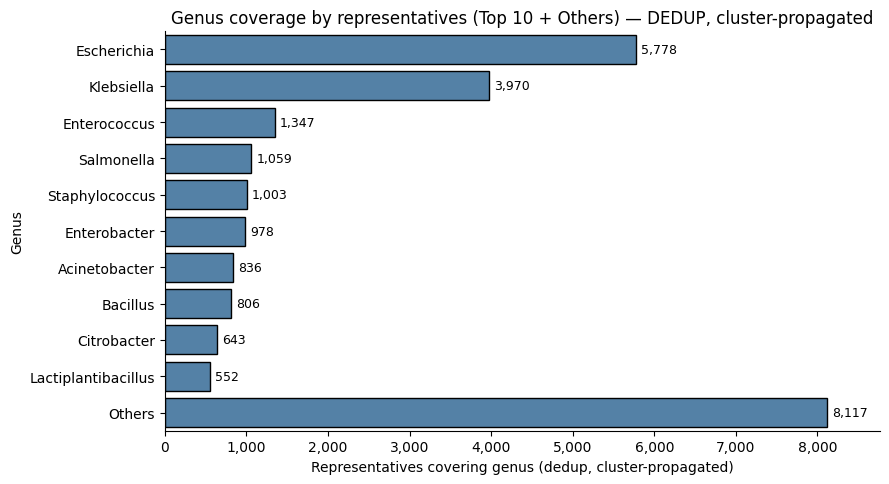

                  genus  n_representatives
0           Escherichia               5778
1            Klebsiella               3970
2          Enterococcus               1347
3            Salmonella               1059
4        Staphylococcus               1003
5          Enterobacter                978
6         Acinetobacter                836
7              Bacillus                806
8           Citrobacter                643
9   Lactiplantibacillus                552
10               Others               8117

Check: top10 (16,972) + Others (8,117) = 25,089 == Total (25,089)
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/figures/genus_top10_others.cluster_propagated.nreps.dedup.png
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/stats/genus_top10_others.cluster_propagated.nreps.dedup.tsv


In [11]:
# ================================================================
# Plásmidos por género (Top 10 + Others) — DEDUP con expansión por clúster
# - En lugar de usar SOLO el género del representante, contamos por
#   TODOS los géneros presentes en su clúster (reps_by_genus.tsv).
# - Métrica por defecto: nº de representantes que cubren cada género
#   (unique reps per genus). Opcional: ponderar por n_members_genus.
# - Exporta PNG en DFIGS y tabla en DSTATS
# ================================================================
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --------- Parámetros ----------
WEIGHTED = False  # False: cuenta reps únicos por género; True: suma n_members_genus
TOP_N    = 10

# --------- Cargar reps×género (del CHUNK 1) ----------
repG_path = DPROC / "reps_by_genus.tsv"
if not repG_path.exists():
    raise FileNotFoundError(f"No existe {repG_path}. Ejecuta antes el CHUNK 1 que genera reps_by_genus.tsv")
repG = pd.read_csv(repG_path, sep="\t", dtype={"rep_norm":str, "genus":str, "n_members_genus":str}).fillna("")
# asegurar tipos
repG["n_members_genus"] = pd.to_numeric(repG["n_members_genus"], errors="coerce").fillna(0).astype(int)
repG["genus"] = repG["genus"].astype(str)

def clean_genus_name(g):
    g = re.sub(r"\s*\([^)]*\)\s*$", "", str(g or "")).strip()
    g = re.sub(r"\s+", " ", g)
    return "Others" if g.lower() in {"other", "others"} else g

repG["genus_clean"] = repG["genus"].map(clean_genus_name)

# --------- Métrica de conteo por género ----------
if WEIGHTED:
    # suma de miembros del género dentro de los clústeres de reps (peso)
    series_counts = (repG.query("genus_clean != ''")
                        .groupby("genus_clean")["n_members_genus"]
                        .sum()
                        .sort_values(ascending=False))
    metric_name = "weight"
else:
    # nº de representantes únicos que cubren el género
    series_counts = (repG.query("genus_clean != ''")
                        .groupby("genus_clean")["rep_norm"]
                        .nunique()
                        .sort_values(ascending=False))
    metric_name = "n_representatives"

genus_counts_full = (series_counts
                     .rename("value")
                     .reset_index()
                     .rename(columns={"genus_clean":"genus", "value":metric_name}))

total_val = int(genus_counts_full[metric_name].sum())
print(f"Total ({metric_name}) across genera: {total_val:,}")

# --------- Top-N + Others ----------
core = genus_counts_full[genus_counts_full["genus"] != "Others"].copy()

topN = core.nlargest(TOP_N, metric_name).copy()
topN_sum = int(topN[metric_name].sum())

others_val = total_val - topN_sum
assert others_val >= 0

df_plot = pd.concat(
    [topN, pd.DataFrame([{"genus": "Others", metric_name: others_val}])],
    ignore_index=True
)

# Orden y “Others” al final
df_plot = df_plot.sort_values(metric_name, ascending=False).reset_index(drop=True)
others_row = df_plot[df_plot["genus"] == "Others"]
df_plot = pd.concat([df_plot[df_plot["genus"] != "Others"], others_row], ignore_index=True)

# --------- Plot ----------
plt.figure(figsize=(9, max(4, len(df_plot) * 0.45)))
ax = sns.barplot(
    data=df_plot,
    y="genus",
    x=metric_name,
    color="steelblue",
    edgecolor="black",
    errorbar=None
)

x_label = "Representatives covering genus (dedup, cluster-propagated)" if not WEIGHTED \
          else "Sum of members in clusters (dedup, cluster-propagated)"
title   = "Genus coverage by representatives (Top 10 + Others) — DEDUP, cluster-propagated"

ax.set_xlabel(x_label)
ax.set_ylabel("Genus")
ax.set_title(title)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
xmax = df_plot[metric_name].max()
ax.set_xlim(0, xmax * 1.08 if xmax > 0 else 1)
offset = max(10, int(max(1, xmax) * 0.008))

for i, row in df_plot.iterrows():
    ax.text(row[metric_name] + offset, i, f"{int(row[metric_name]):,}",
            va="center", ha="left", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

# --------- Salidas ----------
suffix = "nreps" if not WEIGHTED else "weighted"
out_png = DFIGS / f"genus_top{TOP_N}_others.cluster_propagated.{suffix}.dedup.png"
out_tsv = DSTATS / f"genus_top{TOP_N}_others.cluster_propagated.{suffix}.dedup.tsv"
plt.savefig(out_png, dpi=300)
plt.show()

df_plot.rename(columns={metric_name: "value"}).to_csv(out_tsv, sep="\t", index=False)

# --------- Sanity ----------
print(df_plot)
print(f"\nCheck: top{TOP_N} ({topN_sum:,}) + Others ({others_val:,}) = {topN_sum + others_val:,} == Total ({total_val:,})")
print(f"[OUT] {out_png}")
print(f"[OUT] {out_tsv}")


In [13]:
# ================================================================
# Construir tablas por clúster:
#   - DPROC/reps_by_genus_with_cluster.tsv  (level,cluster,rep_norm,genus,n_members_genus)
#   - DPROC/reps_by_genus.tsv               (rep_norm,genus,n_members_genus_sum)
# Requiere:
#   * DEDUP/louvain_by_level_from_table_including_isolates/cluster_assignments_by_level.tsv
#   * DEDUP/louvain_by_level_from_table_including_isolates/representatives_by_cluster_level.tsv
#   * RAW/plsdb_summary.csv  (PLSD_SUM)  -> taxonomía completa
# ================================================================
import pandas as pd
import numpy as np
import re, os
from pathlib import Path

# --- helpers (usa los que ya tienes en el notebook si existen) ---
def _normalize_id(x: str) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)): return x
    x = os.path.basename(str(x))
    for ext in (".faa", ".fa", ".fna", ".fasta", ".gz"):
        if x.endswith(ext): x = x[:-len(ext)]
    return x

def clean_genus_name(g):
    g = re.sub(r"\s*\([^)]*\)\s*$", "", str(g or "")).strip()
    g = re.sub(r"\s+", " ", g)
    return g

ASSIGN_TSV = DEDUP / "louvain_by_level_from_table_including_isolates" / "cluster_assignments_by_level.tsv"
REPS_TSV   = DEDUP / "louvain_by_level_from_table_including_isolates" / "representatives_by_cluster_level.tsv"

# --- cargar clustering ---
assign = pd.read_csv(ASSIGN_TSV, sep="\t", dtype=str).fillna("")
reps   = pd.read_csv(REPS_TSV,   sep="\t", dtype=str).fillna("")
assign["id_norm"] = assign["id"].map(_normalize_id)
reps["rep_norm"]  = reps["representative"].map(_normalize_id)
assign["level"]   = assign["level"].astype(str)
reps["level"]     = reps["level"].astype(str)

# --- taxonomía completa (no solo reps) ---
summ_all = pd.read_csv(PLSD_SUM, dtype=str).fillna("")
tax_all = (summ_all[[c for c in [
    "NUCCORE_ACC","TAXONOMY.TAXONOMY_genus",
    "TAXONOMY.TAXONOMY_species","TAXONOMY.TAXONOMY_taxon_name"
] if c in summ_all.columns]]
    .rename(columns={"NUCCORE_ACC":"plasmid_id"}))
tax_all["__pid_norm__"] = tax_all["plasmid_id"].map(_normalize_id)
tax_all["genus"] = tax_all.get("TAXONOMY.TAXONOMY_genus", "").map(clean_genus_name)
tax_all["species"] = tax_all.get("TAXONOMY.TAXONOMY_species", "")
mask = (tax_all["species"] == "") | (tax_all["species"].isna())
if "TAXONOMY.TAXONOMY_taxon_name" in tax_all.columns:
    tax_all.loc[mask, "species"] = tax_all.loc[mask, "TAXONOMY.TAXONOMY_taxon_name"]
tax_all = tax_all[["__pid_norm__", "genus", "species"]].drop_duplicates()

# --- miembros con tax + representante del clúster ---
members = assign.merge(tax_all, left_on="id_norm", right_on="__pid_norm__", how="left").drop(columns=["__pid_norm__"])
members["genus"] = members["genus"].fillna("").astype(str)
members = members.merge(reps[["level","cluster","rep_norm"]], on=["level","cluster"], how="left")

# --- tabla por clúster: (level, cluster, rep_norm, genus, n_members_genus) ---
repG_cluster = (members
    .groupby(["level","cluster","rep_norm","genus"], dropna=False)
    .agg(n_members_genus=("id_norm","nunique"))
    .reset_index())

# opcional: si no quieres contar genus vacío
repG_cluster = repG_cluster[repG_cluster["genus"] != ""].copy()

# guardar
out_cluster = DPROC / "reps_by_genus_with_cluster.tsv"
repG_cluster.to_csv(out_cluster, sep="\t", index=False)
print(f"[OUT] {out_cluster}  (rows={len(repG_cluster):,})")

# --- versión compacta por representante (suma de miembros por género) ---
rep_by_genus = (repG_cluster
                .groupby(["rep_norm","genus"], dropna=False)["n_members_genus"]
                .sum()
                .reset_index()
                .sort_values(["rep_norm","n_members_genus"], ascending=[True, False])
                .reset_index(drop=True))
out_rep_by_genus = DPROC / "reps_by_genus.tsv"
rep_by_genus.to_csv(out_rep_by_genus, sep="\t", index=False)
print(f"[OUT] {out_rep_by_genus}  (rows={len(rep_by_genus):,})")

# --- sanity rápido ---
n_clusters = repG_cluster.drop_duplicates(subset=["level","cluster"]).shape[0]
n_reps     = reps["rep_norm"].nunique()
print(f"[SUMMARY] clusters únicos: {n_clusters:,} | reps únicos: {n_reps:,}")
print(repG_cluster.head())


[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/reps_by_genus_with_cluster.tsv  (rows=25,089)
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/processed/reps_by_genus.tsv  (rows=25,089)
[SUMMARY] clusters únicos: 23,609 | reps únicos: 23,798
  level cluster       rep_norm          genus  n_members_genus
0     1       0  NZ_CP139269.1  Acinetobacter                1
1     1       1  NZ_CP139267.1  Acinetobacter                2
2     1      10  NZ_CP139261.1  Acinetobacter                1
3     1     100    NC_001373.1    Escherichia                1
4     1    1000  NZ_CP132068.1       Bacillus                1


In [14]:
# ================================================================
# Filtrado por género con N mínimo (DEDUP)
# - Construye rep_per_plasmid si no existe (desde mob_filt)
# - Adjunta genus del REP (tax)  ➜ dfg (modo clásico)
# - (Opcional) Modo clúster: cuenta por géneros presentes en el clúster
#   usando DPROC/reps_by_genus_with_cluster.tsv ➜ dfg_cluster
# - Devuelve dfg.shape y nº de géneros retenidos (modo clásico)
# ================================================================
import re
import pandas as pd
import numpy as np

MIN_N_PER_GENUS = 100  # ajusta según necesites

def clean_genus_name(g):
    g = re.sub(r"\s*\([^)]*\)\s*$", "", str(g or "")).strip()
    g = re.sub(r"\s+", " ", g)
    return g

def split_unique_csv(x: str):
    parts = [t.strip() for t in str(x or "").split(",") if t.strip()]
    return list(dict.fromkeys(parts))

# ---------------- rep_per_plasmid (solo representantes) ----------------
if "rep_per_plasmid" not in globals():
    if "rep_type" not in mob_filt.columns:
        raise KeyError("Column 'rep_type' not found in mob_filt.")
    rep_per_plasmid = pd.DataFrame({
        "plasmid_id": mob_filt["plasmid_id"].values,
        "rep_count":  mob_filt["rep_type"].apply(split_unique_csv).apply(len)
    })
    rep_per_plasmid["__pid_norm__"] = rep_per_plasmid["plasmid_id"].map(_normalize_id)

    tax_norm = tax.copy()
    if "__pid_norm__" not in tax_norm.columns:
        tax_norm["__pid_norm__"] = tax_norm["plasmid_id"].map(_normalize_id)
    tax_norm["genus"] = tax_norm["genus"].map(clean_genus_name)

    rep_per_plasmid = rep_per_plasmid.merge(
        tax_norm[["__pid_norm__", "genus"]],
        on="__pid_norm__", how="left"
    )

# ---------------- Modo clásico (género del representante) ----------------
genus_sizes = rep_per_plasmid["genus"].value_counts(dropna=False)
# si no quieres el género vacío como categoría válida:
genus_sizes = genus_sizes[genus_sizes.index.notna() & (genus_sizes.index != "")]

keep_genera = genus_sizes[genus_sizes >= MIN_N_PER_GENUS].index
dfg = rep_per_plasmid[rep_per_plasmid["genus"].isin(keep_genera)].copy()

print(f"[CLASSIC] géneros retenidos: {len(keep_genera)} | N filas: {len(dfg)}")

# ---------------- (Opcional) Modo clúster (géneros del clúster) ----------------
# Si existe la tabla por clúster, construimos también dfg_cluster:
cluster_tbl = DPROC / "reps_by_genus_with_cluster.tsv"
if cluster_tbl.exists():
    repG_cluster = pd.read_csv(cluster_tbl, sep="\t", dtype=str).fillna("")
    # repG_cluster: level, cluster, rep_norm, genus, n_members_genus
    repG_cluster = repG_cluster[repG_cluster["genus"] != ""].copy()

    # Conteo por género (nº de CLÚSTERES únicos que cubren el género)
    genus_sizes_cluster = (repG_cluster
                           .drop_duplicates(subset=["genus","level","cluster"])
                           .groupby("genus")[["level","cluster"]]
                           .size()
                           .sort_values(ascending=False))

    keep_genera_cluster = genus_sizes_cluster[genus_sizes_cluster >= MIN_N_PER_GENUS].index

    # Construimos dfg_cluster ligando cada representante a los géneros que cubre su clúster,
    # y uniendo rep_count del representante
    rep_counts_min = rep_per_plasmid[["__pid_norm__", "plasmid_id", "rep_count"]].drop_duplicates()
    rep_counts_min = rep_counts_min.rename(columns={"__pid_norm__":"rep_norm"})

    dfg_cluster = (repG_cluster.merge(rep_counts_min, on="rep_norm", how="left")
                              .query("genus in @keep_genera_cluster")
                              .drop_duplicates(subset=["genus","rep_norm"]))

    print(f"[CLUSTER] géneros retenidos: {len(keep_genera_cluster)} | N filas (rep×género): {len(dfg_cluster)}")
else:
    print("[CLUSTER] Aviso: no existe reps_by_genus_with_cluster.tsv — omito modo clúster.")

# --------- Salida pedida (modo clásico) ---------
dfg.shape, dfg["genus"].nunique()


[CLASSIC] géneros retenidos: 31 | N filas: 19758
[CLUSTER] géneros retenidos: 32 | N filas (rep×género): 21150


((19758, 5), 31)

In [15]:
# ================================================================
# Kruskal–Wallis test: ¿difieren los rep_count entre géneros?
# - Modo clásico: dfg (género del representante)
# - Modo clúster (si existe): dfg_cluster (géneros del clúster)
# ================================================================
from scipy.stats import kruskal

def kruskal_by_genus(df, value_col="rep_count", group_col="genus", label="classic"):
    """Aplica Kruskal–Wallis y devuelve H, p y n grupos."""
    groups = [g[value_col].dropna().values for _, g in df.groupby(group_col)]
    if len(groups) < 2:
        print(f"[{label}] ❌ No hay suficientes géneros para comparar.")
        return np.nan, np.nan
    kw_stat, kw_p = kruskal(*groups)
    print(f"[{label}] Kruskal–Wallis H={kw_stat:.2f}, p={kw_p:.3e}  (H₀: distribuciones idénticas entre géneros)")
    return kw_stat, kw_p

# --- modo clásico (representante) ---
kw_stat_classic, kw_p_classic = kruskal_by_genus(dfg, value_col="rep_count", group_col="genus", label="CLASSIC")

# --- modo clúster (si existe tabla) ---
if "dfg_cluster" in globals():
    kw_stat_cluster, kw_p_cluster = kruskal_by_genus(dfg_cluster, value_col="rep_count", group_col="genus", label="CLUSTER")
else:
    print("[CLUSTER] No se encontró dfg_cluster, sólo se evalúa modo clásico.")


[CLASSIC] Kruskal–Wallis H=2362.57, p=0.000e+00  (H₀: distribuciones idénticas entre géneros)
[CLUSTER] Kruskal–Wallis H=2304.18, p=0.000e+00  (H₀: distribuciones idénticas entre géneros)


In [17]:
# ================================================================
# Poisson (robusto) para rep_count ~ genus (clásico o clúster)
# - Contraste global por LR (full vs null)
# - Wald global sobre todos los términos de género
# - Predicciones por género (media esperada) con IC95%
# ================================================================
import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm
from scipy.stats import chi2

USE_CLUSTER = False  # True -> usar dfg_cluster

df = dfg_cluster.copy() if USE_CLUSTER and "dfg_cluster" in globals() else dfg.copy()
df = df.loc[df["genus"].notna() & (df["genus"] != ""), ["genus", "rep_count"]].copy()
df["rep_count"] = pd.to_numeric(df["rep_count"], errors="coerce")
df = df.dropna(subset=["rep_count"])

# Referencia = género más abundante (cámbialo si quieres)
ref = df["genus"].value_counts().idxmax()
formula = f"rep_count ~ C(genus, Treatment(reference='{ref}'))"

y, X = patsy.dmatrices(formula, data=df, return_type="dataframe")
y = y.iloc[:, 0]

# ---------- Poisson + errores robustos (HC3) ----------
glm_pois = sm.GLM(y, X, family=sm.families.Poisson())
res_pois = glm_pois.fit(cov_type="HC3")  # robust
dispersion = res_pois.pearson_chi2 / res_pois.df_resid if res_pois.df_resid > 0 else np.nan
print(f"[Poisson robust] Pearson chi2/df (dispersion): {dispersion:.2f} | AIC={res_pois.aic:.1f}")

# ---------- Test global (LR) ----------
# Modelo nulo: solo intercepto
X_null = X[["Intercept"]]
res_null = sm.GLM(y, X_null, family=sm.families.Poisson()).fit()
LR = 2 * (res_pois.llf - res_null.llf)
df_LR = (X.shape[1] - X_null.shape[1])
p_LR = chi2.sf(LR, df_LR)
print(f"[LR global] 2ΔLL = {LR:.2f}, df = {df_LR}, p = {p_LR:.3e}")

# ---------- Wald global (todos los términos de género) ----------
terms = [c for c in X.columns if c != "Intercept"]
if terms:
    R = np.zeros((len(terms), len(X.columns)))
    for i, name in enumerate(terms):
        R[i, X.columns.get_loc(name)] = 1.0
    wald = res_pois.wald_test(R)
    print(f"[Wald global] chi2 = {float(wald.statistic):.2f}, df = {int(wald.df_denom)}, p = {float(wald.pvalue):.3e}")
else:
    print("[Wald global] No hay términos de género (solo intercepto).")

# ---------- Predicciones por género (media esperada) + IC95% ----------
levels = [ref] + sorted([g for g in df["genus"].unique() if g != ref])
pred_df = pd.DataFrame({"genus": levels})
X_pred = patsy.dmatrix(f"C(genus, Treatment(reference='{ref}'))", data=pred_df, return_type="dataframe")

# predicción en el link (log) + IC con cov robusta
lin = np.asarray(X_pred @ res_pois.params.values)
cov = res_pois.cov_params().reindex(index=X.columns, columns=X.columns)
var_lin = np.einsum("ij,jk,ik->i", X_pred.values, cov.values, X_pred.values)
se_lin = np.sqrt(np.clip(var_lin, 0, np.inf))
z = 1.959964

mu_hat = np.exp(lin)
mu_lo  = np.exp(lin - z*se_lin)
mu_hi  = np.exp(lin + z*se_lin)

effects = (pd.DataFrame({
    "genus": levels,
    "expected_rep_count": mu_hat,
    "ci95_low": mu_lo,
    "ci95_high": mu_hi,
    "n_obs": df["genus"].value_counts().reindex(levels).fillna(0).astype(int).values
})
.sort_values("expected_rep_count", ascending=False))

print("\nMedias esperadas por género (Poisson robust) — top 15:")
display(effects.head(15))


[Poisson robust] Pearson chi2/df (dispersion): 0.38 | AIC=51700.1
[LR global] 2ΔLL = 1086.53, df = 30, p = 2.653e-209
[Wald global] chi2 = 14411.30, df = 29, p = 0.000e+00

Medias esperadas por género (Poisson robust) — top 15:


/home/nacho/.local/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 29
  warnings.warn('covariance of constraints does not have full '
/home/nacho/.local/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/tmp/ipykernel_3300627/226418607.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"[Wald global] chi2 = {float(wald.statistic):.2f}, df = {int(wald.df_denom)}, p = {float(wald.pvalue):.3e}")


,genus,expected_rep_count,ci95_low,ci95_high,n_obs
12,Klebsiella (570),1.836123,1.804116,1.868698,3704
0,Escherichia (561),1.758929,1.733309,1.784927,5488
27,Staphylococcus (1279),1.665000,1.608867,1.723092,1000
21,Raoultella (160674),1.604651,1.478453,1.741621,129
9,Enterobacter (547),1.579075,1.532196,1.627390,822
23,Salmonella (590),1.457607,1.408794,1.508112,861
7,Citrobacter (544),1.454724,1.388780,1.523801,508
25,Shigella (620),1.420561,1.335307,1.511257,214
10,Enterococcus (1350),1.300595,1.269081,1.332892,1344
24,Serratia (613),1.272251,1.191651,1.358303,191


[Chi-square] χ²=2101.62, df=31, p=0.000e+00  (H0: same cointegrate rate across genera)
[Cramér’s V] V_bc = 0.313   | Expected-counts check: OK

[Top + contributors to cointegrate (std. residuals)]:
genus
Klebsiella        16.305372
Escherichia       14.188949
Enterobacter       5.166733
Staphylococcus     4.316692
Raoultella         1.651341
Shigella          -0.982802
Salmonella        -1.702172
Citrobacter       -1.810027
Providencia       -1.889882
Phaeobacter       -2.161735

[Top – contributors to cointegrate (std. residuals)]:
genus
Acinetobacter   -13.070500
Pseudomonas      -8.060083
Priestia         -7.825762
Rhizobium        -7.240837
Clostridium      -7.003931
Pantoea          -6.917943
Aeromonas        -6.641163
Vibrio           -6.572365
Enterococcus     -6.506869
Burkholderia     -6.011657

[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/stats/cointegrate/cointegrate_rates_per_genus.cluster.tsv
[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/stats/cointegrate/

/tmp/ipykernel_3300627/2201408358.py:102: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


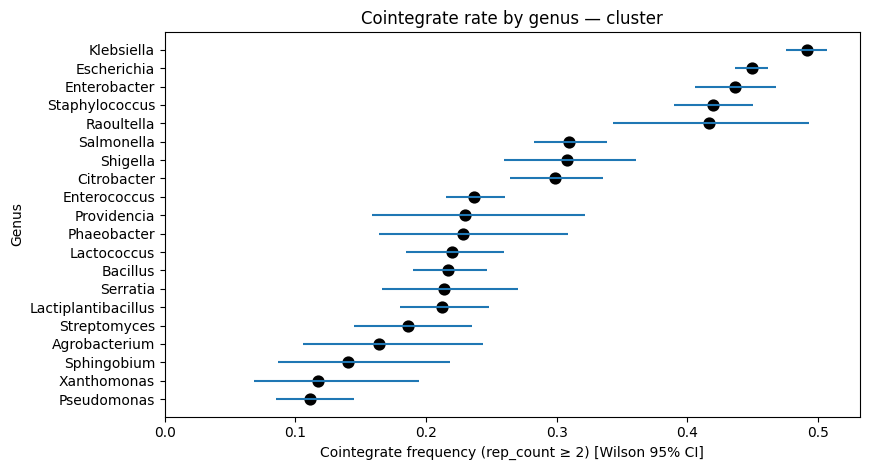

[OUT] /home/nacho/HDD16/Nacho/RepliCOOC/derep/results/figures/cointegrate/cointegrate_rate_top20.cluster.png

[Overall] p=0.340  (n=21150, k=7196)  Wilson95% CI=(0.334, 0.347)


In [21]:
# ================================================================
# Cointegrate rate (rep_count ≥ 2) across genera — χ² test + CIs
# - Works with classic (dfg) or cluster-propagated (dfg_cluster)
# - Reports Cramér’s V (with bias correction), expected counts check,
#   standardized residuals (contributors), and Wilson 95% CIs per genus
# - Saves table and figure in DRES/DSTATS/DFIGS
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chi2
from statsmodels.stats.proportion import proportion_confint

USE_CLUSTER = True  # True → usar dfg_cluster (géneros propagados por clúster)

# -------- Pick dataset --------
DF = dfg_cluster.copy() if USE_CLUSTER and "dfg_cluster" in globals() else dfg.copy()
DF = DF.loc[DF["genus"].notna() & (DF["genus"] != ""), ["genus","rep_count"]].copy()
DF["rep_count"] = pd.to_numeric(DF["rep_count"], errors="coerce")
DF = DF.dropna(subset=["rep_count"])

# -------- Build binary outcome: cointegrate (≥2 replicons) --------
DF["cointegrate"] = (DF["rep_count"] >= 2).astype(int)

# -------- Contingency table --------
ct = pd.crosstab(DF["genus"], DF["cointegrate"])  # columns: 0, 1
# Ensure both columns present
for col in [0,1]:
    if col not in ct.columns:
        ct[col] = 0
ct = ct[[0,1]]

# -------- Chi-square test --------
chi2_stat, p_chi2, dof, expected = chi2_contingency(ct, correction=False)  # >2x2, no Yates
n_tot = ct.values.sum()

# Expected count diagnostics
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
viol_mask = expected_df < 5
n_viol = int(viol_mask.sum().sum())
flag_msg = "OK" if n_viol == 0 else f"{n_viol} cells with expected < 5 (consider collapsing rare genera or increasing MIN_N_PER_GENUS)."

# Cramér’s V (bias-corrected)
r, k = ct.shape
phi2 = chi2_stat / n_tot
phi2_corr = max(0.0, phi2 - ((k-1)*(r-1)) / (n_tot - 1)) if n_tot > 1 else 0.0
r_corr = r - ((r-1)**2) / (n_tot - 1) if n_tot > 1 else r
k_corr = k - ((k-1)**2) / (n_tot - 1) if n_tot > 1 else k
den = max(1e-12, min((k_corr-1), (r_corr-1)))
cramers_v = np.sqrt(phi2_corr / den)

print(f"[Chi-square] χ²={chi2_stat:.2f}, df={dof}, p={p_chi2:.3e}  (H0: same cointegrate rate across genera)")
print(f"[Cramér’s V] V_bc = {cramers_v:.3f}   | Expected-counts check: {flag_msg}")

# -------- Standardized residuals (contributors) --------
# SR = (obs - exp)/sqrt(exp)
sr = (ct - expected_df) / np.sqrt(expected_df.replace(0, np.nan))
sr = sr.replace([np.inf, -np.inf], np.nan)

top_pos = (sr[1].sort_values(ascending=False).head(10)
           .rename("std_resid_cointegrate"))
top_neg = (sr[1].sort_values(ascending=True).head(10)
           .rename("std_resid_cointegrate"))
print("\n[Top + contributors to cointegrate (std. residuals)]:")
print(top_pos.to_string())
print("\n[Top – contributors to cointegrate (std. residuals)]:")
print(top_neg.to_string())

# -------- Per-genus rates with Wilson 95% CI --------
rates = (DF.groupby("genus")["cointegrate"]
           .agg(n="count", k="sum")
           .assign(prop=lambda x: x.k/x.n)
           .reset_index())
ci_low, ci_high = proportion_confint(rates["k"], rates["n"], method="wilson")
rates["ci_low"], rates["ci_high"] = ci_low, ci_high
rates = rates.sort_values("prop", ascending=False)

# Save tables
suffix = "cluster" if USE_CLUSTER else "classic"
(DSTATS / "cointegrate").mkdir(parents=True, exist_ok=True)
rates_out    = DSTATS / "cointegrate" / f"cointegrate_rates_per_genus.{suffix}.tsv"
ct_out       = DSTATS / "cointegrate" / f"contingency_table.{suffix}.tsv"
expected_out = DSTATS / "cointegrate" / f"expected_counts.{suffix}.tsv"
sr_out       = DSTATS / "cointegrate" / f"std_residuals.{suffix}.tsv"

rates.to_csv(rates_out, sep="\t", index=False)
ct.to_csv(ct_out, sep="\t")
expected_df.to_csv(expected_out, sep="\t")
sr.to_csv(sr_out, sep="\t")

print(f"\n[OUT] {rates_out}")
print(f"[OUT] {ct_out}")
print(f"[OUT] {expected_out}")
print(f"[OUT] {sr_out}")

# -------- Quick figure: top 12 genera by rate (with Wilson CI) --------
TOP = 20
top_plot = rates.head(TOP).copy()

plt.figure(figsize=(8.8, 4.8))
ax = sns.pointplot(
    data=top_plot,
    y="genus", x="prop",
    join=False, errorbar=None, color="black"
)
# draw CIs manually
for i, row in top_plot.iterrows():
    ax.hlines(y=top_plot.index.get_loc(i),
              xmin=row["ci_low"], xmax=row["ci_high"])
ax.set_xlabel("Cointegrate frequency (rep_count ≥ 2) [Wilson 95% CI]")
ax.set_ylabel("Genus")
ax.set_xlim(0, min(1.0, max(0.05, float(top_plot["ci_high"].max())*1.05)))
ax.set_title(f"Cointegrate rate by genus — {suffix}")
plt.tight_layout()

(DFIGS / "cointegrate").mkdir(parents=True, exist_ok=True)
fig_out = DFIGS / "cointegrate" / f"cointegrate_rate_top{TOP}.{suffix}.png"
plt.savefig(fig_out, dpi=300)
plt.show()
print(f"[OUT] {fig_out}")

# -------- Optional: global CI for overall proportion --------
k_all = int(DF["cointegrate"].sum())
n_all = int(DF.shape[0])
p_all = k_all / n_all if n_all > 0 else np.nan
ci_all = proportion_confint(k_all, n_all, method="wilson") if n_all > 0 else (np.nan, np.nan)
print(f"\n[Overall] p={p_all:.3f}  (n={n_all}, k={k_all})  Wilson95% CI=({ci_all[0]:.3f}, {ci_all[1]:.3f})")


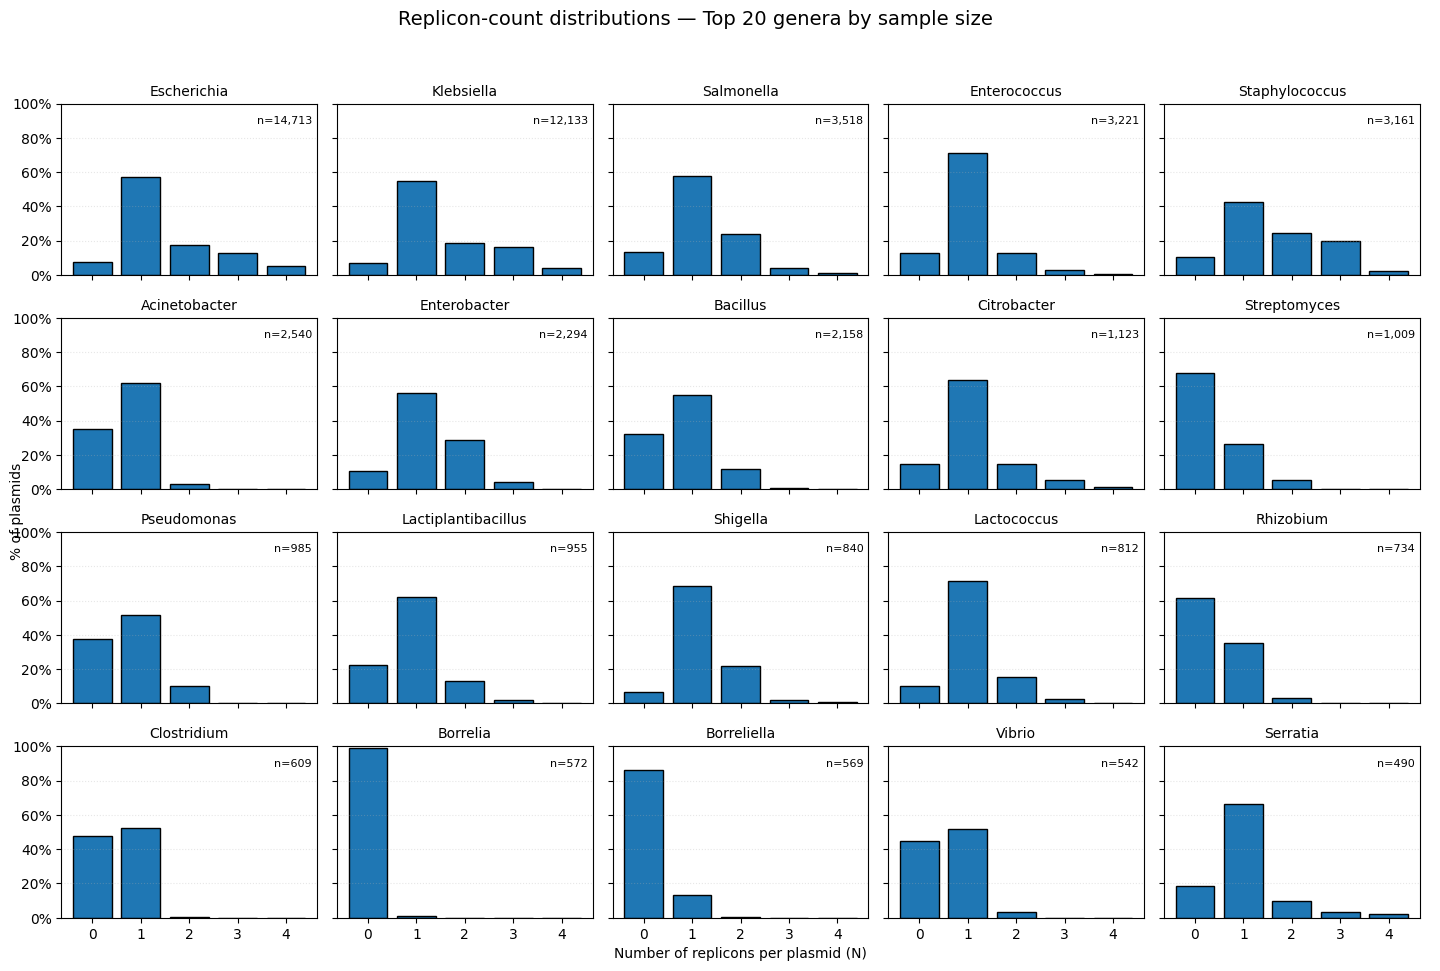

✅ Figure saved to: /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/replicon_count_distribution_top20_panels.png


In [46]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- ensure we have rep_per_plasmid with ['plasmid_id','rep_count','genus'] ---
def split_unique_csv(x: str):
    parts = [t.strip() for t in str(x or "").split(",") if t.strip()]
    return list(dict.fromkeys(parts))

def clean_genus_name(g):
    g = re.sub(r"\s*\([^)]*\)\s*$", "", str(g or "")).strip()
    g = re.sub(r"\s+", " ", g)
    return g

if "rep_per_plasmid" not in globals():
    mob["rep_tokens"] = mob["rep_type"].apply(split_unique_csv)
    rep_per_plasmid = pd.DataFrame({
        "plasmid_id": mob["plasmid_id"],
        "rep_count":  mob["rep_tokens"].apply(len)
    })
    tax = (summ[["NUCCORE_ACC","TAXONOMY.TAXONOMY_genus"]]
           .rename(columns={"NUCCORE_ACC":"plasmid_id","TAXONOMY.TAXONOMY_genus":"genus"}))
    tax["genus"] = tax["genus"].map(clean_genus_name)
    rep_per_plasmid = rep_per_plasmid.merge(tax, on="plasmid_id", how="left")

rep_per_plasmid["genus"] = rep_per_plasmid["genus"].map(clean_genus_name)
rep_per_plasmid = rep_per_plasmid[rep_per_plasmid["genus"] != ""].copy()

# --- pick top 20 genera by sample size ---
top20 = rep_per_plasmid["genus"].value_counts().head(20).index.tolist()
df20  = rep_per_plasmid[rep_per_plasmid["genus"].isin(top20)].copy()

# Consistent N (rep_count) range across all panels
N_max = int(df20["rep_count"].max())
N_levels = list(range(0,5))  # change to range(0,7) if you want to cap at 6

# Build % distribution per genus
dist = (
    df20.groupby("genus")["rep_count"]
        .value_counts()
        .rename("n")
        .reset_index()
        .set_index(["genus","rep_count"])
        .reindex(pd.MultiIndex.from_product([top20, N_levels], names=["genus","rep_count"]),
                 fill_value=0)
        .reset_index()
)

totals = dist.groupby("genus")["n"].transform("sum")
dist["percent"] = 100.0 * dist["n"] / totals
# keep order of top20 in plotting
dist["genus"] = pd.Categorical(dist["genus"], categories=top20, ordered=True)
dist = dist.sort_values(["genus","rep_count"])

# --- plot: 4×5 small multiples ---
nrows, ncols = 4, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genus in zip(axes, top20):
    sub = dist[dist["genus"] == genus]
    ax.bar(sub["rep_count"], sub["percent"], edgecolor="black")
    ax.set_title(genus, fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.set_ylim(0, max(20, np.ceil(dist["percent"].max()/5)*5))  # auto but tidy
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    # optional: show N for this genus in corner
    N_genus = int(totals[sub.index[0]])
    ax.text(0.98, 0.90, f"n={N_genus:,}", ha="right", va="center", transform=ax.transAxes, fontsize=8)

# Empty panels if fewer than 20 (shouldn’t happen, but just in case)
for ax in axes[len(top20):]:
    ax.axis("off")

fig.add_subplot(111, frame_on=False)
plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
plt.xlabel("Number of replicons per plasmid (N)")
plt.ylabel("% of plasmids")
plt.suptitle("Replicon-count distributions — Top 20 genera by sample size", y=0.99, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])

out_path = FIGS / "replicon_count_distribution_top20_panels.png"
plt.savefig(out_path, dpi=300)
plt.show()
print(f"✅ Figure saved to: {out_path}")


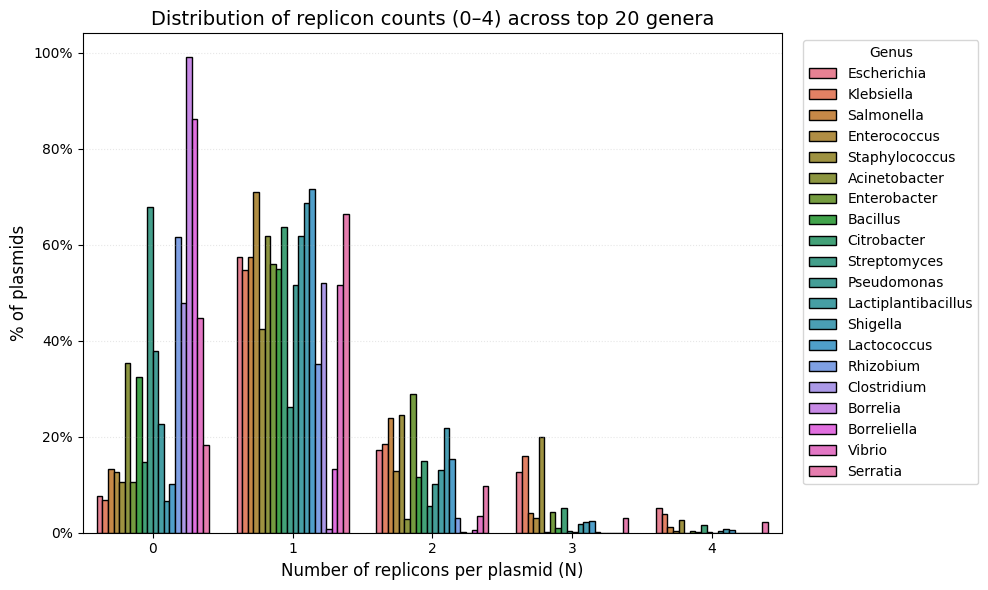

✅ Figure saved to: /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/replicon_count_distribution_top20_grouped_0to4.png


In [45]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# === Clean genus names ===
def clean_genus_name(g):
    g = re.sub(r"\s*\([^)]*\)\s*$", "", str(g or "")).strip()
    g = re.sub(r"\s+", " ", g)
    return g

rep_per_plasmid["genus"] = rep_per_plasmid["genus"].map(clean_genus_name)
rep_per_plasmid = rep_per_plasmid[rep_per_plasmid["genus"] != ""].copy()

# === Select top 20 genera by sample size ===
top20 = rep_per_plasmid["genus"].value_counts().head(20).index.tolist()
df20 = rep_per_plasmid[rep_per_plasmid["genus"].isin(top20)].copy()

# === Build % distribution per genus (limit to 0–4 replicons) ===
N_levels = list(range(0, 5))  # only 0,1,2,3,4

dist = (
    df20.groupby("genus")["rep_count"]
        .value_counts()
        .rename("n")
        .reset_index()
        .set_index(["genus","rep_count"])
        .reindex(pd.MultiIndex.from_product([top20, N_levels], names=["genus","rep_count"]),
                 fill_value=0)
        .reset_index()
)

# Normalize to %
totals = dist.groupby("genus")["n"].transform("sum")
dist["percent"] = 100.0 * dist["n"] / totals
dist["genus"] = pd.Categorical(dist["genus"], categories=top20, ordered=True)

# === Plot ===
plt.figure(figsize=(10,6))
sns.barplot(
    data=dist,
    x="rep_count", y="percent",
    hue="genus",
    edgecolor="black",
    dodge=True
)

plt.xlabel("Number of replicons per plasmid (N)", fontsize=12)
plt.ylabel("% of plasmids", fontsize=12)
plt.title("Distribution of replicon counts (0–4) across top 20 genera", fontsize=14)
plt.gca().yaxis.set_major_formatter(PercentFormatter(100))
plt.xticks(N_levels)
plt.grid(axis="y", linestyle=":", alpha=0.3)
plt.legend(title="Genus", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
plt.tight_layout()

out_path = FIGS / "replicon_count_distribution_top20_grouped_0to4.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"✅ Figure saved to: {out_path}")


[info] Plásmidos con al menos 1 replicón: 53,229
[info] Plásmidos con tamaño + rep_count>0 en Top20: 44,979


/tmp/ipykernel_302647/465499606.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for g, sub in df20.groupby("genus"):


,genus,n,spearman_rho,p_value
0,Escherichia,13674,0.592293,0.000000e+00
1,Klebsiella,11365,0.608499,0.000000e+00
2,Salmonella,3056,0.406258,8.491821e-122
3,Staphylococcus,2841,0.493809,1.470617e-174
4,Enterococcus,2815,0.242169,7.486640e-39
5,Enterobacter,2056,0.592479,4.228293e-195
6,Acinetobacter,1642,0.078211,1.515599e-03
7,Bacillus,1457,0.258724,1.031151e-23
8,Citrobacter,959,0.387334,1.098978e-35
9,Shigella,785,0.392626,2.467501e-30


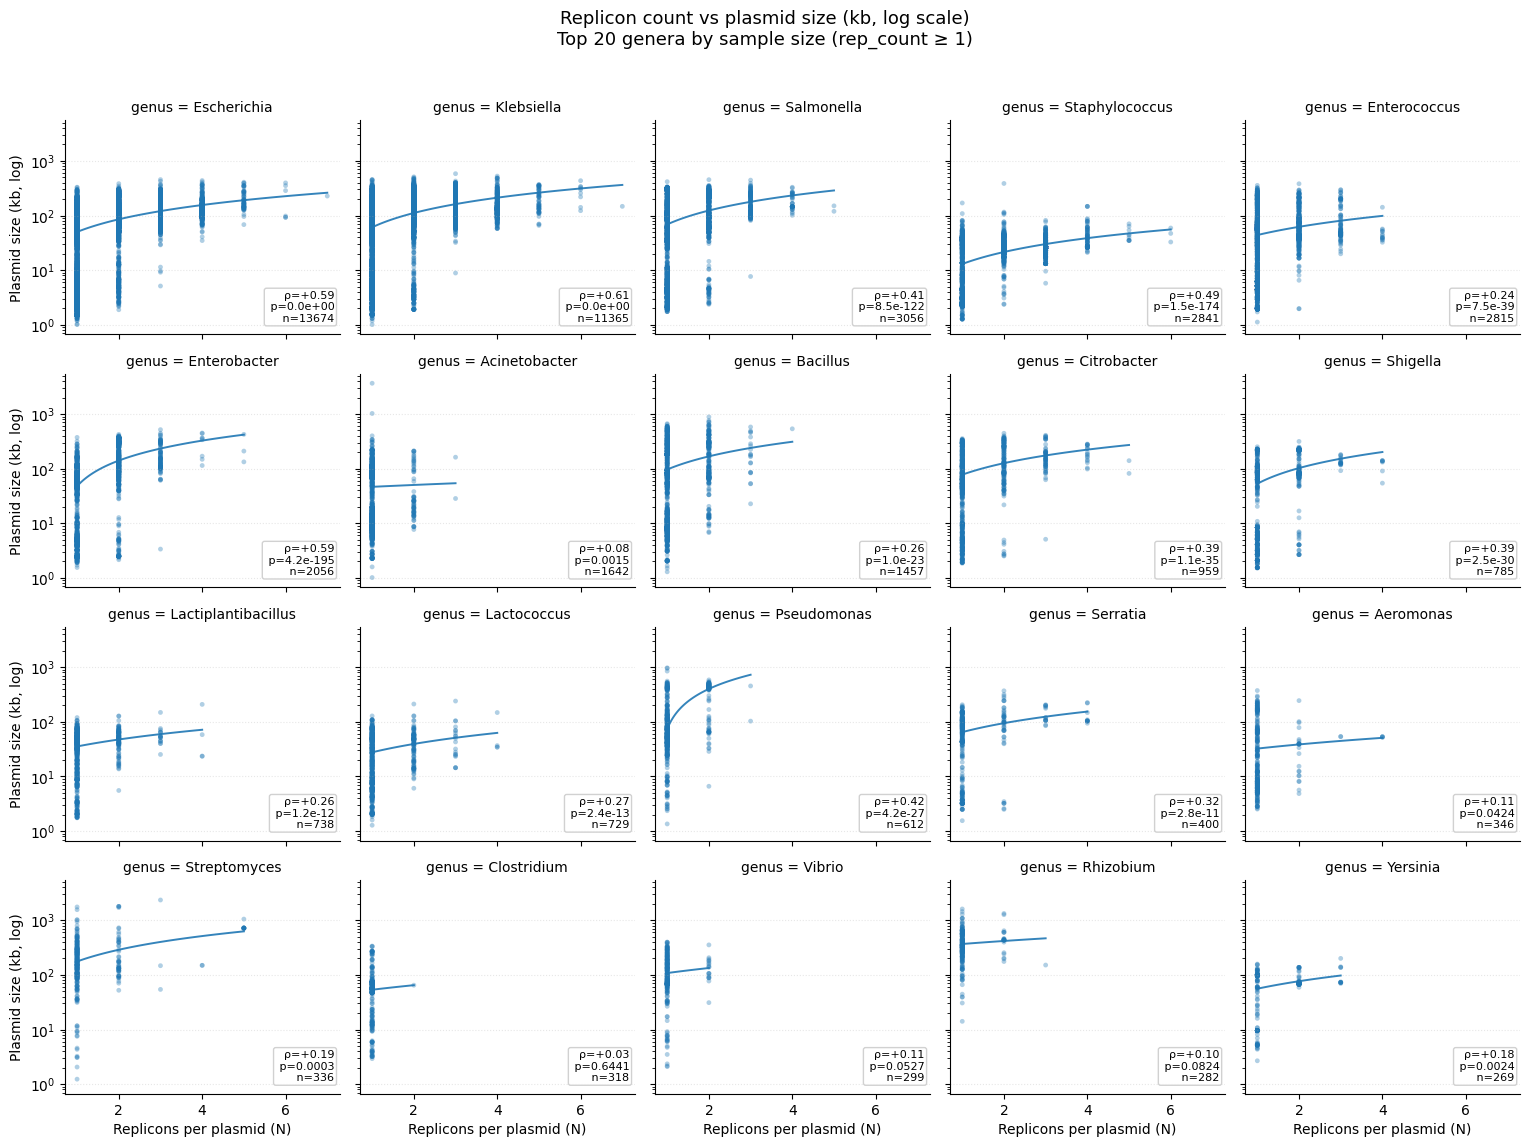

✅ Figure saved to: /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/repcount_vs_length_facet_top20_min1rep.png
✅ Correlations table saved to: /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/repcount_vs_length_spearman_by_genus_top20.tsv


In [65]:
# ============================================
# Replicon count vs plasmid size (facet por género Top-20)
# excluyendo plásmidos sin replicones (rep_count = 0)
# ============================================
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

# ---- rutas
BASE = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
FIGS = BASE / "results" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
STATS = BASE / "results" / "stats";   STATS.mkdir(parents=True, exist_ok=True)

# ---- helpers
def split_unique_csv(x: str):
    parts = [t.strip() for t in str(x or "").split(",") if t.strip()]
    return list(dict.fromkeys(parts))  # sin duplicados, preservando orden

def clean_genus_name(g):
    g = re.sub(r"\s*\([^)]*\)\s*$", "", str(g or "")).strip()
    g = re.sub(r"\s+", " ", g)
    return g

def fmt_pval(p):
    if p is None or np.isnan(p):
        return "NA"
    if p < 1e-4:
        return f"{p:.1e}"
    return f"{p:.4f}"

# ---- construir rep_per_plasmid si no existe
if "rep_per_plasmid" not in globals():
    assert "mob" in globals(),  "Necesito `mob` cargado (plsdb_mob.csv)."
    assert "summ" in globals(), "Necesito `summ` cargado (plsd_summary.csv)."

    mob = mob.copy()
    if "plasmid_id" not in mob.columns and "NUCCORE_ACC" in mob.columns:
        mob = mob.rename(columns={"NUCCORE_ACC":"plasmid_id"})
    mob["rep_tokens"] = mob["rep_type"].apply(split_unique_csv)

    rep_per_plasmid = pd.DataFrame({
        "plasmid_id": mob["plasmid_id"],
        "rep_count":  mob["rep_tokens"].apply(len)
    })

    # detectar columna de género en summ
    genus_col = None
    for c in ["TAXONOMY.TAXONOMY_genus", "genus", "Genus"]:
        if c in summ.columns:
            genus_col = c; break
    assert genus_col is not None, "No encuentro columna de género en `summ`."

    id_col_summ = "plasmid_id" if "plasmid_id" in summ.columns else \
                  ("NUCCORE_ACC" if "NUCCORE_ACC" in summ.columns else None)
    assert id_col_summ is not None, "No encuentro columna de ID en `summ`."

    tax = (summ[[id_col_summ, genus_col]]
           .rename(columns={id_col_summ:"plasmid_id", genus_col:"genus"}))
    tax["genus"] = tax["genus"].map(clean_genus_name)

    rep_per_plasmid = rep_per_plasmid.merge(tax, on="plasmid_id", how="left")

# limpieza básica
rep_per_plasmid = rep_per_plasmid.copy()
rep_per_plasmid["genus"] = rep_per_plasmid["genus"].map(clean_genus_name)
rep_per_plasmid = rep_per_plasmid[rep_per_plasmid["genus"] != ""].copy()

# ---- añadir tamaño del plásmido desde `summ`
len_id_col = "plasmid_id" if "plasmid_id" in summ.columns else \
             ("NUCCORE_ACC" if "NUCCORE_ACC" in summ.columns else None)
assert len_id_col is not None, "No encuentro columna de ID para longitudes en `summ`."

len_df = summ[[len_id_col, "Length"]].rename(columns={len_id_col:"plasmid_id"})
len_df["Length"] = pd.to_numeric(len_df["Length"], errors="coerce")
len_df = len_df[len_df["Length"].notna() & (len_df["Length"] > 0)].copy()

df = rep_per_plasmid.merge(len_df, on="plasmid_id", how="inner")
df["Length_kb"] = df["Length"] / 1000.0

# === Filtrar solo plásmidos con ≥1 replicón ===
df = df[df["rep_count"] > 0].copy()
print(f"[info] Plásmidos con al menos 1 replicón: {len(df):,}")

# ---- Top-20 géneros por N
top20 = df["genus"].value_counts().head(20).index.tolist()
df20  = df[df["genus"].isin(top20)].copy()
df20["genus"] = pd.Categorical(df20["genus"], categories=top20, ordered=True)

print(f"[info] Plásmidos con tamaño + rep_count>0 en Top20: {len(df20):,}")

# ---- correlaciones Spearman por género (guardamos ρ y p)
rows = []
for g, sub in df20.groupby("genus"):
    if sub["rep_count"].nunique() > 1:
        rho, p = spearmanr(sub["rep_count"], sub["Length"], nan_policy="omit")
    else:
        rho, p = np.nan, np.nan
    rows.append((g, len(sub), rho, p))
corr_tab = (pd.DataFrame(rows, columns=["genus","n","spearman_rho","p_value"])
            .sort_values("n", ascending=False))
corr_tab.to_csv(STATS / "repcount_vs_length_spearman_by_genus_top20.tsv",
                sep="\t", index=False)
display(corr_tab.head(10))

# ---- facet: scatter + línea (regresión lineal) en escala log(kb)
g = sns.lmplot(
    data=df20,
    x="rep_count", y="Length_kb",
    col="genus", col_wrap=5, height=2.8, aspect=1.1,
    scatter_kws=dict(s=12, alpha=0.35, edgecolor="none"),
    line_kws=dict(linewidth=1.4, alpha=0.9),
    robust=True, ci=None, truncate=True
)
for ax in g.axes.flatten():
    ax.set_yscale("log")
    ax.grid(True, axis="y", linestyle=":", alpha=0.3)
    ax.set_xlabel("Replicons per plasmid (N)")
    ax.set_ylabel("Plasmid size (kb, log)")

# ---- anotar ρ, p y n en cada panel
rho_map = dict(zip(corr_tab["genus"].astype(str), corr_tab["spearman_rho"]))
p_map   = dict(zip(corr_tab["genus"].astype(str), corr_tab["p_value"]))
n_map   = dict(zip(corr_tab["genus"].astype(str), corr_tab["n"]))

for ax in g.axes.flatten():
    title = ax.get_title().replace("genus = ", "")
    rho   = rho_map.get(title, np.nan)
    p     = p_map.get(title, np.nan)
    n     = n_map.get(title, 0)
    rho_txt = "NA" if np.isnan(rho) else f"{rho:+.2f}"
    p_txt   = fmt_pval(p)
    ax.text(0.98, 0.05, f"ρ={rho_txt}\n p={p_txt}\n n={n}",
            ha="right", va="bottom", transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.9))

plt.suptitle("Replicon count vs plasmid size (kb, log scale)\nTop 20 genera by sample size (rep_count ≥ 1)",
             y=1.02, fontsize=13)
plt.tight_layout()

out_path = FIGS / "repcount_vs_length_facet_top20_min1rep.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Figure saved to: {out_path}")
print(f"✅ Correlations table saved to: {STATS/'repcount_vs_length_spearman_by_genus_top20.tsv'}")


In [50]:
import re
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix

# --- 1) Clean genus into a NEW column (do not edit X["genus"]) ---
X = X.copy()
X["genus_clean"] = (
    X["genus"].astype(str)
      .str.replace(r"\s*\([^)]*\)", "", regex=True)  # strip "(taxid)" etc.
      .str.strip()
)
X["genus_clean_lower"] = X["genus_clean"].str.lower()

# --- 2) Define ESKAPEE (case-insensitive) and filter ---
ESKAPEE = {"Enterococcus", "Staphylococcus", "Klebsiella",
           "Acinetobacter", "Pseudomonas", "Enterobacter", "Escherichia"}
ESKAPEE_lower = {g.lower() for g in ESKAPEE}

X_eskapee = X[X["genus_clean_lower"].isin(ESKAPEE_lower)].copy()

print(f"[info] Total plasmids (ESKAPEE only): {len(X_eskapee):,}")
print(f"[info] Genera present: {sorted(X_eskapee['genus_clean'].unique())}")

# --- 3) Feature prevalence settings (ESKAPEE subset) ---
MIN_PREVALENCE_ESKAPEE = 10    # less strict since dataset is smaller
REQUIRE_GENERA_ESKAPEE = 2     # feature must appear in ≥2 ESKAPEE genera

# all_reps should already exist (list of rep columns); if not, derive it:
if "all_reps" not in globals():
    # fallback: infer replicon columns as those starting with "rep_cluster_"
    all_reps = [c for c in X_eskapee.columns if str(c).startswith("rep_cluster_")]

# --- 4) Keep replicons sufficiently common within ESKAPEE ---
features_eskapee = [r for r in all_reps if r in X_eskapee.columns and X_eskapee[r].sum() >= MIN_PREVALENCE_ESKAPEE]

present_in_eskapee = {
    f: (X_eskapee.groupby("genus_clean")[f].sum() > 0).sum() for f in features_eskapee
}
features_eskapee = sorted([f for f in features_eskapee if present_in_eskapee[f] >= REQUIRE_GENERA_ESKAPEE])

print(f"[info] replicons kept in ESKAPEE subset: {len(features_eskapee)}")

# --- 5) Sparse co-occurrence and candidate pairs by support (n11) ---
M_eskapee = csr_matrix(X_eskapee[features_eskapee].values, dtype=np.uint8)
cooc_eskapee = (M_eskapee.T @ M_eskapee).astype(np.int32).toarray()
np.fill_diagonal(cooc_eskapee, 0)

MIN_SUPPORT_ESKAPEE = 5  # lower threshold since smaller dataset
cand_i, cand_j = np.where(np.triu(cooc_eskapee, k=1) >= MIN_SUPPORT_ESKAPEE)
n11 = cooc_eskapee[cand_i, cand_j]

print(f"[info] candidate co-occurrence pairs in ESKAPEE (n11 ≥ {MIN_SUPPORT_ESKAPEE}): {len(n11):,}")

# (Optional) build a tidy candidates DataFrame for later Fisher/CMH steps
idx2feat = np.array(features_eskapee)
candidates_eskapee = pd.DataFrame({
    "A": idx2feat[cand_i],
    "B": idx2feat[cand_j],
    "n11": n11
})
candidates_eskapee.head()


[info] Total plasmids (ESKAPEE only): 39,205
[info] Genera present: ['Acinetobacter', 'Enterobacter', 'Enterococcus', 'Escherichia', 'Klebsiella', 'Pseudomonas', 'Staphylococcus']
[info] replicons kept in ESKAPEE subset: 101
[info] candidate co-occurrence pairs in ESKAPEE (n11 ≥ 5): 219


,A,B,n11
0,Col156,IncFIA,7
1,Col156,IncFIB,8
2,Col156,rep_cluster_2131,10
3,ColRNAI_rep_cluster_1857,IncFIA,17
4,ColRNAI_rep_cluster_1857,IncFIB,18


In [89]:
# =========================
# ESKAPEE co-occurrence: Fisher + CMH (genus-stratified)
# =========================
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import StratifiedTable
from scipy.sparse import csr_matrix

# ---- config / paths
BASE  = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
RES   = BASE / "results"
STATS = RES / "stats"; STATS.mkdir(parents=True, exist_ok=True)

MIN_PREVALENCE_ESKAPEE = 10    # replicon must occur in >= this many ESKAPEE plasmids
REQUIRE_GENERA_ESKAPEE = 1     # replicon present in >= this many ESKAPEE genera
MIN_SUPPORT_ESKAPEE    = 5     # require >= this many co-occurrences (n11) for a pair

# ---- 0) Clean genus into NEW columns (do not touch X["genus"])
X = X.copy()
X["genus_clean"] = (
    X["genus"].astype(str)
      .str.replace(r"\s*\([^)]*\)", "", regex=True)  # strip "(taxid)" etc.
      .str.strip()
)
X["genus_clean_lower"] = X["genus_clean"].str.lower()

# ---- 1) ESKAPEE subset (case-insensitive)
ESKAPEE = {"Enterococcus", "Staphylococcus", "Klebsiella",
           "Acinetobacter", "Pseudomonas", "Enterobacter", "Escherichia"}
ESKAPEE_lower = {g.lower() for g in ESKAPEE}

X_eskapee = X[X["genus_clean_lower"].isin(ESKAPEE_lower)].copy()

print(f"[info] Total plasmids (ESKAPEE only): {len(X_eskapee):,}")
print(f"[info] Genera present: {sorted(X_eskapee['genus_clean'].unique())}")

# ---- 2) Build / check replicon feature list within ESKAPEE
# If you already have 'all_reps', we use it; otherwise infer (columns starting with 'rep_cluster_' or known names)
if "all_reps" not in globals():
    # Try to infer commonly named replicon columns (rep_cluster_*, Inc*, Col*, etc.)
    all_reps = [c for c in X_eskapee.columns
                if str(c).startswith("rep_cluster_")
                or str(c).startswith(("Inc", "Col", "rep_"))]

# Keep replicons with enough prevalence and present in >= required ESKAPEE genera
features_eskapee = [r for r in all_reps if r in X_eskapee.columns and X_eskapee[r].sum() >= MIN_PREVALENCE_ESKAPEE]
present_in_eskapee = {f: (X_eskapee.groupby("genus_clean")[f].sum() > 0).sum() for f in features_eskapee}
features_eskapee = sorted([f for f in features_eskapee if present_in_eskapee[f] >= REQUIRE_GENERA_ESKAPEE])

print(f"[info] replicons kept in ESKAPEE subset: {len(features_eskapee)}")

# ---- 3) Sparse co-occurrence and candidate pairs by support (n11)
M_eskapee = csr_matrix(X_eskapee[features_eskapee].values, dtype=np.uint8)
cooc_eskapee = (M_eskapee.T @ M_eskapee).astype(np.int32).toarray()
np.fill_diagonal(cooc_eskapee, 0)

cand_i, cand_j = np.where(np.triu(cooc_eskapee, k=1) >= MIN_SUPPORT_ESKAPEE)
n11 = cooc_eskapee[cand_i, cand_j]
idx2feat = np.array(features_eskapee)
candidates_eskapee = pd.DataFrame({"A": idx2feat[cand_i], "B": idx2feat[cand_j], "n11": n11})
print(f"[info] candidate co-occurrence pairs in ESKAPEE (n11 ≥ {MIN_SUPPORT_ESKAPEE}): {len(candidates_eskapee):,}")
display(candidates_eskapee.head())

# ---- 4) Fisher on candidates (pooled, Haldane–Anscombe OR when needed)
def fisher_or(n11, n10, n01, n00):
    table = np.array([[n11, n10],[n01, n00]], dtype=int)
    if (table == 0).any():
        OR = ((n11+0.5)*(n00+0.5))/((n10+0.5)*(n01+0.5))  # HA correction for OR only
        p  = fisher_exact(table, alternative="two-sided")[1]
    else:
        OR, p = fisher_exact(table, alternative="two-sided")
    return OR, p

# Build marginals fast
M_bool = X_eskapee[features_eskapee].astype(bool).values
N = M_bool.shape[0]
col_sum = M_bool.sum(axis=0).astype(int)
feat_index = {f:i for i,f in enumerate(features_eskapee)}

cand = candidates_eskapee.copy()
cand["i"] = cand["A"].map(feat_index)
cand["j"] = cand["B"].map(feat_index)
cand["n1."] = cand["i"].map(lambda k: col_sum[k])
cand["n.1"] = cand["j"].map(lambda k: col_sum[k])
cand["N"]   = N
cand["n10"] = cand["n1."] - cand["n11"]
cand["n01"] = cand["n.1"] - cand["n11"]
cand["n00"] = cand["N"]   - (cand["n11"] + cand["n10"] + cand["n01"])

ORs, Ps = [], []
for r in cand.itertuples(index=False):
    OR, p = fisher_or(r.n11, r.n10, r.n01, r.n00)
    ORs.append(OR); Ps.append(p)

fish = cand[["A","B","n11","n10","n01","n00","N"]].copy()
fish["OR"]     = np.array(ORs, dtype=float)
fish["log2OR"] = np.log2(fish["OR"])
fish["p"]      = np.array(Ps, dtype=float)
fish["FDR"]    = multipletests(fish["p"].values, method="fdr_bh")[1]
fish["direction"] = np.where(fish["OR"]>1, "positive",
                             np.where(fish["OR"]<1, "negative", "neutral"))

fish_out = STATS / "eskapee_pairwise_fisher.tsv"
fish.to_csv(fish_out, sep="\t", index=False)
print(f"[Fisher] tested {len(fish):,} ESKAPEE pairs; FDR<0.05: {(fish['FDR']<0.05).sum():,}")
display(fish.sort_values(["FDR","n11"], ascending=[True, False]).head(10))
print(f"Saved: {fish_out}")

# ---- 5) CMH stratified by genus_clean (within ESKAPEE) — shape fix (2x2xK)
def cmh_by_genus(df, A, B, min_support=MIN_SUPPORT_ESKAPEE):
    mats, support = [], 0
    for g, sub in df.groupby("genus_clean"):
        xA = sub[A].astype(bool).values
        xB = sub[B].astype(bool).values
        n11 = int((xA & xB).sum()); n10 = int((xA & ~xB).sum())
        n01 = int((~xA & xB).sum()); n00 = int((~xA & ~xB).sum())
        mats.append(np.array([[n11, n10],[n01, n00]], dtype=int))
        support += n11
    if len(mats) < 2 or support < min_support:
        return None
    tables = np.stack(mats, axis=2).astype(float)  # (2,2,K)
    st = StratifiedTable(tables)
    return {
        "K_strata": tables.shape[2],
        "support":  support,
        "OR_CMH":   float(st.oddsratio_pooled),
        "log2OR_CMH": float(np.log2(st.oddsratio_pooled)),
        "p_CMH":    float(st.test_null_odds().pvalue)
    }

rows = []
for r in cand.itertuples(index=False):
    out = cmh_by_genus(X_eskapee, r.A, r.B, min_support=MIN_SUPPORT_ESKAPEE)
    if out is not None:
        rows.append((r.A, r.B, out["K_strata"], out["support"], out["OR_CMH"], out["log2OR_CMH"], out["p_CMH"]))

cmh = pd.DataFrame(rows, columns=["A","B","K_strata","support","OR_CMH","log2OR_CMH","p_CMH"])
if not cmh.empty:
    cmh["FDR_CMH"] = multipletests(cmh["p_CMH"].values, method="fdr_bh")[1]
    cmh["direction"] = np.where(cmh["OR_CMH"]>1, "positive",
                                np.where(cmh["OR_CMH"]<1, "negative", "neutral"))
else:
    cmh["FDR_CMH"] = []
    cmh["direction"] = []

cmh_out = STATS / "eskapee_pairwise_cmh_by_genus.tsv"
cmh.to_csv(cmh_out, sep="\t", index=False)
sig_cmh = cmh.query("FDR_CMH < 0.05").copy()
sig_out = STATS / "eskapee_pairwise_cmh_by_genus_significant.tsv"
sig_cmh.to_csv(sig_out, sep="\t", index=False)

print(f"[CMH] computed {len(cmh):,} pairs (K≥2, support≥{MIN_SUPPORT_ESKAPEE}); FDR<0.05: {len(sig_cmh):,}")
if not sig_cmh.empty:
    top_pos = sig_cmh.sort_values(["log2OR_CMH","support"], ascending=[False, False]).head(10)
    top_neg = sig_cmh.sort_values(["log2OR_CMH","support"], ascending=[True,  False]).head(10)
    print("\nTop positive CMH associations:")
    display(top_pos[["A","B","K_strata","support","OR_CMH","log2OR_CMH","FDR_CMH"]])
    print("\nTop negative CMH associations (putative exclusion):")
    display(top_neg[["A","B","K_strata","support","OR_CMH","log2OR_CMH","FDR_CMH"]])
else:
    print("No CMH-significant pairs at current thresholds.")

print(f"Saved: {cmh_out}")
print(f"Saved: {sig_out}")


[info] Total plasmids (ESKAPEE only): 39,205
[info] Genera present: ['Acinetobacter', 'Enterobacter', 'Enterococcus', 'Escherichia', 'Klebsiella', 'Pseudomonas', 'Staphylococcus']
[info] replicons kept in ESKAPEE subset: 190
[info] candidate co-occurrence pairs in ESKAPEE (n11 ≥ 5): 301


,A,B,n11
0,Col156,IncFIA,7
1,Col156,IncFIB,8
2,Col156,rep_cluster_2131,10
3,ColRNAI_rep_cluster_1857,IncFIA,17
4,ColRNAI_rep_cluster_1857,IncFIB,18


[Fisher] tested 301 ESKAPEE pairs; FDR<0.05: 274


,A,B,n11,n10,n01,n00,N,OR,log2OR,p,FDR,direction
62,IncFIB,IncFII,102,7046,4656,27401,39205,0.085194,-3.553098,2.738314e-294,8.242324e-292,negative
35,IncFIA,IncFIB,131,4833,7017,27224,39205,0.105161,-3.249327,6.833278e-283,1.028408e-280,negative
206,rep_cluster_1017,rep_cluster_2100,255,1140,285,37525,39205,29.451754,4.880282,1.661616e-223,1.667155e-221,positive
61,IncFIB,IncFIC,11,7137,2388,29669,39205,0.019149,-5.706589,7.542308e-195,5.675586e-193,negative
257,rep_cluster_1418,rep_cluster_2183,254,460,1398,37093,39205,14.650778,3.872905,1.346775e-165,8.107585e-164,positive
149,IncHI2A,rep_cluster_1088,187,516,530,37972,39205,25.964473,4.698467,8.772112e-165,4.400676e-163,positive
37,IncFIA,IncFII,129,4835,4629,29612,39205,0.170677,-2.550663,1.015973e-144,4.368683e-143,negative
106,IncFIC,rep_cluster_2244,244,2155,336,36470,39205,12.289637,3.619370,2.292204e-140,8.624417e-139,positive
193,IncX3,rep_cluster_1195,121,796,144,38144,39205,40.265773,5.331482,7.677897e-125,2.567830e-123,positive
11,ColRNAI_rep_cluster_1987,IncFIB,12,1392,7136,30665,39205,0.037045,-4.754576,3.707299e-104,1.115897e-102,negative


Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/eskapee_pairwise_fisher.tsv


...

[CMH] computed 301 pairs (K≥2, support≥5); FDR<0.05: 244

Top positive CMH associations:


,A,B,K_strata,support,OR_CMH,log2OR_CMH,FDR_CMH
226,rep_cluster_1115,rep_cluster_1254,7,27,inf,inf,0.000000e+00
176,IncQ2,rep_cluster_1115,7,8,inf,inf,8.066345e-15
149,IncHI2A,rep_cluster_1088,7,699,1.868977e+05,17.511889,0.000000e+00
265,rep_cluster_1733,rep_cluster_2100,7,536,1.054404e+03,10.042212,0.000000e+00
288,rep_cluster_2341,rep_cluster_418,7,12,4.716000e+02,8.881420,0.000000e+00
264,rep_cluster_155,rep_cluster_2439,7,19,2.930606e+02,8.195055,0.000000e+00
186,IncU,IncX6,7,12,1.925254e+02,7.588905,0.000000e+00
294,rep_cluster_2409,rep_cluster_910,7,17,1.688558e+02,7.399648,0.000000e+00
86,IncFIB,rep_cluster_2244,7,563,1.430518e+02,7.160394,0.000000e+00
259,rep_cluster_1442,rep_cluster_2215,7,13,1.122333e+02,6.810357,0.000000e+00



Top negative CMH associations (putative exclusion):


,A,B,K_strata,support,OR_CMH,log2OR_CMH,FDR_CMH
12,ColRNAI_rep_cluster_1987,IncFII,7,7,0.015395,-6.021361,0.0
112,IncFII,IncL/M,7,5,0.018788,-5.734041,0.0
69,IncFIB,IncL/M,7,6,0.020489,-5.608982,0.0
11,ColRNAI_rep_cluster_1987,IncFIB,7,12,0.020905,-5.580008,0.0
243,rep_cluster_1215,rep_cluster_1733,7,6,0.030488,-5.035629,0.0
40,IncFIA,IncI-gamma/K1,7,13,0.035398,-4.820197,0.0
48,IncFIA,IncX3,7,8,0.042286,-4.563675,0.0
119,IncFII,rep_cluster_1088,7,6,0.051197,-4.287797,0.0
109,IncFII,IncHI2A,7,6,0.052151,-4.261148,0.0
4,ColRNAI_rep_cluster_1857,IncFIB,7,18,0.055122,-4.181222,0.0


Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/eskapee_pairwise_cmh_by_genus.tsv
Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/eskapee_pairwise_cmh_by_genus_significant.tsv


In [54]:
# ============================================
# Classify pairs by per-genus consistency / specificity / sign changes
# Requires: X_eskapee (with 'genus_clean'), candidates_eskapee (A,B), and optionally 'cmh' table
# ============================================
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import StratifiedTable
from pathlib import Path

# ---- parameters (tune as needed)
ALPHA_GENUS      = 0.05     # per-genus significance (we'll BH-correct *within a pair* across genera)
MIN_INFORM_GENUS = 1        # need at least this many genera with an informative table (nonzero total)
MIN_SUPPORT_PAIR = 5        # overall n11 across genera (already used earlier; keep for safety)

RES   = Path("/home/nacho/HDD16/Nacho/RepliCOOC/results")
STATS = RES / "stats"; STATS.mkdir(parents=True, exist_ok=True)

# Utility: Haldane–Anscombe OR + two-sided Fisher p
def fisher_or(n11, n10, n01, n00):
    table = np.array([[n11, n10],[n01, n00]], dtype=int)
    if (table == 0).any():
        OR = ((n11+0.5)*(n00+0.5))/((n10+0.5)*(n01+0.5))
        p  = fisher_exact(table, alternative="two-sided")[1]
    else:
        OR, p = fisher_exact(table, alternative="two-sided")
    return OR, p

def per_genus_breakdown(df, A, B):
    rows = []
    for g, sub in df.groupby("genus_clean"):
        xA = sub[A].astype(bool).values
        xB = sub[B].astype(bool).values
        n11 = int((xA & xB).sum())
        n10 = int((xA & ~xB).sum())
        n01 = int((~xA & xB).sum())
        n00 = int((~xA & ~xB).sum())
        N   = n11 + n10 + n01 + n00
        if N == 0:
            continue
        OR, p = fisher_or(n11, n10, n01, n00)
        rows.append((g, n11, n10, n01, n00, N, OR, np.log2(OR), p))
    out = pd.DataFrame(rows, columns=["genus","n11","n10","n01","n00","N","OR","log2OR","p"])
    return out

def cmh_summary(df, A, B):
    mats, support = [], 0
    for g, sub in df.groupby("genus_clean"):
        xA = sub[A].astype(bool).values
        xB = sub[B].astype(bool).values
        n11 = int((xA & xB).sum()); n10 = int((xA & ~xB).sum())
        n01 = int((~xA & xB).sum()); n00 = int((~xA & ~xB).sum())
        mats.append(np.array([[n11, n10],[n01, n00]], dtype=int))
        support += n11
    inform = sum((m.sum() > 0) for m in mats)
    if inform < 2 or support < MIN_SUPPORT_PAIR:
        return None
    tables = np.stack(mats, axis=2).astype(float)  # (2,2,K)
    st = StratifiedTable(tables)
    return {
        "K_strata": tables.shape[2],
        "support":  support,
        "OR_CMH":   float(st.oddsratio_pooled),
        "log2OR_CMH": float(np.log2(st.oddsratio_pooled)),
        "p_CMH":    float(st.test_null_odds().pvalue)
    }

# ---- main loop over pairs
records = []
for r in candidates_eskapee.itertuples(index=False):
    A, B, support_pair = r.A, r.B, int(r.n11)
    # Per-genus table + within-pair FDR across genera
    pg = per_genus_breakdown(X_eskapee, A, B)
    if pg.empty or pg.shape[0] < MIN_INFORM_GENUS:
        continue
    # BH across the genera for THIS pair
    pg["p_adj_pair"] = multipletests(pg["p"].values, method="fdr_bh")[1]
    pg["sig"] = pg["p_adj_pair"] < ALPHA_GENUS
    pg["sign"] = np.where(pg["log2OR"]>0, "+", np.where(pg["log2OR"]<0, "-", "0"))

    # counts by sign among significant genera
    pos_sig = int(((pg["sig"]) & (pg["log2OR"]>0)).sum())
    neg_sig = int(((pg["sig"]) & (pg["log2OR"]<0)).sum())
    n_sig   = int(pg["sig"].sum())

    # attempt CMH (robust global)
    cmh = cmh_summary(X_eskapee, A, B)
    if cmh is not None:
        OR_CMH, log2OR_CMH, p_CMH = cmh["OR_CMH"], cmh["log2OR_CMH"], cmh["p_CMH"]
        K_strata, cmh_support = cmh["K_strata"], cmh["support"]
    else:
        OR_CMH, log2OR_CMH, p_CMH, K_strata, cmh_support = np.nan, np.nan, np.nan, np.nan, support_pair

    # classification
    # 1) sign-changing if both pos_sig and neg_sig >= 1
    if (pos_sig >= 1) and (neg_sig >= 1):
        category = "sign-changing"
    # 2) consistent if ≥2 significant genera and all significant signs are the same
    elif n_sig >= 2 and ((pos_sig == n_sig) or (neg_sig == n_sig)):
        category = "consistent"
    # 3) genus-specific if exactly one significant genus
    elif n_sig == 1:
        category = "genus-specific"
    else:
        category = "uncertain"

    records.append({
        "A": A, "B": B,
        "support_total_n11": support_pair,
        "per_genus_tested": pg.shape[0],
        "per_genus_sig_total": n_sig,
        "per_genus_sig_pos": pos_sig,
        "per_genus_sig_neg": neg_sig,
        "category": category,
        "OR_CMH": OR_CMH, "log2OR_CMH": log2OR_CMH, "p_CMH": p_CMH,
        "K_strata": K_strata, "cmh_support": cmh_support
    })

summary_pairs = pd.DataFrame.from_records(records)
# Attach FDR on CMH (across pairs) where available
mask_cmh = summary_pairs["p_CMH"].notna()
summary_pairs.loc[mask_cmh, "FDR_CMH"] = multipletests(summary_pairs.loc[mask_cmh, "p_CMH"].values, method="fdr_bh")[1]
summary_pairs["direction_CMH"] = np.where(summary_pairs["log2OR_CMH"]>0, "positive",
                                          np.where(summary_pairs["log2OR_CMH"]<0, "negative", "neutral"))

# Save master table
out_path = STATS / "eskapee_pairwise_genus_consistency_classified.tsv"
summary_pairs.to_csv(out_path, sep="\t", index=False)
print(f"Saved: {out_path}")

# Quick overview
print(summary_pairs["category"].value_counts().to_string())
display(summary_pairs.sort_values(
    ["category","per_genus_sig_total","cmh_support"], ascending=[True, False, False]
).head(20))


Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/eskapee_pairwise_genus_consistency_classified.tsv
category
genus-specific    93
consistent        77
uncertain         39
sign-changing     10


,A,B,support_total_n11,per_genus_tested,per_genus_sig_total,per_genus_sig_pos,per_genus_sig_neg,category,OR_CMH,log2OR_CMH,p_CMH,K_strata,cmh_support,FDR_CMH,direction_CMH
33,IncFIA,IncFIC,48,7,4,4,0,consistent,19.134322,4.258091,0.0,7,1840,0.0,positive
58,IncFIB,IncFII,102,7,3,3,0,consistent,5.629345,2.492967,0.0,7,2662,0.0,positive
34,IncFIA,IncFII,129,7,3,3,0,consistent,6.588006,2.719842,0.0,7,1665,0.0,positive
118,IncFII,rep_cluster_2183,35,7,3,3,0,consistent,111.696338,6.803438,0.0,7,1571,0.0,positive
142,IncHI2A,rep_cluster_1088,187,7,3,3,0,consistent,186897.656405,17.511889,0.0,7,699,0.0,positive
42,IncFIA,IncR,130,7,3,3,0,consistent,9.279966,3.214119,0.0,7,642,0.0,positive
116,IncFII,rep_cluster_1418,202,7,3,3,0,consistent,6.244101,2.642494,0.0,7,458,0.0,positive
182,IncX3,rep_cluster_1195,121,7,3,3,0,consistent,27.850066,4.799609,0.0,7,121,0.0,positive
211,rep_cluster_2335,rep_cluster_2358,87,7,3,3,0,consistent,7.387498,2.885086,0.0,7,87,0.0,positive
121,IncFII,rep_cluster_2272,84,7,3,3,0,consistent,30.441151,4.927951,0.0,7,84,0.0,positive


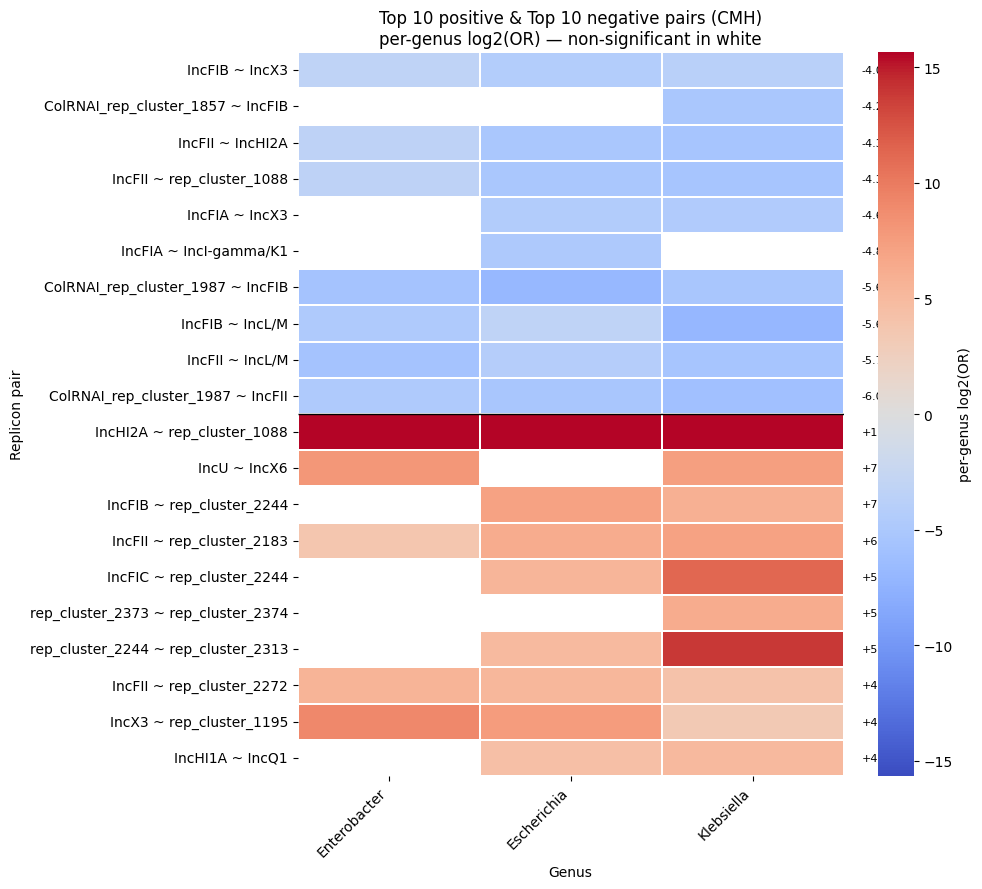

✅ Saved to /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/ESKAPEE_top20_per_genus_sigonly_heatmap.png


In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# ===== Helper =====
def _fisher_or(n11,n10,n01,n00):
    tbl = np.array([[n11,n10],[n01,n00]], dtype=int)
    if (tbl==0).any():
        OR  = ((n11+0.5)*(n00+0.5))/((n10+0.5)*(n01+0.5))
        p   = fisher_exact(tbl, alternative="two-sided")[1]
    else:
        OR, p = fisher_exact(tbl, alternative="two-sided")
    return OR, p


def per_genus_log2OR_sig(X_eskapee, pairs_df):
    """Return long df with per-genus log2(OR) and significance (BH within each pair)."""
    rows = []
    for pid, r in enumerate(pairs_df.itertuples(index=False)):
        A, B = r.A, r.B
        subrows = []
        for g, sub in X_eskapee.groupby("genus_clean"):
            xA = sub[A].astype(bool).values
            xB = sub[B].astype(bool).values
            n11 = int((xA & xB).sum()); n10 = int((xA & ~xB).sum())
            n01 = int((~xA & xB).sum()); n00 = int((~xA & ~xB).sum())
            OR, p = _fisher_or(n11,n10,n01,n00)
            subrows.append((A,B,g,np.log2(OR),p))
        tmp = pd.DataFrame(subrows, columns=["A","B","genus","log2OR","p"])
        tmp["p_adj"] = multipletests(tmp["p"].values, method="fdr_bh")[1]
        tmp["sig"] = tmp["p_adj"] < 0.05
        tmp["pair_label"] = f"{A} ~ {B}"
        rows.append(tmp)
    return pd.concat(rows, ignore_index=True)

# ===== Select pairs =====
cmh_sig = sig_cmh.copy()
pos10 = cmh_sig.sort_values("log2OR_CMH", ascending=False).head(10)
neg10 = cmh_sig.sort_values("log2OR_CMH", ascending=True).head(10)
pairs20 = pd.concat([pos10.assign(group="positive"),
                     neg10.assign(group="negative")], ignore_index=True)
pairs20["pair_label"] = pairs20["A"] + " ~ " + pairs20["B"]

# ===== Compute per-genus effects =====
long = per_genus_log2OR_sig(X_eskapee, pairs20[["A","B"]])

# set non-significant cells to NaN (white in plot)
long.loc[~long["sig"], "log2OR"] = np.nan

# pivot
mat = long.pivot_table(index="pair_label", columns="genus", values="log2OR", aggfunc="mean")

# order rows: positives first, then negatives
pairs20_sorted = pairs20.sort_values(["group","log2OR_CMH"], ascending=[True, False])
row_order = pairs20_sorted["pair_label"].tolist()
mat = mat.reindex(row_order)

# cap color range symmetrically
vmax = np.nanpercentile(np.abs(mat.values.flatten()), 95)
vmax = max(vmax, 1.0)

# ===== Plot =====
plt.figure(figsize=(10, max(5, 0.45*mat.shape[0])))
ax = sns.heatmap(mat, cmap="coolwarm", center=0, vmin=-vmax, vmax=vmax,
                 linewidths=0.3, linecolor="white", cbar_kws=dict(label="per-genus log2(OR)"),
                 mask=mat.isna())

# separator between positive and negative
n_pos = len(pos10)
ax.hlines(n_pos, *ax.get_xlim(), colors="black", linewidth=1)

# label CMH log2OR on right
cmh_map = dict(zip(pairs20["pair_label"], pairs20["log2OR_CMH"]))
for i, lab in enumerate(mat.index):
    ax.text(mat.shape[1] + 0.1, i + 0.5, f"{cmh_map.get(lab, np.nan):+.1f}",
            va="center", ha="left", fontsize=8, transform=ax.transData)

plt.title("Top 10 positive & Top 10 negative pairs (CMH)\nper-genus log2(OR) — non-significant in white")
plt.xlabel("Genus"); plt.ylabel("Replicon pair")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

out_path = FIGS / "ESKAPEE_top20_per_genus_sigonly_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved to {out_path}")


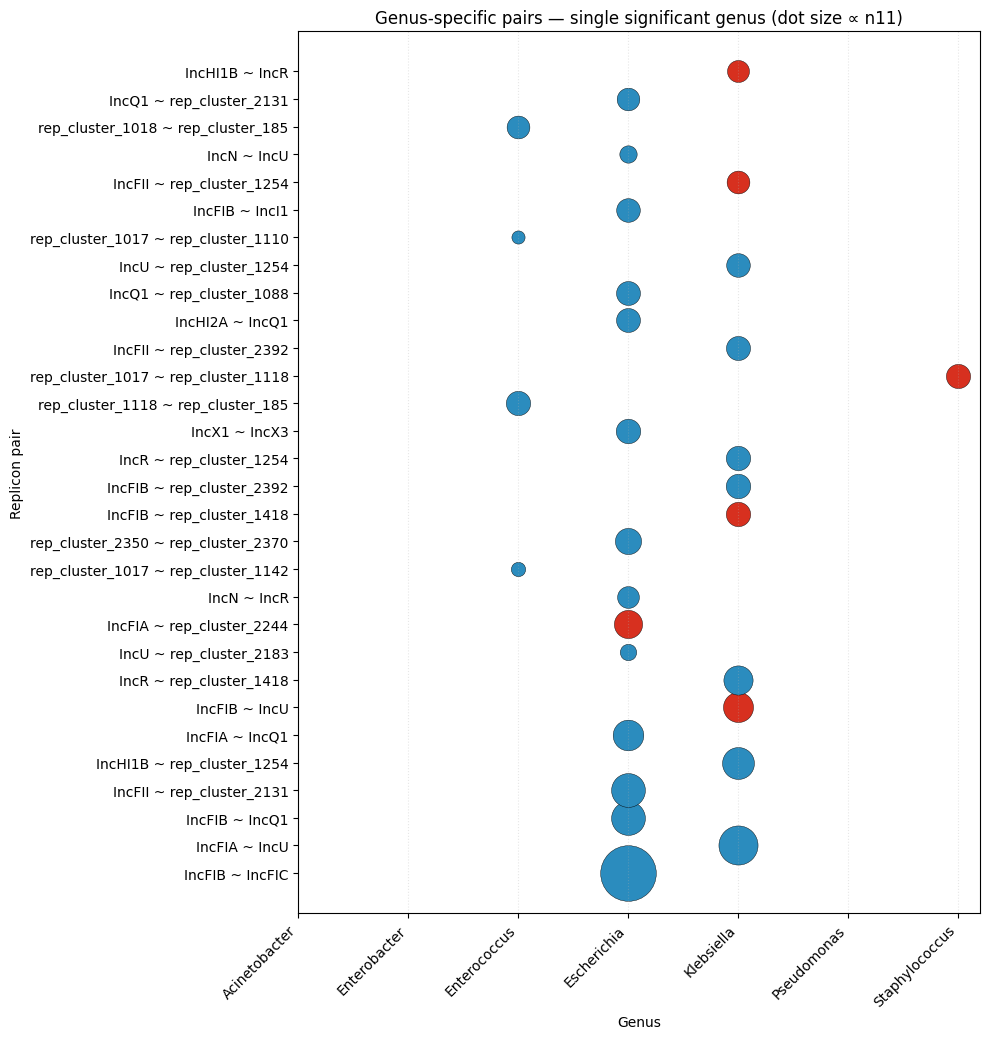

Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/ESKAPEE_genus_specific_pairs_dotmatrix.png


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests

# pick genus-specific pairs
genus_spec = (summary_pairs
              .query("category == 'genus-specific'")
              .sort_values(["per_genus_sig_total","cmh_support"], ascending=[False,False])
              [["A","B"]].drop_duplicates())

if genus_spec.empty:
    print("No 'genus-specific' pairs to plot.")
else:
    topN = 30
    long = per_genus_effects_long(X_eskapee, genus_spec, max_pairs=topN)
    # Within each pair, compute per-genus p-values & BH-correct to find the single significant genus
    dots = []
    for pid, sub in long.groupby("pair_id"):
        # recompute p-values for accuracy
        pvals = []
        for r in sub.itertuples(index=False):
            OR, p = _fisher_or(r.n11,r.n10,r.n01,r.n00)
            pvals.append(p)
        sub = sub.copy()
        sub["p"] = pvals
        sub["p_adj_pair"] = multipletests(sub["p"].values, method="fdr_bh")[1]
        sig = sub[sub["p_adj_pair"] < 0.05].copy()
        if sig.shape[0] == 1:  # exactly one genus
            sig["sign"] = np.where(sig["log2OR"]>0, "pos", "neg")
            dots.append(sig)
    if not dots:
        print("No pairs with exactly one significant genus among the selected.")
    else:
        D = pd.concat(dots, ignore_index=True)
        D["pair_label"] = D["A"] + " ~ " + D["B"]
        # build scatter positions
        genera = sorted(X_eskapee["genus_clean"].unique())
        pair_order = D["pair_label"].unique().tolist()
        color_map = {"pos":"#2b8cbe", "neg":"#d7301f"}

        plt.figure(figsize=(10, max(4, 0.35*len(pair_order))))
        for _, r in D.iterrows():
            x = genera.index(r["genus"]); y = pair_order.index(r["pair_label"])
            plt.scatter(x, y, s=50 + 40*np.sqrt(max(1,r["n11"])), 
                        color=color_map[r["sign"]], edgecolor="black", linewidth=0.3)
        plt.yticks(range(len(pair_order)), pair_order)
        plt.xticks(range(len(genera)), genera, rotation=45, ha="right")
        plt.grid(axis="x", linestyle=":", alpha=0.3)
        plt.title("Genus-specific pairs — single significant genus (dot size ∝ n11)")
        plt.xlabel("Genus"); plt.ylabel("Replicon pair")
        plt.tight_layout()
        out_path = FIGS / "ESKAPEE_genus_specific_pairs_dotmatrix.png"
        plt.savefig(out_path, dpi=300); plt.show()
        print(f"Saved: {out_path}")


,A,B,support_total_n11,per_genus_tested,per_genus_sig_total,per_genus_sig_pos,per_genus_sig_neg,category,OR_CMH,log2OR_CMH,p_CMH,K_strata,cmh_support,FDR_CMH,direction_CMH
0,Col156,IncFIA,7,7,1,0,1,genus-specific,0.067226,-3.894831,0.000000e+00,7,7,0.000000e+00,negative
1,Col156,IncFIB,8,7,2,0,2,consistent,0.080686,-3.631543,0.000000e+00,7,8,0.000000e+00,negative
2,Col156,rep_cluster_2131,10,7,0,0,0,uncertain,0.795500,-0.330066,4.795362e-01,7,10,5.122850e-01,negative
3,ColRNAI_rep_cluster_1857,IncFIA,17,7,1,0,1,genus-specific,0.147868,-2.757615,0.000000e+00,7,17,0.000000e+00,negative
4,ColRNAI_rep_cluster_1857,IncFIB,18,7,1,0,1,genus-specific,0.055122,-4.181222,0.000000e+00,7,18,0.000000e+00,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,rep_cluster_2350,rep_cluster_2370,59,7,1,1,0,genus-specific,12.910706,3.690496,0.000000e+00,7,59,0.000000e+00,positive
215,rep_cluster_2358,rep_cluster_2373,16,7,2,2,0,consistent,5.883114,2.556580,1.100231e-13,7,16,2.458680e-13,positive
216,rep_cluster_2373,rep_cluster_2374,9,7,1,1,0,genus-specific,43.531915,5.444002,0.000000e+00,7,9,0.000000e+00,positive
217,rep_cluster_889,rep_cluster_935,7,7,1,1,0,genus-specific,1.447760,0.533823,3.353633e-01,7,7,3.728150e-01,positive


In [88]:
summary_pairs

,A,B,support_total_n11,per_genus_tested,per_genus_sig_total,per_genus_sig_pos,per_genus_sig_neg,category,OR_CMH,log2OR_CMH,p_CMH,K_strata,cmh_support,FDR_CMH,direction_CMH
0,Col156,IncFIA,7,7,1,0,1,genus-specific,0.067226,-3.894831,0.000000e+00,7,7,0.000000e+00,negative
1,Col156,IncFIB,8,7,2,0,2,consistent,0.080686,-3.631543,0.000000e+00,7,8,0.000000e+00,negative
2,Col156,rep_cluster_2131,10,7,0,0,0,uncertain,0.795500,-0.330066,4.795362e-01,7,10,5.122850e-01,negative
3,ColRNAI_rep_cluster_1857,IncFIA,17,7,1,0,1,genus-specific,0.147868,-2.757615,0.000000e+00,7,17,0.000000e+00,negative
4,ColRNAI_rep_cluster_1857,IncFIB,18,7,1,0,1,genus-specific,0.055122,-4.181222,0.000000e+00,7,18,0.000000e+00,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,rep_cluster_2350,rep_cluster_2370,59,7,1,1,0,genus-specific,12.910706,3.690496,0.000000e+00,7,59,0.000000e+00,positive
215,rep_cluster_2358,rep_cluster_2373,16,7,2,2,0,consistent,5.883114,2.556580,1.100231e-13,7,16,2.458680e-13,positive
216,rep_cluster_2373,rep_cluster_2374,9,7,1,1,0,genus-specific,43.531915,5.444002,0.000000e+00,7,9,0.000000e+00,positive
217,rep_cluster_889,rep_cluster_935,7,7,1,1,0,genus-specific,1.447760,0.533823,3.353633e-01,7,7,3.728150e-01,positive


In [85]:
long

,pair_id,A,B,genus,n11,n10,n01,n00,log2OR
0,0,IncFIB,IncFIC,Acinetobacter,0,0,1,2539,10.725366
1,0,IncFIB,IncFIC,Enterobacter,4,348,15,1930,0.564551
2,0,IncFIB,IncFIC,Enterococcus,0,0,0,3221,12.653517
3,0,IncFIB,IncFIC,Escherichia,1507,1849,749,10682,3.539006
4,0,IncFIB,IncFIC,Klebsiella,36,3404,87,8674,0.076448
...,...,...,...,...,...,...,...,...,...
205,29,IncHI1B,IncR,Enterococcus,0,0,0,3221,12.653517
206,29,IncHI1B,IncR,Escherichia,1,433,122,14231,-1.892211
207,29,IncHI1B,IncR,Klebsiella,25,808,1233,10135,-1.975254
208,29,IncHI1B,IncR,Pseudomonas,0,0,2,983,8.619853


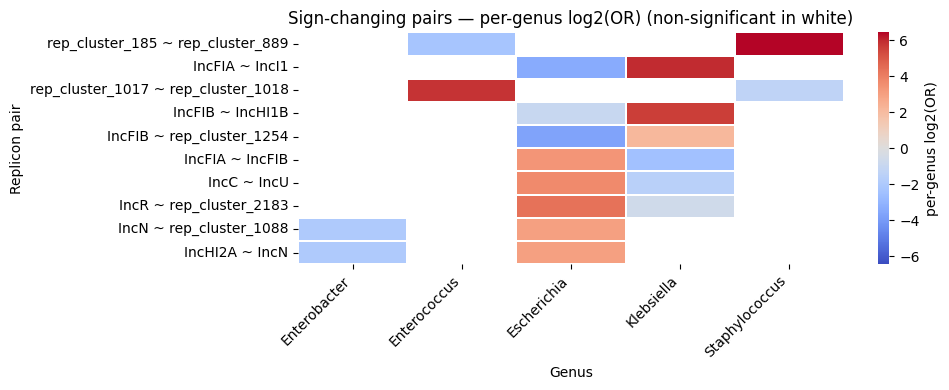

✅ Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/ESKAPEE_sign_changing_pairs_sigonly_heatmap.png


In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# --- helper: HA-corrected OR + p
def _fisher_or(n11,n10,n01,n00):
    tbl = np.array([[n11,n10],[n01,n00]], dtype=int)
    if (tbl==0).any():
        OR  = ((n11+0.5)*(n00+0.5))/((n10+0.5)*(n01+0.5))
        p   = fisher_exact(tbl, alternative="two-sided")[1]
    else:
        OR, p = fisher_exact(tbl, alternative="two-sided")
    return OR, p

# --- select sign-changing pairs
sign_changing = (summary_pairs
                 .query("category == 'sign-changing'")
                 .sort_values(["per_genus_sig_total","cmh_support"], ascending=[False,False])
                 [["A","B"]].drop_duplicates())

if sign_changing.empty:
    print("No 'sign-changing' pairs to plot.")
else:
    topN = 25
    pairs = sign_changing.head(topN).copy()
    rows = []
    for r in pairs.itertuples(index=False):
        A, B = r.A, r.B
        subrows = []
        for g, sub in X_eskapee.groupby("genus_clean"):
            xA = sub[A].astype(bool).values
            xB = sub[B].astype(bool).values
            n11 = int((xA & xB).sum()); n10 = int((xA & ~xB).sum())
            n01 = int((~xA & xB).sum()); n00 = int((~xA & ~xB).sum())
            OR, p = _fisher_or(n11,n10,n01,n00)
            subrows.append((A, B, g, n11, n10, n01, n00, np.log2(OR), p))
        tmp = pd.DataFrame(subrows, columns=["A","B","genus","n11","n10","n01","n00","log2OR","p"])
        # BH within this pair (across genera)
        tmp["p_adj"] = multipletests(tmp["p"].values, method="fdr_bh")[1]
        tmp["sig"] = tmp["p_adj"] < 0.05
        tmp["pair_label"] = f"{A} ~ {B}"
        rows.append(tmp)

    long = pd.concat(rows, ignore_index=True)

    # only informative tables
    long = long[(long[["n11","n10","n01","n00"]].sum(axis=1) > 0)].copy()
    # non-significant → NaN (white)
    long.loc[~long["sig"], "log2OR"] = np.nan

    # pivot to matrix
    long["pair_label"] = long["A"] + " ~ " + long["B"]
    mat = long.pivot_table(index="pair_label", columns="genus", values="log2OR", aggfunc="mean")

    # order rows by within-row variance (largest flips first)
    rowvar = mat.var(axis=1, skipna=True).sort_values(ascending=False)
    mat = mat.reindex(rowvar.index)

    # symmetric color limits, cap at 95th perc of |log2OR|
    vmax = np.nanpercentile(np.abs(mat.values.flatten()), 95)
    vmax = max(vmax, 1.0)

    plt.figure(figsize=(10, max(4, 0.35*mat.shape[0])))
    sns.heatmap(mat, cmap="coolwarm", center=0, vmin=-vmax, vmax=vmax,
                linewidths=0.3, linecolor="white",
                cbar_kws=dict(label="per-genus log2(OR)"),
                mask=mat.isna())
    plt.title("Sign-changing pairs — per-genus log2(OR) (non-significant in white)")
    plt.xlabel("Genus"); plt.ylabel("Replicon pair")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()

    out_path = FIGS / "ESKAPEE_sign_changing_pairs_sigonly_heatmap.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight"); plt.show()
    print(f"✅ Saved: {out_path}")


In [96]:
# ================================================================
# Fix "tested" per genus using proper informativity (variable margins)
# Reuse existing X_eskapee and candidates_eskapee
# Build positive-only networks again with correct per-genus BH
# ================================================================
import numpy as np, pandas as pd, networkx as nx
from pathlib import Path
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from pyvis.network import Network

BASE  = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
RES   = BASE / "results"
NETS  = RES / "networks"; NETS.mkdir(parents=True, exist_ok=True)

ALPHA_GENUS = 0.05
MIN_SUPPORT = 3         # raise to 5/10 if you want
MIN_LOG2OR  = 0.0       # require >0; set 0.5/1.0 for stronger edges

assert "X_eskapee" in globals()
assert "candidates_eskapee" in globals()

def _or_p(a,b,c,d):
    tbl = np.array([[a,b],[c,d]], dtype=int)
    # Only compute OR if margins are valid; otherwise return NaNs (will be filtered out)
    # Haldane–Anscombe for OR when zeros exist, but only if informative
    if (a+b)==0 or (c+d)==0 or (a+c)==0 or (b+d)==0:
        return np.nan, np.nan
    if (tbl==0).any():
        OR  = ((a+0.5)*(d+0.5))/((b+0.5)*(c+0.5))
        p   = fisher_exact(tbl, alternative="two-sided")[1]
    else:
        OR, p = fisher_exact(tbl, alternative="two-sided")
    return float(OR), float(p)

# ---------- rebuild long_all with proper "informative" ----------
rows = []
pair_id = 0
for r in candidates_eskapee.itertuples(index=False):
    A, B = r.A, r.B
    for g, sub in X_eskapee.groupby("genus_clean"):
        xA = sub[A].astype(bool).values
        xB = sub[B].astype(bool).values
        a = int((xA & xB).sum())
        b = int((xA & ~xB).sum())
        c = int((~xA & xB).sum())
        d = int((~xA & ~xB).sum())
        # margins for informativity
        ab = a + b
        cd = c + d
        ac = a + c
        bd = b + d
        informative = (ab>0) and (cd>0) and (ac>0) and (bd>0)
        if not informative:
            continue
        OR, p = _or_p(a,b,c,d)
        if np.isnan(OR):
            continue
        rows.append((pair_id, A, B, g, a, b, c, d, float(np.log2(OR)), p))
    pair_id += 1

long_all = pd.DataFrame(rows, columns=["pair_id","A","B","genus","n11","n10","n01","n00","log2OR","p"])
print(f"[info] informative per-genus rows: {len(long_all):,}  | pairs represented: {long_all['pair_id'].nunique():,}")

# ---------- BH within each genus over informative rows ----------
long_all["FDR_genus"] = np.nan
for g, idx in long_all.groupby("genus").groups.items():
    long_all.loc[idx, "FDR_genus"] = multipletests(long_all.loc[idx, "p"].values, method="fdr_bh")[1]

# ---------- Positive significant edges ----------
edges_pos = long_all[
    (long_all["log2OR"] > MIN_LOG2OR) &
    (long_all["FDR_genus"] < ALPHA_GENUS) &
    (long_all["n11"] >= MIN_SUPPORT)
].copy()

# ---------- Proper summary: tested = #unique informative pairs in that genus ----------
tested = long_all.groupby("genus")["pair_id"].nunique().rename("tested")
signif = edges_pos.groupby("genus")["pair_id"].nunique().rename("significant")
summary_genus = (pd.concat([tested, signif], axis=1)
                   .fillna(0).astype(int)
                   .sort_values("significant", ascending=False))
summary_path = NETS / "ESKAPEE_pos_cointegration_per_genus_summary_FIXED.tsv"
summary_genus.to_csv(summary_path, sep="\t", index=True)
print("Per-genus summary saved →", summary_path)
display(summary_genus)

# ---------- Node sizes from per-genus prevalence ----------
def detect_replicon_columns(dfX):
    cands = [c for c in dfX.columns if str(c).startswith(("Inc","Col","rep_cluster_","rep_"))]
    out = []
    for c in cands:
        vals = pd.to_numeric(dfX[c], errors="coerce").dropna().astype(int)
        if len(vals) and set(vals.unique()).issubset({0,1}):
            out.append(c)
    return sorted(out)

rep_cols = detect_replicon_columns(X_eskapee)

def edge_width_from_log2or(x):
    return float(0.8 + min(6.0, abs(x)))

def build_pyvis_positive_for_genus(genus):
    sub_meta = X_eskapee[X_eskapee["genus_clean"] == genus]
    e = edges_pos[edges_pos["genus"] == genus]
    if e.empty:
        print(f"[{genus}] No positive significant edges.")
        return

    prev = sub_meta[rep_cols].sum().astype(int) if rep_cols else pd.Series(dtype=int)
    # Graph
    G = nx.Graph(genus=genus, n_plasmids=len(sub_meta))
    for u in set(e["A"]).union(e["B"]):
        G.add_node(u, prevalence=int(prev.get(u, 0)))
    for r in e.itertuples(index=False):
        G.add_edge(r.A, r.B,
                   log2OR=float(r.log2OR),
                   support=int(r.n11),
                   FDR=float(r.FDR_genus),
                   weight=float(r.log2OR))

    # Interactive PyVis
    net = Network(height="800px", width="100%", bgcolor="#ffffff", font_color="#111111", notebook=False)
    net.set_options("""
    {
      "nodes": {"shape": "dot"},
      "physics": {
        "enabled": true,
        "solver": "forceAtlas2Based",
        "forceAtlas2Based": {
          "gravitationalConstant": -150,
          "centralGravity": 0.01,
          "springLength": 180,
          "springConstant": 0.02,
          "damping": 0.6
        },
        "stabilization": {"enabled": true, "iterations": 250}
      },
      "interaction": {"hover": true, "tooltipDelay": 100}
    }
    """)
    for u, attrs in G.nodes(data=True):
        prev_u = int(attrs.get("prevalence", 0))
        size = 8 + (prev_u ** 0.5)
        net.add_node(u, label=u, value=prev_u, size=size,
                     color="#6aa84f",
                     title=f"<b>{u}</b><br>Prevalence (in {genus}) = {prev_u}")
    for u, v, d in G.edges(data=True):
        lw = edge_width_from_log2or(d["log2OR"])
        net.add_edge(u, v, color="#0078FF", width=lw,
                     title=(f"<b>{u}</b> — <b>{v}</b><br>"
                            f"log₂(OR) = {d['log2OR']:.2f}<br>"
                            f"support n11 = {d['support']}<br>"
                            f"FDR (within genus) = {d['FDR']:.3g}"))
    html_p = NETS / f"ESKAPEE_{genus}_positive_network_FIXED.html"
    net.write_html(str(html_p))
    print(f"[{genus}] HTML saved → {html_p}")

# Plot only genera with significant edges
genera_to_plot = summary_genus.query("significant > 0").index.tolist()
print(f"[info] Genera to plot (positive-only): {genera_to_plot}")
for g in genera_to_plot:
    build_pyvis_positive_for_genus(g)


[info] informative per-genus rows: 706  | pairs represented: 301
Per-genus summary saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/networks/ESKAPEE_pos_cointegration_per_genus_summary_FIXED.tsv


,tested,significant
genus,,
Escherichia,201,75
Klebsiella,196,54
Staphylococcus,71,31
Enterobacter,166,18
Enterococcus,40,14
Pseudomonas,26,3
Acinetobacter,6,1


[info] Genera to plot (positive-only): ['Escherichia', 'Klebsiella', 'Staphylococcus', 'Enterobacter', 'Enterococcus', 'Pseudomonas', 'Acinetobacter']
[Escherichia] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/networks/ESKAPEE_Escherichia_positive_network_FIXED.html
[Klebsiella] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/networks/ESKAPEE_Klebsiella_positive_network_FIXED.html
[Staphylococcus] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/networks/ESKAPEE_Staphylococcus_positive_network_FIXED.html
[Enterobacter] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/networks/ESKAPEE_Enterobacter_positive_network_FIXED.html
[Enterococcus] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/networks/ESKAPEE_Enterococcus_positive_network_FIXED.html
[Pseudomonas] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/networks/ESKAPEE_Pseudomonas_positive_network_FIXED.html
[Acinetobacter] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/networks/ESKAP

In [119]:
# ================================================================
# Visualization update: fixed layout — edge length strictly ∝ |log₂OR|
# Larger OR => longer visible edge, independent of physics
# Node size = degree, edge width = |log₂OR|
# ================================================================
import numpy as np, pandas as pd, networkx as nx
from pathlib import Path
from pyvis.network import Network

BASE  = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
RES   = BASE / "results"
NEWVIS = RES / "newvis_networks"
NEWVIS.mkdir(parents=True, exist_ok=True)

# ------------------ Visualization scaling parameters ------------------

MIN_W, MAX_W   = 1.5, 8.0          # edge width
MIN_L, MAX_L   = 100, 450          # edge length (visible)
MIN_SZ, MAX_SZ = 10, 42            # node size
DEG_POW        = 0.7               # degree compression for hub nodes

def _minmax_scale(x, xmin, xmax, out_min, out_max):
    if xmax <= xmin:
        return (out_min + out_max) / 2.0
    t = (x - xmin) / (xmax - xmin)
    t = float(np.clip(t, 0, 1))
    return out_min + t * (out_max - out_min)

def edge_width_from_log2or(log2or, mn=None, mx=None):
    v = abs(float(log2or))
    if mn is None or mx is None:
        return _minmax_scale(v, 0.0, max(1.0, v), MIN_W, MAX_W)
    else:
        return _minmax_scale(v, mn, mx, MIN_W, MAX_W)

def edge_length_from_log2or(log2or, mn=None, mx=None):
    v = abs(float(log2or))
    if mn is None or mx is None:
        return _minmax_scale(v, 0.0, max(1.0, v), MIN_L, MAX_L)
    else:
        return _minmax_scale(v, mn, mx, MIN_L, MAX_L)

def node_size_from_degree(deg, deg_min, deg_max):
    d = float(deg) ** DEG_POW
    dmin = float(deg_min) ** DEG_POW
    dmax = float(max(deg_max, deg_min + 1)) ** DEG_POW
    return _minmax_scale(d, dmin, dmax, MIN_SZ, MAX_SZ)

# ================================================================
# Build interactive positive network per genus (degree & OR scaling)
# ================================================================

def build_pyvis_positive_for_genus(genus):
    sub_meta = X_eskapee[X_eskapee["genus_clean"] == genus]
    e = edges_pos[edges_pos["genus"] == genus]
    if e.empty:
        print(f"[{genus}] No positive significant edges.")
        return

    prev = sub_meta[rep_cols].sum().astype(int) if rep_cols else pd.Series(dtype=int)

    # Graph
    G = nx.Graph(genus=genus, n_plasmids=len(sub_meta))
    for u in set(e["A"]).union(e["B"]):
        G.add_node(u, prevalence=int(prev.get(u, 0)))
    for r in e.itertuples(index=False):
        G.add_edge(r.A, r.B,
                   log2OR=float(r.log2OR),
                   support=int(r.n11),
                   FDR=float(r.FDR_genus))

    # Scaling
    deg_dict = dict(G.degree())
    if len(deg_dict) == 0:
        print(f"[{genus}] (no edges to draw)")
        return
    deg_min, deg_max = min(deg_dict.values()), max(deg_dict.values())
    abs_l2 = np.abs([d["log2OR"] for *_u,_v,d in G.edges(data=True)])
    or_min, or_max = float(np.min(abs_l2)), float(np.max(abs_l2))

    # Initialize PyVis (no physics for fixed geometric proportionality)
    net = Network(height="860px", width="100%", bgcolor="#ffffff", font_color="#111111", notebook=False)
    net.barnes_hut(gravity=-20000, central_gravity=0.0, spring_length=0, spring_strength=0, damping=0.9)
    net.toggle_physics(False)  # disable physics so edge length stays proportional

    # Nodes
    for u, attrs in G.nodes(data=True):
        deg_u   = deg_dict.get(u, 0)
        size_u  = node_size_from_degree(deg_u, deg_min, deg_max)
        prev_u  = int(attrs.get("prevalence", 0))
        net.add_node(
            u,
            label=u,
            value=deg_u,
            size=float(size_u),
            color="#6aa84f",
            title=(f"<b>{u}</b><br>"
                   f"Degree (signif. edges) = {deg_u}<br>"
                   f"Prevalence in <i>{genus}</i> = {prev_u}")
        )

    # Edges — strictly proportional to |log₂OR|
    for u, v, d in G.edges(data=True):
        l2 = float(d["log2OR"])
        lw = edge_width_from_log2or(l2, or_min, or_max)
        ln = edge_length_from_log2or(l2, or_min, or_max)
        net.add_edge(
            u, v,
            color="#0078FF",
            width=float(lw),
            length=float(ln),
            title=(f"<b>{u}</b> — <b>{v}</b><br>"
                   f"log₂(OR) = {l2:.2f}<br>"
                   f"support n11 = {int(d['support'])}<br>"
                   f"FDR (within genus) = {float(d['FDR']):.3g}")
        )

    # Save
    html_p = NEWVIS / f"ESKAPEE_{genus}_positive_network_newvis_FIXEDLENGTH.html"
    net.write_html(str(html_p))
    print(f"[{genus}] HTML saved → {html_p}")

# ================================================================
# Run for all genera with significant positive edges
# ================================================================
genera_to_plot = summary_genus.query("significant > 0").index.tolist()
print(f"[info] Genera to plot (positive-only): {genera_to_plot}")
for g in genera_to_plot:
    build_pyvis_positive_for_genus(g)


[info] Genera to plot (positive-only): ['Escherichia', 'Klebsiella', 'Staphylococcus', 'Enterobacter', 'Enterococcus', 'Pseudomonas', 'Acinetobacter']
[Escherichia] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/newvis_networks/ESKAPEE_Escherichia_positive_network_newvis_FIXEDLENGTH.html
[Klebsiella] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/newvis_networks/ESKAPEE_Klebsiella_positive_network_newvis_FIXEDLENGTH.html
[Staphylococcus] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/newvis_networks/ESKAPEE_Staphylococcus_positive_network_newvis_FIXEDLENGTH.html
[Enterobacter] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/newvis_networks/ESKAPEE_Enterobacter_positive_network_newvis_FIXEDLENGTH.html
[Enterococcus] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/newvis_networks/ESKAPEE_Enterococcus_positive_network_newvis_FIXEDLENGTH.html
[Pseudomonas] HTML saved → /home/nacho/HDD16/Nacho/RepliCOOC/results/newvis_networks/ESKAPEE_Pseudomonas_positi

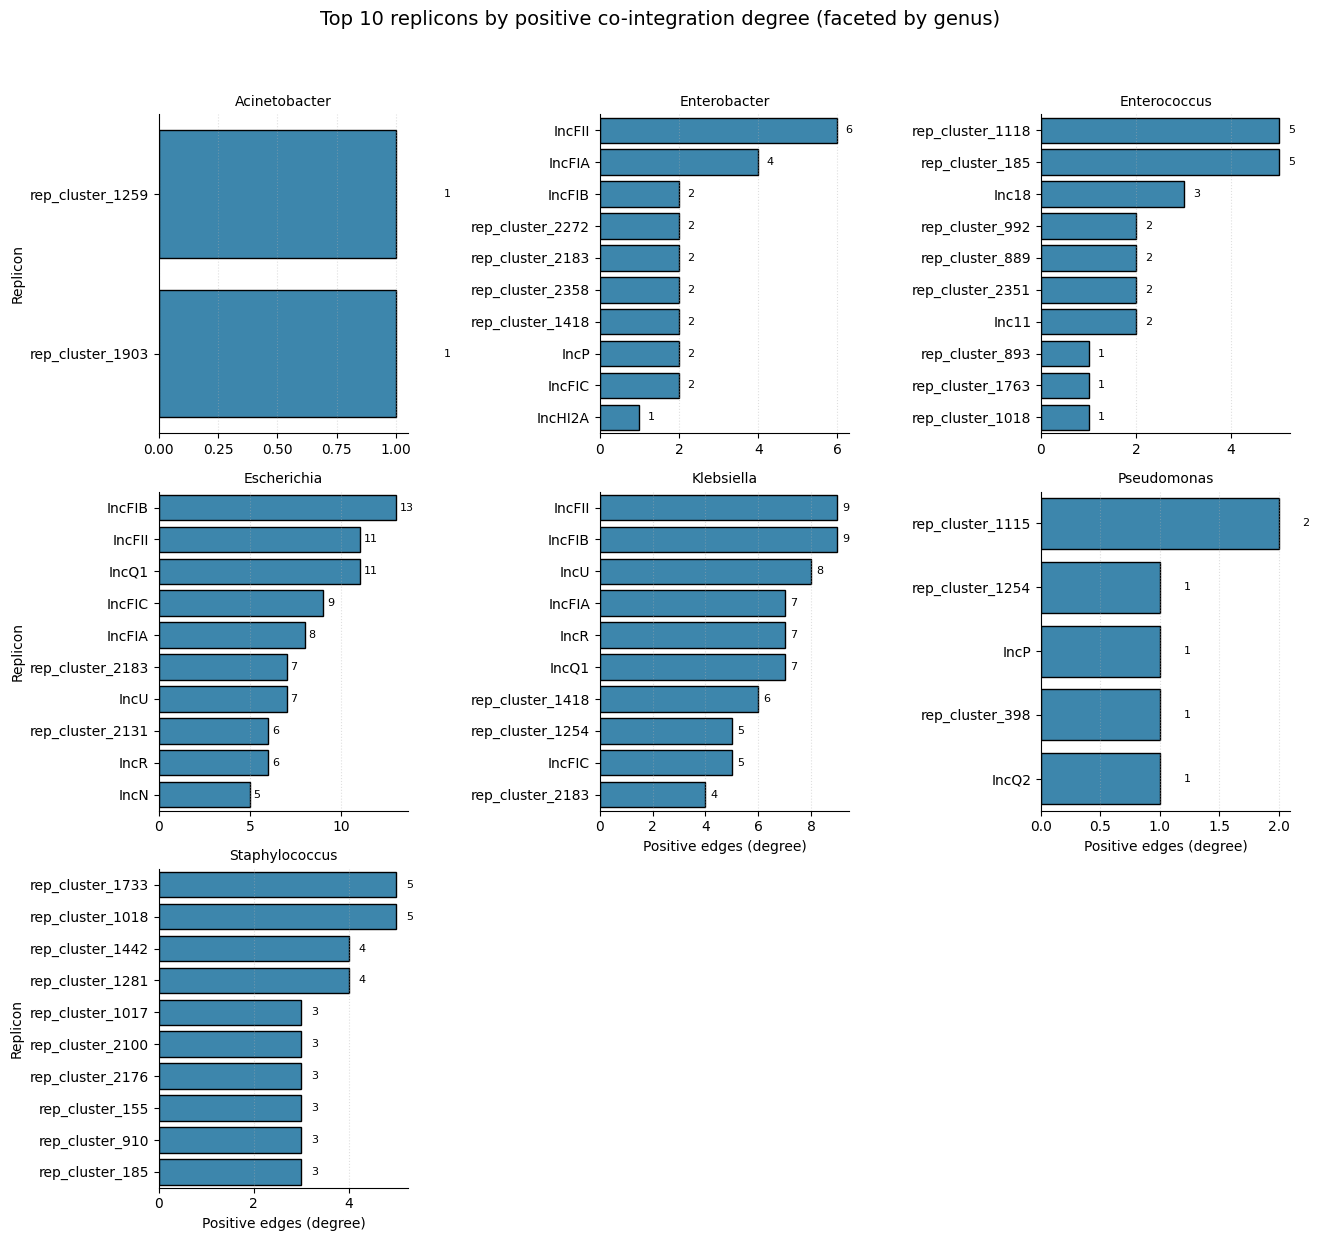

✅ Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/ESKAPEE_top10_replicons_by_positive_degree_facet.png
✅ Table saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/ESKAPEE_top10_replicons_by_positive_degree_per_genus.tsv


In [97]:
# ============================================================
# Top-10 replicons by number of positive edges (degree), facet by genus
# Reuses: edges_pos (columns: A, B, genus, n11, log2OR, FDR_genus …)
# Outputs: PNG figure
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---- sanity checks
assert "edges_pos" in globals(), "`edges_pos` not found. Run the positive-edge step first."

BASE  = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
RES   = BASE / "results"
FIGS  = RES / "figures"; FIGS.mkdir(parents=True, exist_ok=True)

# ---- compute per-genus node degrees (and optional support sum)
def top_nodes_by_degree_per_genus(edges_df, top_k=10):
    out = []
    for g, e in edges_df.groupby("genus"):
        # long format of endpoints
        long_nodes = pd.concat([
            e[["A","n11"]].rename(columns={"A":"node"}),
            e[["B","n11"]].rename(columns={"B":"node"})
        ], ignore_index=True)

        # degree = number of incident positive edges
        # support_sum = sum of n11 across incident edges (optional tie-breaker)
        stat = (long_nodes
                .groupby("node")
                .agg(degree=("n11","size"),
                     support_sum=("n11","sum"))
                .reset_index()
                .sort_values(["degree","support_sum","node"], ascending=[False, False, True])
                .head(top_k)
                .copy())
        stat["genus"] = g
        out.append(stat)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame(columns=["node","degree","support_sum","genus"])

top10_nodes = top_nodes_by_degree_per_genus(edges_pos, top_k=10)

if top10_nodes.empty:
    print("No positive edges to summarize.")
else:
    # per-facet ordering: make 'node' categorical ordered **within each genus**
    ordered = []
    for g, sub in top10_nodes.groupby("genus", sort=False):
        # order for this genus only
        order_nodes = sub.sort_values(["degree","support_sum","node"], ascending=[False, False, True])["node"].tolist()
        s = sub.copy()
        s["node"] = pd.Categorical(s["node"], categories=order_nodes, ordered=True)
        ordered.append(s)
    top10_nodes_ord = pd.concat(ordered, ignore_index=True)

    # facet barplot
    g = sns.catplot(
        data=top10_nodes_ord,
        kind="bar",
        x="degree", y="node",
        col="genus", col_wrap=3,
        sharex=False, sharey=False,
        height=4, aspect=1.1,
        color="#2b8cbe", edgecolor="black"
    )
    g.set_axis_labels("Positive edges (degree)", "Replicon")
    g.set_titles("{col_name}")
    for ax, (genus, sub) in zip(g.axes.flatten(), top10_nodes_ord.groupby("genus", sort=False)):
        ax.grid(axis="x", linestyle=":", alpha=0.4)
        # Annotate bars with degree (and optionally support sum)
        for p in ax.patches:
            val = int(p.get_width())
            ax.text(p.get_x() + p.get_width() + 0.2,
                    p.get_y() + p.get_height()/2,
                    f"{val}",
                    va="center", ha="left", fontsize=8)

    plt.suptitle("Top 10 replicons by positive co-integration degree (faceted by genus)", y=1.03, fontsize=14)
    plt.tight_layout()

    out_png = FIGS / "ESKAPEE_top10_replicons_by_positive_degree_facet.png"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out_png}")

    # optional: also dump the table
    tbl_path = RES / "stats" / "ESKAPEE_top10_replicons_by_positive_degree_per_genus.tsv"
    tbl_path.parent.mkdir(parents=True, exist_ok=True)
    # pretty order within each genus
    (top10_nodes
     .sort_values(["genus","degree","support_sum","node"], ascending=[True, False, False, True])
     .to_csv(tbl_path, sep="\t", index=False))
    print(f"✅ Table saved: {tbl_path}")


[done] copy-aware K=2: 108 tests → /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/eskapee_length_additivity_by_genus_copyaware_K2_median.tsv
[done] copy-aware K=3: 47 tests → /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/eskapee_length_additivity_by_genus_copyaware_K3_median.tsv
[done] copy-aware K=4: 19 tests → /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/eskapee_length_additivity_by_genus_copyaware_K4_median.tsv
[done] Combined table → /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/eskapee_length_additivity_by_genus_copyaware_allK_median.tsv


,K,genus,combo,combo_label,n_multi,median_multi,mad_multi,pred_median,obs_median,diff,ratio,z,p,FDR
0,2,Acinetobacter,"((rep_cluster_1218, 1), (rep_cluster_639, 1))",rc1218+rc639,6,198640.5,15779.3118,202608.0,198640.5,-3967.5,0.980418,-0.541852,5.879204e-01,6.105327e-01
1,2,Enterobacter,"((ColRNAI_rep_cluster_1987, 1), (rep_cluster_2...",ColRNAI_rc1987+rc2358,7,4760.0,2189.8002,8719.0,4760.0,-3959.0,0.545934,-3.666909,2.454998e-04,3.682497e-04
2,2,Enterobacter,"((IncFIB, 1), (IncFII, 1))",IncFIB+IncFII,112,131739.5,50749.3980,199743.5,131739.5,-68004.0,0.659543,-3.899585,9.635782e-05,1.486664e-04
3,2,Enterobacter,"((IncFIB, 1), (IncR, 1))",IncFIB+IncR,6,117384.5,34749.1788,166098.0,117384.5,-48713.5,0.706718,-3.342631,8.298813e-04,1.163989e-03
4,2,Enterobacter,"((IncFII, 1), (IncR, 1))",IncFII+IncR,17,101548.0,26996.6634,140849.5,101548.0,-39301.5,0.720968,-2.149109,3.162578e-02,3.795094e-02
5,2,Enterobacter,"((IncFII, 1), (rep_cluster_2183, 1))",IncFII+rc2183,25,92286.0,31233.9342,174540.5,92286.0,-82254.5,0.528737,-4.190169,2.787469e-05,4.493233e-05
6,2,Enterobacter,"((IncFII, 1), (rep_cluster_2268, 1))",IncFII+rc2268,9,125786.0,32632.0260,185152.5,125786.0,-59366.5,0.679364,-2.915630,3.549717e-03,4.732956e-03
7,2,Enterobacter,"((IncFII, 2),)",IncFIIx2,11,83357.0,23571.8574,174495.0,83357.0,-91138.0,0.477704,-2.660368,7.805529e-03,9.917613e-03
8,2,Enterobacter,"((rep_cluster_2335, 1), (rep_cluster_2358, 1))",rc2335+rc2358,30,2495.5,1.4826,8027.0,2495.5,-5531.5,0.310888,-7.915077,2.442491e-15,5.612532e-15
9,2,Enterobacter,"((rep_cluster_2358, 1), (rep_cluster_2373, 1))",rc2358+rc2373,8,2496.0,0.7413,8299.0,2496.0,-5803.0,0.300759,-7.602355,2.908784e-14,6.282974e-14


[plot] K=2: 90/108 significant (FDR<0.05)


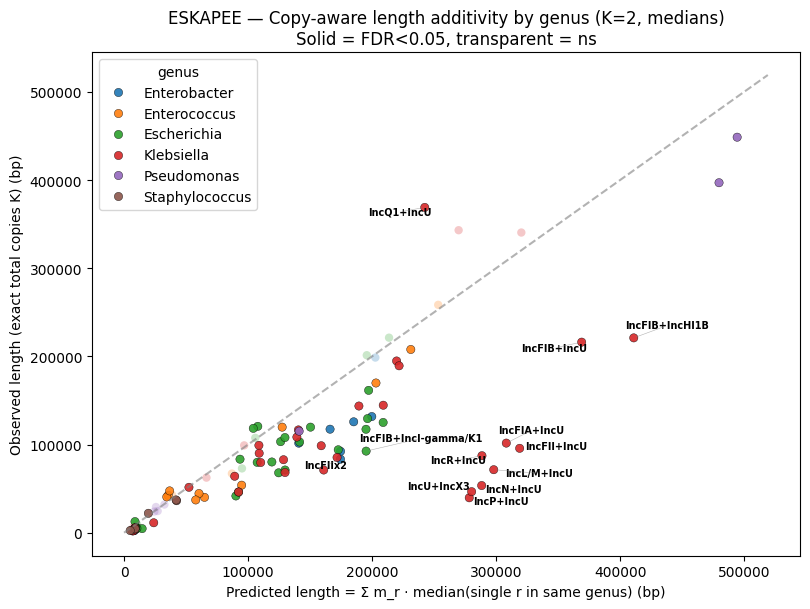

[plot] Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/ESKAPEE_length_additivity_copyaware_scatter_K2_sigalpha.png
[plot] K=3: 44/47 significant (FDR<0.05)


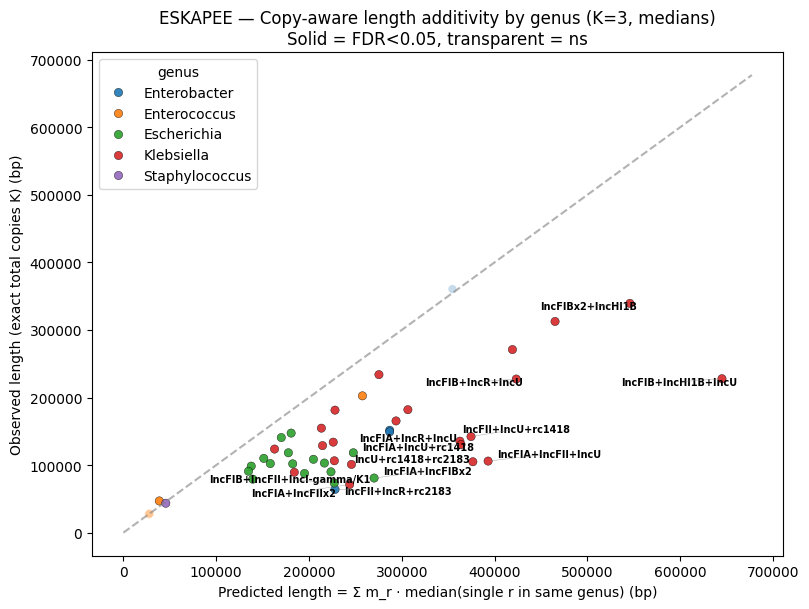

[plot] Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/ESKAPEE_length_additivity_copyaware_scatter_K3_sigalpha.png
[plot] K=4: 19/19 significant (FDR<0.05)


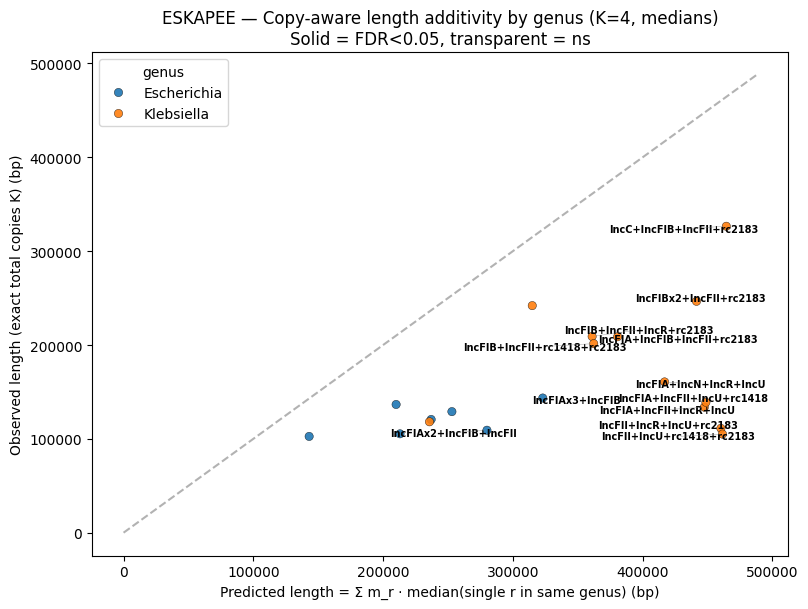

[plot] Saved: /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/ESKAPEE_length_additivity_copyaware_scatter_K4_sigalpha.png


In [100]:
# ============================================
# Copy-aware length additivity (ESKAPEE, stratified by genus)
# EXACT total copies K in {2,3,4}; robust stats (median + MAD)
# Predicted (per-genus) = sum(m_r * median_single_r_in_that_genus)
# Var(pred) (per-genus) = sum(m_r^2 * MAD_r^2 / n_single_r_in_that_genus)
# ============================================
import re
import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm

# ---- Config
BASE  = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
RES   = BASE / "results"
FIGS  = RES / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
STATS = RES / "stats";   STATS.mkdir(parents=True, exist_ok=True)

K_LIST          = [2, 3, 4]   # exact total copy counts
MIN_N_SINGLE    = 10          # per (genus, replicon) singles
MIN_N_MULTI     = 5           # per (genus, multiset) multi

# ---- Helpers
def clean_genus_name(g):
    g = re.sub(r"\s*\([^)]*\)\s*$", "", str(g or "")).strip()
    g = re.sub(r"\s+", " ", g)
    return g

def split_tokens_all(x: str):
    return [t.strip() for t in str(x or "").split(",") if t.strip()]

def mad(x):
    return 1.4826 * np.median(np.abs(x - np.median(x))) if len(x) > 0 else np.nan

def detect_replicon_columns_from_X(X_df):
    # limita al universo de replicones ya presente en X_eskapee
    return sorted([c for c in X_df.columns if str(c).startswith(("Inc","Col","rep_cluster_","rep_"))])

def build_copy_counts_from_mob(mob_df, universe=None):
    """Devuelve:
       - copy_mat: DataFrame (index=plasmid_id, columns=replicon, int copies)
       - has_dup:  Series bool por plasmid_id si alguna copia>1
       Si 'universe' no es None, limita columnas a ese conjunto de replicones.
    """
    rows = []
    for pid, txt in zip(mob_df["plasmid_id"], mob_df["rep_type"]):
        toks = split_tokens_all(txt)
        for t in toks:
            rows.append((pid, t))
    if not rows:
        return (pd.DataFrame(index=mob_df["plasmid_id"].unique()), pd.Series(False, index=[]))
    long = pd.DataFrame(rows, columns=["plasmid_id","replicon"])
    cnt = (long.groupby(["plasmid_id","replicon"]).size()
                .rename("copies").reset_index())
    copy_mat = cnt.pivot(index="plasmid_id", columns="replicon", values="copies").fillna(0).astype(int)
    if universe is not None:
        for c in universe:
            if c not in copy_mat.columns:
                copy_mat[c] = 0
        copy_mat = copy_mat[sorted(universe)]
    has_dup = (copy_mat.max(axis=1) > 1)
    return copy_mat, has_dup

def ensure_lengths_merged(X_like, summ):
    # asegura longitudes y 'genus_clean' limpios
    id_col_summ = "plasmid_id" if "plasmid_id" in summ.columns else \
                  ("NUCCORE_ACC" if "NUCCORE_ACC" in summ.columns else None)
    assert id_col_summ is not None, "No encuentro columna de ID en `summ`."
    len_df = summ[[id_col_summ, "Length"]].rename(columns={id_col_summ:"plasmid_id"}).copy()
    len_df["Length"] = pd.to_numeric(len_df["Length"], errors="coerce")
    XE = X_like.merge(len_df, on="plasmid_id", how="left")
    XE = XE[XE["Length"].notna() & (XE["Length"] > 0)].copy()
    XE["genus_clean"] = XE["genus_clean"].map(clean_genus_name)
    return XE

# ====== REEMPLAZOS CLAVE: cálculo 100% por-género ======
def singles_summary_copyaware(XE, copy_mat):
    """
    Singles = total_copies == 1, contados *dentro de cada género*.
    Devuelve mediana y MAD por (genus, replicon) usando solo plásmidos de ese género.
    """
    out = []
    for g, subX in XE.groupby("genus_clean"):
        pids_g = subX["plasmid_id"].unique()
        subC = copy_mat.reindex(pids_g).fillna(0).astype(int)
        if subC.empty:
            continue
        total_copies_g = subC.sum(axis=1)
        singles_pid = total_copies_g[total_copies_g == 1].index
        if len(singles_pid) == 0:
            continue

        subC1 = subC.loc[singles_pid]
        idx_max = subC1.values.argmax(axis=1)          # replicón activo (exactamente uno)
        reps = np.array(subC1.columns, dtype=object)[idx_max]

        sub_lengths = subX.set_index("plasmid_id").loc[singles_pid, "Length"].values
        singles_long = pd.DataFrame({"genus": g, "replicon": reps, "Length": sub_lengths})

        stat = (singles_long.groupby(["genus","replicon"])["Length"]
                            .agg(n_single="count",
                                 median_single="median",
                                 mad_single=mad)
                            .reset_index())
        out.append(stat)

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame(
        columns=["genus","replicon","n_single","median_single","mad_single"]
    )

def combos_exact_K_copyaware(XE, copy_mat, K):
    """
    EXACTAMENTE K copias totales *por género*.
    Cada fila: (genus, combo como multiset con multiplicidades) con mediana y MAD de longitudes.
    """
    out = []
    for g, subX in XE.groupby("genus_clean"):
        pids_g = subX["plasmid_id"].unique()
        subC = copy_mat.reindex(pids_g).fillna(0).astype(int)
        if subC.empty:
            continue
        total_copies_g = subC.sum(axis=1)
        pidK = total_copies_g[total_copies_g == K].index
        if len(pidK) == 0:
            continue

        rows = []
        for pid, row in subC.loc[pidK].iterrows():
            nonzero = row[row > 0]
            combo = tuple((rep, int(nonzero[rep])) for rep in sorted(nonzero.index))  # multiset ordenado
            L = float(subX.loc[subX["plasmid_id"] == pid, "Length"].iloc[0])
            rows.append((g, combo, L))

        tmp = pd.DataFrame(rows, columns=["genus","combo","Length"])
        stat = (tmp.groupby(["genus","combo"])["Length"]
                    .agg(n_multi="count", median_multi="median", mad_multi=mad)
                    .reset_index())
        out.append(stat)

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame(
        columns=["genus","combo","n_multi","median_multi","mad_multi"]
    )

def combo_label(combo):
    # combo = tuple de (replicon, copies)
    parts = []
    for rep, m in combo:
        rep2 = rep.replace("rep_cluster_","rc")
        parts.append(f"{rep2}x{m}" if m != 1 else rep2)
    return "+".join(parts)

def test_additivity_copyaware_for_K(XE, copy_mat, K, singles_stats):
    """
    Predicción por género: sum(m_r * median_single_r_en_ese_género).
    Var(pred) por género: sum(m_r^2 * MAD_r^2 / n_single_r_en_ese_género).
    """
    multi_stats = combos_exact_K_copyaware(XE, copy_mat, K)
    if multi_stats.empty or singles_stats.empty:
        return pd.DataFrame()

    rows = []
    for r in multi_stats.itertuples(index=False):
        g, combo, n_multi, med_multi, mad_multi = r.genus, r.combo, r.n_multi, r.median_multi, r.mad_multi
        ok = True; pred = 0.0; var_pred = 0.0
        for rep, m in combo:
            s = singles_stats[(singles_stats["genus"]==g) & (singles_stats["replicon"]==rep)]
            if s.empty or (int(s["n_single"].iloc[0]) < MIN_N_SINGLE):
                ok = False; break
            n_s  = int(s["n_single"].iloc[0])
            medS = float(s["median_single"].iloc[0])
            madS = float(s["mad_single"].iloc[0])
            pred     += m * medS
            var_pred += (m**2) * (madS**2) / n_s
        if (not ok) or (n_multi < MIN_N_MULTI):
            continue

        SE_pred = np.sqrt(var_pred)
        SE_obs  = mad_multi / np.sqrt(n_multi) if n_multi > 1 else np.nan
        SE_diff = np.sqrt(SE_pred**2 + (SE_obs**2 if not np.isnan(SE_obs) else 0.0))
        obs     = med_multi
        diff    = obs - pred
        ratio   = obs / pred if pred > 0 else np.nan
        z       = diff / SE_diff if SE_diff > 0 else np.nan
        p       = 2*(1 - norm.cdf(abs(z))) if np.isfinite(z) else np.nan

        rows.append({
            "K": K, "genus": g, "combo": combo,
            "combo_label": combo_label(combo),
            "n_multi": n_multi, "median_multi": obs, "mad_multi": mad_multi,
            "pred_median": pred, "obs_median": obs,
            "diff": diff, "ratio": ratio, "z": z, "p": p
        })

    return pd.DataFrame(rows)

# ---- Preconditions (ya tienes X_eskapee, summ, mob en memoria)
assert "X_eskapee" in globals(), "Necesito X_eskapee en memoria."
assert "summ" in globals(), "Necesito `summ` en memoria."
assert "mob" in globals(),  "Necesito `mob` en memoria (para leer rep_type con copias)."

# ---- Prepare base table with lengths + clean genus
XE = ensure_lengths_merged(X_eskapee, summ)

# ---- Build copy-count matrix from `mob` and limit to ESKAPEE plasmids
mob_use = mob[["plasmid_id","rep_type"]].dropna().copy()
rep_universe = detect_replicon_columns_from_X(XE)  # universo coherente con X_eskapee
copy_mat_all, has_dup = build_copy_counts_from_mob(mob_use, universe=rep_universe)
copy_mat = copy_mat_all.reindex(XE["plasmid_id"].unique()).fillna(0).astype(int)

# ---- Singles robustos (total_copies == 1) — AHORA POR GÉNERO
singles_stats = singles_summary_copyaware(XE, copy_mat)

# ---- Ejecutar por K exacto (copy-aware, por género)
all_results = []
for K in K_LIST:
    resK = test_additivity_copyaware_for_K(XE, copy_mat, K, singles_stats)
    if not resK.empty:
        resK["FDR"] = multipletests(resK["p"].fillna(1.0).values, method="fdr_bh")[1]
        outK = STATS / f"eskapee_length_additivity_by_genus_copyaware_K{K}_median.tsv"
        resK.sort_values(["genus","FDR","n_multi"], ascending=[True, True, False]).to_csv(outK, sep="\t", index=False)
        print(f"[done] copy-aware K={K}: {len(resK):,} tests → {outK}")
        all_results.append(resK)
    else:
        print(f"[warn] copy-aware K={K}: no valid tests.")
additivity_copyaware = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
if not additivity_copyaware.empty:
    out_all = STATS / "eskapee_length_additivity_by_genus_copyaware_allK_median.tsv"
    additivity_copyaware.to_csv(out_all, sep="\t", index=False)
    print(f"[done] Combined table → {out_all}")
    display(additivity_copyaware.head(20))

# ---- Scatter con transparencia por significancia y etiquetas sin solape (por K)
if not additivity_copyaware.empty:
    import seaborn as sns
    import matplotlib.pyplot as plt
    try:
        from adjustText import adjust_text
        HAVE_ADJ = True
    except Exception:
        HAVE_ADJ = False

    for K in sorted(additivity_copyaware["K"].unique()):
        sub = additivity_copyaware[additivity_copyaware["K"] == K].copy()
        if sub.empty:
            continue

        sub["is_sig"] = sub["FDR"] < 0.05
        sig_n = sub["is_sig"].sum()
        print(f"[plot] K={K}: {sig_n}/{len(sub)} significant (FDR<0.05)")

        plt.figure(figsize=(8.2, 6.2))
        # puntos ns
        sns.scatterplot(
            data=sub[~sub["is_sig"]],
            x="pred_median", y="obs_median",
            hue="genus", alpha=0.25, edgecolor="none", legend=False
        )
        # puntos sig
        ax = sns.scatterplot(
            data=sub[sub["is_sig"]],
            x="pred_median", y="obs_median",
            hue="genus", alpha=0.9, edgecolor="black", linewidth=0.3
        )

        # top 12 |diff| entre los significativos
        topN = (sub[sub["is_sig"]]
                .reindex(sub[sub["is_sig"]]["diff"].abs().sort_values(ascending=False).index)
                .head(12))
        texts = []
        for _, r in topN.iterrows():
            txt = ax.text(
                r["pred_median"], r["obs_median"], r["combo_label"],
                fontsize=7, ha="center", va="center", color="black", weight="semibold"
            )
            texts.append(txt)

        if HAVE_ADJ and len(texts) > 0:
            adjust_text(
                texts, ax=ax,
                arrowprops=dict(arrowstyle="-", lw=0.4, color="gray", alpha=0.6),
                expand_points=(1.05, 1.2),
                expand_text=(1.1, 1.3),
                force_points=0.5, force_text=0.7, lim=200
            )

        lim = float(np.nanmax([sub["pred_median"].max(), sub["obs_median"].max()])) * 1.05
        ax.plot([0, lim], [0, lim], linestyle="--", alpha=0.6, color="gray")

        plt.xlabel("Predicted length = Σ m_r · median(single r in same genus) (bp)")
        plt.ylabel("Observed length (exact total copies K) (bp)")
        plt.title(f"ESKAPEE — Copy-aware length additivity by genus (K={K}, medians)\nSolid = FDR<0.05, transparent = ns")
        plt.tight_layout()

        out_png = FIGS / f"ESKAPEE_length_additivity_copyaware_scatter_K{K}_sigalpha.png"
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"[plot] Saved: {out_png}")


Klebsiella — tamaños de grupo: IncQ1 only n=22, IncU only n=58, IncQ1+IncU (K=2) n=7
med(IncQ1)= 8,331.0 bp | med(IncU)= 234,112.5 bp
Predicho (suma) = 242,443.5 bp | Observado (K=2) = 368,951.0 bp | Δ = 126,507.5 bp


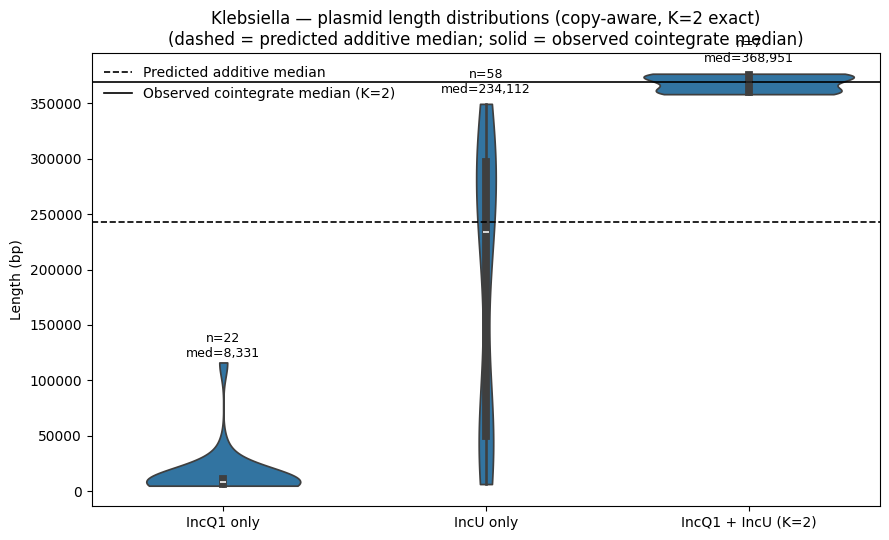

In [102]:
# --- Klebsiella: violín coherente con el análisis copy-aware (K=2 exacto) ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

GENUS = "Klebsiella"
A, B = "IncQ1", "IncU"

# Subconjunto por género
pid_g = XE.loc[XE["genus_clean"] == GENUS, "plasmid_id"]
C = copy_mat.loc[pid_g].copy()
L = XE.set_index("plasmid_id").loc[pid_g, "Length"]

# Máscaras (copy-aware)
total = C.sum(axis=1)
m_single_A = (total == 1) & (C.get(A, 0) == 1)
m_single_B = (total == 1) & (C.get(B, 0) == 1)
m_combo_K2 = (total == 2) & (C.get(A, 0) == 1) & (C.get(B, 0) == 1)

# Data long
df_v = pd.DataFrame({
    "group": (["IncQ1 only"] * m_single_A.sum())
             + (["IncU only"] * m_single_B.sum())
             + (["IncQ1 + IncU (K=2)"] * m_combo_K2.sum()),
    "Length": pd.concat([L[m_single_A], L[m_single_B], L[m_combo_K2]]).values
})

# Estadísticos
med_A = float(np.median(L[m_single_A])) if m_single_A.any() else np.nan
med_B = float(np.median(L[m_single_B])) if m_single_B.any() else np.nan
pred  = med_A + med_B
obs   = float(np.median(L[m_combo_K2])) if m_combo_K2.any() else np.nan
nA, nB, nAB = int(m_single_A.sum()), int(m_single_B.sum()), int(m_combo_K2.sum())

print(f"{GENUS} — tamaños de grupo: IncQ1 only n={nA}, IncU only n={nB}, IncQ1+IncU (K=2) n={nAB}")
print(f"med(IncQ1)= {med_A:,.1f} bp | med(IncU)= {med_B:,.1f} bp")
print(f"Predicho (suma) = {pred:,.1f} bp | Observado (K=2) = {obs:,.1f} bp | Δ = {obs-pred:,.1f} bp")

# Plot
plt.figure(figsize=(9,5.5))
sns.violinplot(data=df_v, x="group", y="Length", inner="box", cut=0)
plt.axhline(pred, ls="--", color="k", lw=1.2, label="Predicted additive median")
plt.axhline(obs,  ls="-",  color="k", lw=1.2, label="Observed cointegrate median (K=2)")

# anota n y mediana por grupo
for i, g in enumerate(["IncQ1 only", "IncU only", "IncQ1 + IncU (K=2)"]):
    vals = df_v.loc[df_v["group"] == g, "Length"]
    if not vals.empty:
        plt.text(i, vals.max()*1.02, f"n={len(vals)}\nmed={np.median(vals):,.0f}",
                 ha="center", va="bottom", fontsize=9)

plt.title(f"{GENUS} — plasmid length distributions (copy-aware, K=2 exact)\n"
          "(dashed = predicted additive median; solid = observed cointegrate median)")
plt.xlabel("")
plt.ylabel("Length (bp)")
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


[Global] n=174, % below=88.5%, median log2 ratio=-0.691, p(Wilcoxon)=2.579602571217978e-26

[Por K]
 K   n prop_below median_log2_ratio mean_log2_ratio p_wilcoxon      FDR
 2 108      84.3%            -0.516          -0.613   6.15e-15 1.85e-14
 3  47      93.6%            -0.816          -0.844   7.82e-13 1.17e-12
 4  19     100.0%            -0.974          -1.095   3.81e-06 3.81e-06

[Por género] tabla → /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/copyaware_trend_by_genus.tsv
         genus  n prop_below median_log2_ratio p_wilcoxon      FDR
    Klebsiella 73      93.2%            -0.840   8.03e-13 4.02e-12
   Escherichia 57      89.5%            -0.741   3.55e-10 8.87e-10
  Enterococcus 15      60.0%            -0.154   1.51e-01 1.51e-01
Staphylococcus 13      76.9%            -0.071   4.79e-02 5.98e-02
  Enterobacter 12     100.0%            -0.920   4.88e-04 8.14e-04
   Pseudomonas  3     100.0%            -0.273        NaN      NaN
 Acinetobacter  1     100.0%            -0.0

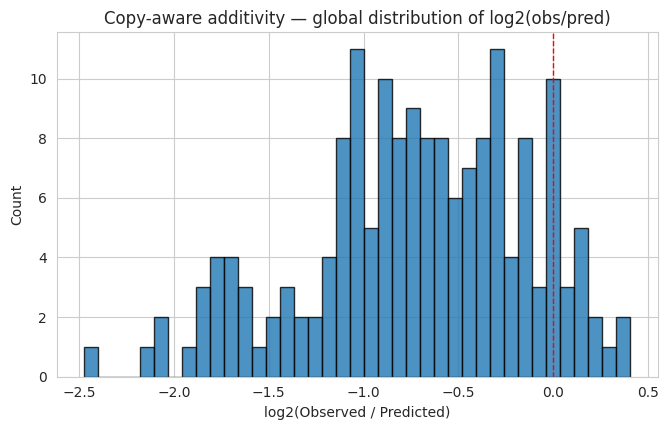

Hist global → /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/copyaware_log2ratio_hist_global.png


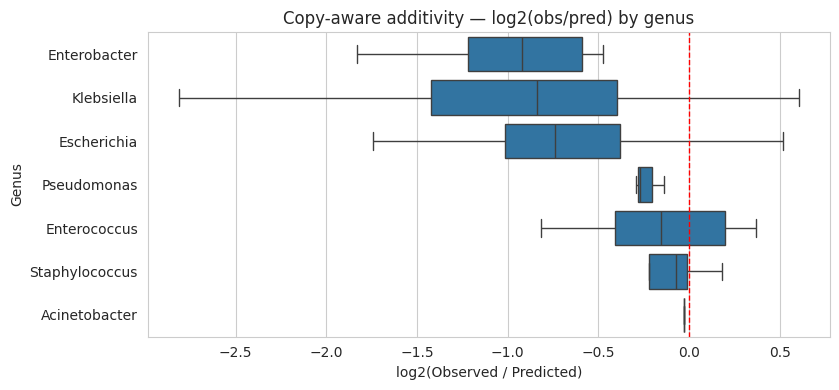

Box por género → /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/copyaware_log2ratio_box_by_genus.png


KeyError: "None of [Index([0], dtype='int64')] are in the [columns]"

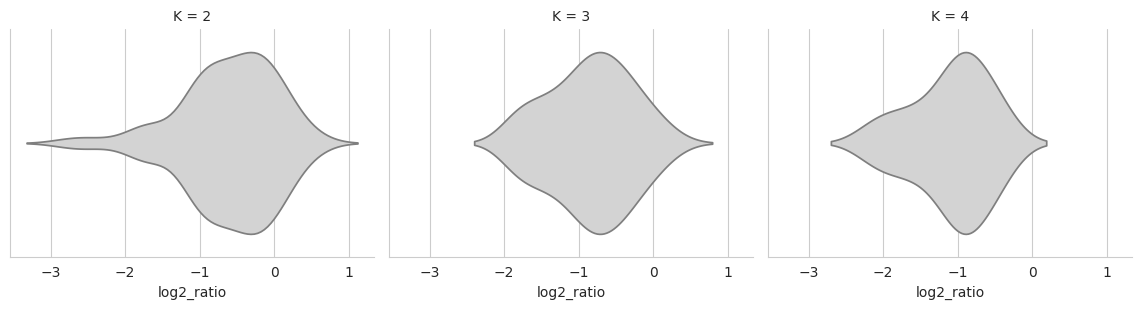

In [106]:
# ============================================
# Tendencia global: ¿obs < pred?  (sub-aditividad)
# Usa additivity_copyaware ya creado
#   - métricas globales, por K y por género
#   - tests de Wilcoxon sobre log2(obs/pred)
#   - histogramas/boxplots de log2-ratio
# ============================================
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

assert 'additivity_copyaware' in globals(), "Falta additivity_copyaware (ejecuta el chunk de copy-aware primero)."

RES   = Path("/home/nacho/HDD16/Nacho/RepliCOOC/results")
FIGS  = RES / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
STATS = RES / "stats";   STATS.mkdir(parents=True, exist_ok=True)

DF = additivity_copyaware.copy()
# Evita infinitos / logs raros
DF = DF[(DF["pred_median"] > 0) & (DF["obs_median"] > 0)].copy()
DF["log2_ratio"] = np.log2(DF["obs_median"] / DF["pred_median"])
DF["below_diag"] = DF["log2_ratio"] < 0

# ---------- Resumen global
summary_global = {
    "n": int(len(DF)),
    "prop_below": float((DF["below_diag"]).mean()),
    "median_log2_ratio": float(DF["log2_ratio"].median()),
    "mean_log2_ratio": float(DF["log2_ratio"].mean())
}

# Wilcoxon signed-rank vs 0 (solo si hay al menos 10)
if len(DF) >= 10:
    try:
        w_stat, w_p = wilcoxon(DF["log2_ratio"], alternative="two-sided", zero_method="wilcox")
    except Exception:
        # fallback si hay demasiados ceros: usar 'pratt'
        w_stat, w_p = wilcoxon(DF["log2_ratio"], alternative="two-sided", zero_method="pratt")
    summary_global["wilcoxon_p"] = float(w_p)
else:
    summary_global["wilcoxon_p"] = np.nan

print("[Global] n={n}, % below={prop_below:.1%}, median log2 ratio={median_log2_ratio:+.3f}, p(Wilcoxon)={wilcoxon_p}".format(**summary_global))

# ---------- Resumen por K
byK = (DF.groupby("K")
         .agg(n=("log2_ratio","size"),
              prop_below=("below_diag","mean"),
              median_log2_ratio=("log2_ratio","median"),
              mean_log2_ratio=("log2_ratio","mean"))
         .reset_index())

# Wilcoxon por K
pvals = []
for k, sub in DF.groupby("K"):
    if len(sub) >= 10:
        try:
            _, p = wilcoxon(sub["log2_ratio"], alternative="two-sided", zero_method="wilcox")
        except Exception:
            _, p = wilcoxon(sub["log2_ratio"], alternative="two-sided", zero_method="pratt")
    else:
        p = np.nan
    pvals.append((k, p))
pk = pd.DataFrame(pvals, columns=["K","p_wilcoxon"])
# BH dentro de los K disponibles
mask = pk["p_wilcoxon"].notna()
pk.loc[mask, "FDR"] = multipletests(pk.loc[mask,"p_wilcoxon"], method="fdr_bh")[1]
byK = byK.merge(pk, on="K", how="left")
print("\n[Por K]")
print(byK.to_string(index=False, formatters={"prop_below":"{:,.1%}".format,
                                            "median_log2_ratio":"{:+.3f}".format,
                                            "mean_log2_ratio":"{:+.3f}".format,
                                            "p_wilcoxon":"{:.2e}".format if byK["p_wilcoxon"].notna().any() else str,
                                            "FDR":"{:.2e}".format if byK["FDR"].notna().any() else str}))

# ---------- Resumen por género (con Wilcoxon y BH dentro de géneros)
GEN_MIN = 10  # mínimo de puntos por género para test
stats_genus = []
for g, sub in DF.groupby("genus"):
    n = len(sub)
    prop_below = float((sub["log2_ratio"]<0).mean())
    med_lr = float(sub["log2_ratio"].median())
    if n >= GEN_MIN:
        try:
            _, p = wilcoxon(sub["log2_ratio"], alternative="two-sided", zero_method="wilcox")
        except Exception:
            _, p = wilcoxon(sub["log2_ratio"], alternative="two-sided", zero_method="pratt")
    else:
        p = np.nan
    stats_genus.append((g, n, prop_below, med_lr, p))

gen = pd.DataFrame(stats_genus, columns=["genus","n","prop_below","median_log2_ratio","p_wilcoxon"]).sort_values("n", ascending=False)
mask = gen["p_wilcoxon"].notna()
if mask.any():
    gen.loc[mask, "FDR"] = multipletests(gen.loc[mask,"p_wilcoxon"], method="fdr_bh")[1]
else:
    gen["FDR"] = np.nan

gen_out = STATS / "copyaware_trend_by_genus.tsv"
gen.to_csv(gen_out, sep="\t", index=False)
print(f"\n[Por género] tabla → {gen_out}")
print(gen.head(12).to_string(index=False, formatters={"prop_below":"{:,.1%}".format,
                                                      "median_log2_ratio":"{:+.3f}".format,
                                                      "p_wilcoxon":"{:.2e}".format if gen['p_wilcoxon'].notna().any() else str,
                                                      "FDR":"{:.2e}".format if gen['FDR'].notna().any() else str}))

# ---------- Plots
# 1) Histograma global de log2(obs/pred)
plt.figure(figsize=(6.8,4.4))
bins = np.linspace(DF["log2_ratio"].quantile(0.01), DF["log2_ratio"].quantile(0.99), 40)
plt.hist(DF["log2_ratio"], bins=bins, edgecolor="black", alpha=0.8)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("log2(Observed / Predicted)")
plt.ylabel("Count")
plt.title("Copy-aware additivity — global distribution of log2(obs/pred)")
plt.tight_layout()
out_png = FIGS / "copyaware_log2ratio_hist_global.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight"); plt.show()
print("Hist global →", out_png)

# 2) Boxplot por género (ordena por mediana log2-ratio)
top_gen = gen.sort_values("median_log2_ratio").copy()
order = top_gen["genus"].tolist()
plt.figure(figsize=(8.5, max(4, 0.35*len(order))))
sns.boxplot(data=DF, x="log2_ratio", y="genus", order=order, showfliers=False)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("log2(Observed / Predicted)")
plt.ylabel("Genus")
plt.title("Copy-aware additivity — log2(obs/pred) by genus")
plt.tight_layout()
out_png2 = FIGS / "copyaware_log2ratio_box_by_genus.png"
plt.savefig(out_png2, dpi=300, bbox_inches="tight"); plt.show()
print("Box por género →", out_png2)

# 3) Facet por K (violin + mediana)
g = sns.FacetGrid(DF, col="K", sharex=True, sharey=True, height=3.2, aspect=1.2)
g.map_dataframe(sns.violinplot, x="log2_ratio", color="lightgray", inner=None)
g.map(plt.axvline, 0, color="red", linestyle="--", linewidth=1)
g.set_axis_labels("log2(Observed / Predicted)", "")
g.set_titles("K = {col_name}")
for ax in g.axes.flat:
    ax.grid(axis="y", linestyle=":", alpha=0.3)
plt.tight_layout()
out_png3 = FIGS / "copyaware_log2ratio_violin_byK.png"
plt.savefig(out_png3, dpi=300, bbox_inches="tight"); plt.show()
print("Facet por K →", out_png3)


[OK] Resumen por combo → /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/cointegrate_same_combo_across_genera_summary.tsv (n=32)
[OK] Comparaciones par-a-par → /home/nacho/HDD16/Nacho/RepliCOOC/results/stats/cointegrate_same_combo_across_genera_pairwise.tsv (n=87)


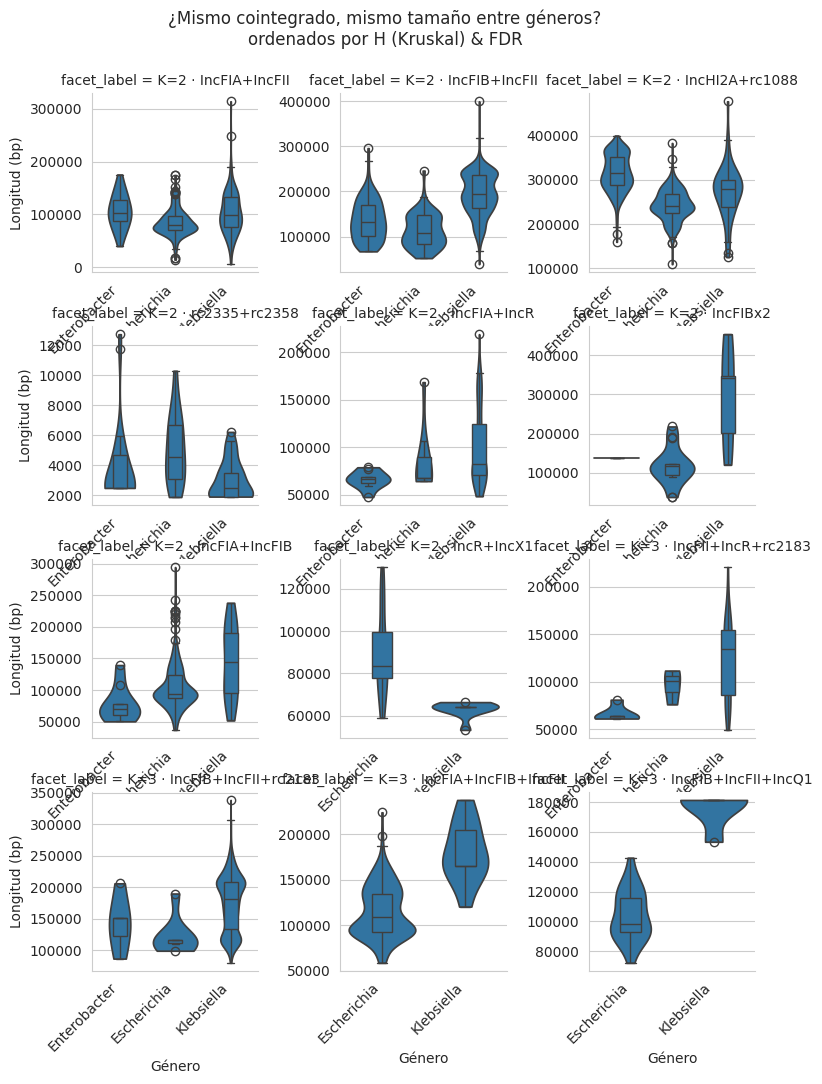

[OK] Figura facets → /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/same_combo_across_genera_facets.png


In [108]:
# ============================================================
# ¿Mismo cointegrado, mismo tamaño entre géneros? (robusto)
# - Reutiliza XE, copy_mat, combo_label (si existe), K_LIST, MIN_N_PER_GENUS, MIN_GENUS
# - Evita NameError de 'combestat' y hace early-exit si no hay datos
# ============================================================
import numpy as np, pandas as pd, itertools
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path

# ---------- config (usa tus defaults si ya existen) ----------
try:
    K_LIST
except NameError:
    K_LIST = [2,3,4]
try:
    MIN_N_PER_GENUS
except NameError:
    MIN_N_PER_GENUS = 5
try:
    MIN_GENUS
except NameError:
    MIN_GENUS = 2
TOPN_PLOTS = 12
ORDER_BY   = "H"   # "H" o "range_median"
LOGY       = False

BASE  = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
RES   = BASE / "results"
FIGS  = RES / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
STATS = RES / "stats";   STATS.mkdir(parents=True, exist_ok=True)

def _combo_label_default(combo):
    parts = []
    for rep, m in combo:
        rep2 = rep.replace("rep_cluster_","rc")
        parts.append(f"{rep2}x{m}" if m != 1 else rep2)
    return "+".join(parts)

# usa tu combo_label si existe en el entorno
try:
    combo_label  # noqa: F401
except NameError:
    combo_label = _combo_label_default

def _extract_lengths_exact_K_by_genus(XE, copy_mat, K):
    rows = []
    for g, subX in XE.groupby("genus_clean"):
        pids_g = subX["plasmid_id"].unique()
        subC = copy_mat.reindex(pids_g).fillna(0).astype(int)
        if subC.empty:
            continue
        total_copies_g = subC.sum(axis=1)
        pidK = total_copies_g[total_copies_g == K].index
        if len(pidK) == 0:
            continue
        for pid, row in subC.loc[pidK].iterrows():
            nonzero = row[row > 0]
            combo = tuple((rep, int(nonzero[rep])) for rep in sorted(nonzero.index))
            L = float(subX.loc[subX["plasmid_id"] == pid, "Length"].iloc[0])
            rows.append((K, g, combo, combo_label(combo), L))
    return pd.DataFrame(rows, columns=["K","genus","combo","combo_label","Length"])

# ---------- 1) Extraer longitudes por combo y género ----------
all_len = []
for K in K_LIST:
    tmp = _extract_lengths_exact_K_by_genus(XE, copy_mat, K)
    if not tmp.empty:
        all_len.append(tmp)
lengths_by_combo = (pd.concat(all_len, ignore_index=True)
                    if all_len else
                    pd.DataFrame(columns=["K","genus","combo","combo_label","Length"]))

if lengths_by_combo.empty:
    print("No hay datos de longitudes por (K, combo, género). Nada que testear/plotear.")
else:
    # ---------- 2) Filtrar combos con soporte por género ----------
    grp = (lengths_by_combo
           .groupby(["K","combo","combo_label","genus"])["Length"]
           .agg(n="count", median="median")
           .reset_index())
    ok = (grp[grp["n"] >= MIN_N_PER_GENUS]
          .groupby(["K","combo","combo_label"])["genus"]
          .nunique()
          .reset_index(name="n_genus"))
    ok = ok[ok["n_genus"] >= MIN_GENUS]

    keep_keys = set(zip(ok["K"], ok["combo"]))
    long_ok = lengths_by_combo[lengths_by_combo.apply(lambda r: (r["K"], r["combo"]) in keep_keys, axis=1)].copy()

    # ---------- 3) Estadística por combo ----------
    records = []
    pairwise_rows = []
    for (K, combo), sub in long_ok.groupby(["K","combo"]):
        label = sub["combo_label"].iloc[0]
        # listas por género
        g_groups, gens = [], []
        for g, subg in sub.groupby("genus"):
            g_groups.append(subg["Length"].values)
            gens.append(g)
        if len(g_groups) < 2:
            continue

        # Kruskal
        try:
            H, p_kw = kruskal(*g_groups, nan_policy="omit")
        except Exception:
            H, p_kw = np.nan, np.nan

        # rango de medianas
        desc = (sub.groupby("genus")["Length"]
                  .agg(n="count", median_bp="median", mean_bp="mean", sd_bp="std")
                  .reset_index())
        range_median = float(desc["median_bp"].max() - desc["median_bp"].min())

        # pairwise MWU + BH dentro del combo
        pairs, pvals = [], []
        for g1, g2 in itertools.combinations(gens, 2):
            x = sub.loc[sub["genus"]==g1, "Length"].values
            y = sub.loc[sub["genus"]==g2, "Length"].values
            if len(x) == 0 or len(y) == 0:
                p = np.nan
            else:
                try:
                    _, p = mannwhitneyu(x, y, alternative="two-sided")
                except Exception:
                    p = np.nan
            pairs.append((g1, g2)); pvals.append(p)
        if len(pvals) > 0:
            padj = multipletests([pv if np.isfinite(pv) else 1.0 for pv in pvals],
                                 method="fdr_bh")[1]
            for (g1,g2), pv, pa in zip(pairs, pvals, padj):
                pairwise_rows.append((K, combo, label, g1, g2, pv, pa,
                                      int((sub["genus"]==g1).sum()),
                                      int((sub["genus"]==g2).sum())))
        records.append((K, combo, label, H, p_kw, range_median, len(gens)))

    # Siempre definimos combestat, aunque esté vacío
    combestat = pd.DataFrame(records,
                             columns=["K","combo","combo_label","H","p_kw","range_median","n_genus"])

    if combestat.empty:
        print("No hubo combos con suficientes géneros para testear. Nada que plotear.")
    else:
        combestat["FDR_kw"] = multipletests(
            combestat["p_kw"].fillna(1.0).values, method="fdr_bh"
        )[1]
        out_sum = STATS / "cointegrate_same_combo_across_genera_summary.tsv"
        combestat.sort_values(["FDR_kw","H"], ascending=[True, False]).to_csv(out_sum, sep="\t", index=False)
        print(f"[OK] Resumen por combo → {out_sum} (n={len(combestat)})")

        pw = pd.DataFrame(pairwise_rows,
                          columns=["K","combo","combo_label","genus1","genus2","p_mwu","FDR_mwu","n1","n2"])
        out_pw = STATS / "cointegrate_same_combo_across_genera_pairwise.tsv"
        pw.sort_values(["combo_label","FDR_mwu"]).to_csv(out_pw, sep="\t", index=False)
        print(f"[OK] Comparaciones par-a-par → {out_pw} (n={len(pw)})")

        # ---------- 4) Plots (facets) para top combos ----------
        if ORDER_BY == "H":
            ordered = combestat.sort_values(["FDR_kw","H"], ascending=[True, False])
            title_extra = "ordenados por H (Kruskal) & FDR"
        else:
            ordered = combestat.sort_values(["range_median","H"], ascending=[False, False])
            title_extra = "ordenados por rango de medianas"

        top_keys = (ordered.head(TOPN_PLOTS)[["K","combo"]]
                            .apply(tuple, axis=1).tolist())
        if len(top_keys) == 0:
            print("No hay combos para facetear tras el filtrado.")
        else:
            plot_df = lengths_by_combo[lengths_by_combo.apply(
                lambda r: (r["K"], r["combo"]) in set(top_keys), axis=1)].copy()
            plot_df["facet_label"] = plot_df.apply(lambda r: f"K={r['K']} · {r['combo_label']}", axis=1)

            n_facets = len(top_keys)
            ncols = 3
            g = sns.FacetGrid(plot_df, col="facet_label", col_wrap=ncols,
                              sharex=False, sharey=False, height=2.6)
            g.map_dataframe(sns.violinplot, x="genus", y="Length", inner=None, cut=0)
            g.map_dataframe(sns.boxplot, x="genus", y="Length", width=0.25,
                            showcaps=True, boxprops={'zorder': 2})
            g.set_xticklabels(rotation=45, ha="right")
            g.set_axis_labels("Género", "Longitud (bp)")
            g.fig.subplots_adjust(top=0.90)
            g.fig.suptitle(f"¿Mismo cointegrado, mismo tamaño entre géneros?\n{title_extra}")

            if LOGY:
                for ax in g.axes.flat:
                    if ax is not None:
                        ax.set_yscale("log")

            out_png = FIGS / "same_combo_across_genera_facets.png"
            plt.savefig(out_png, dpi=300, bbox_inches="tight")
            plt.show()
            print(f"[OK] Figura facets → {out_png}")


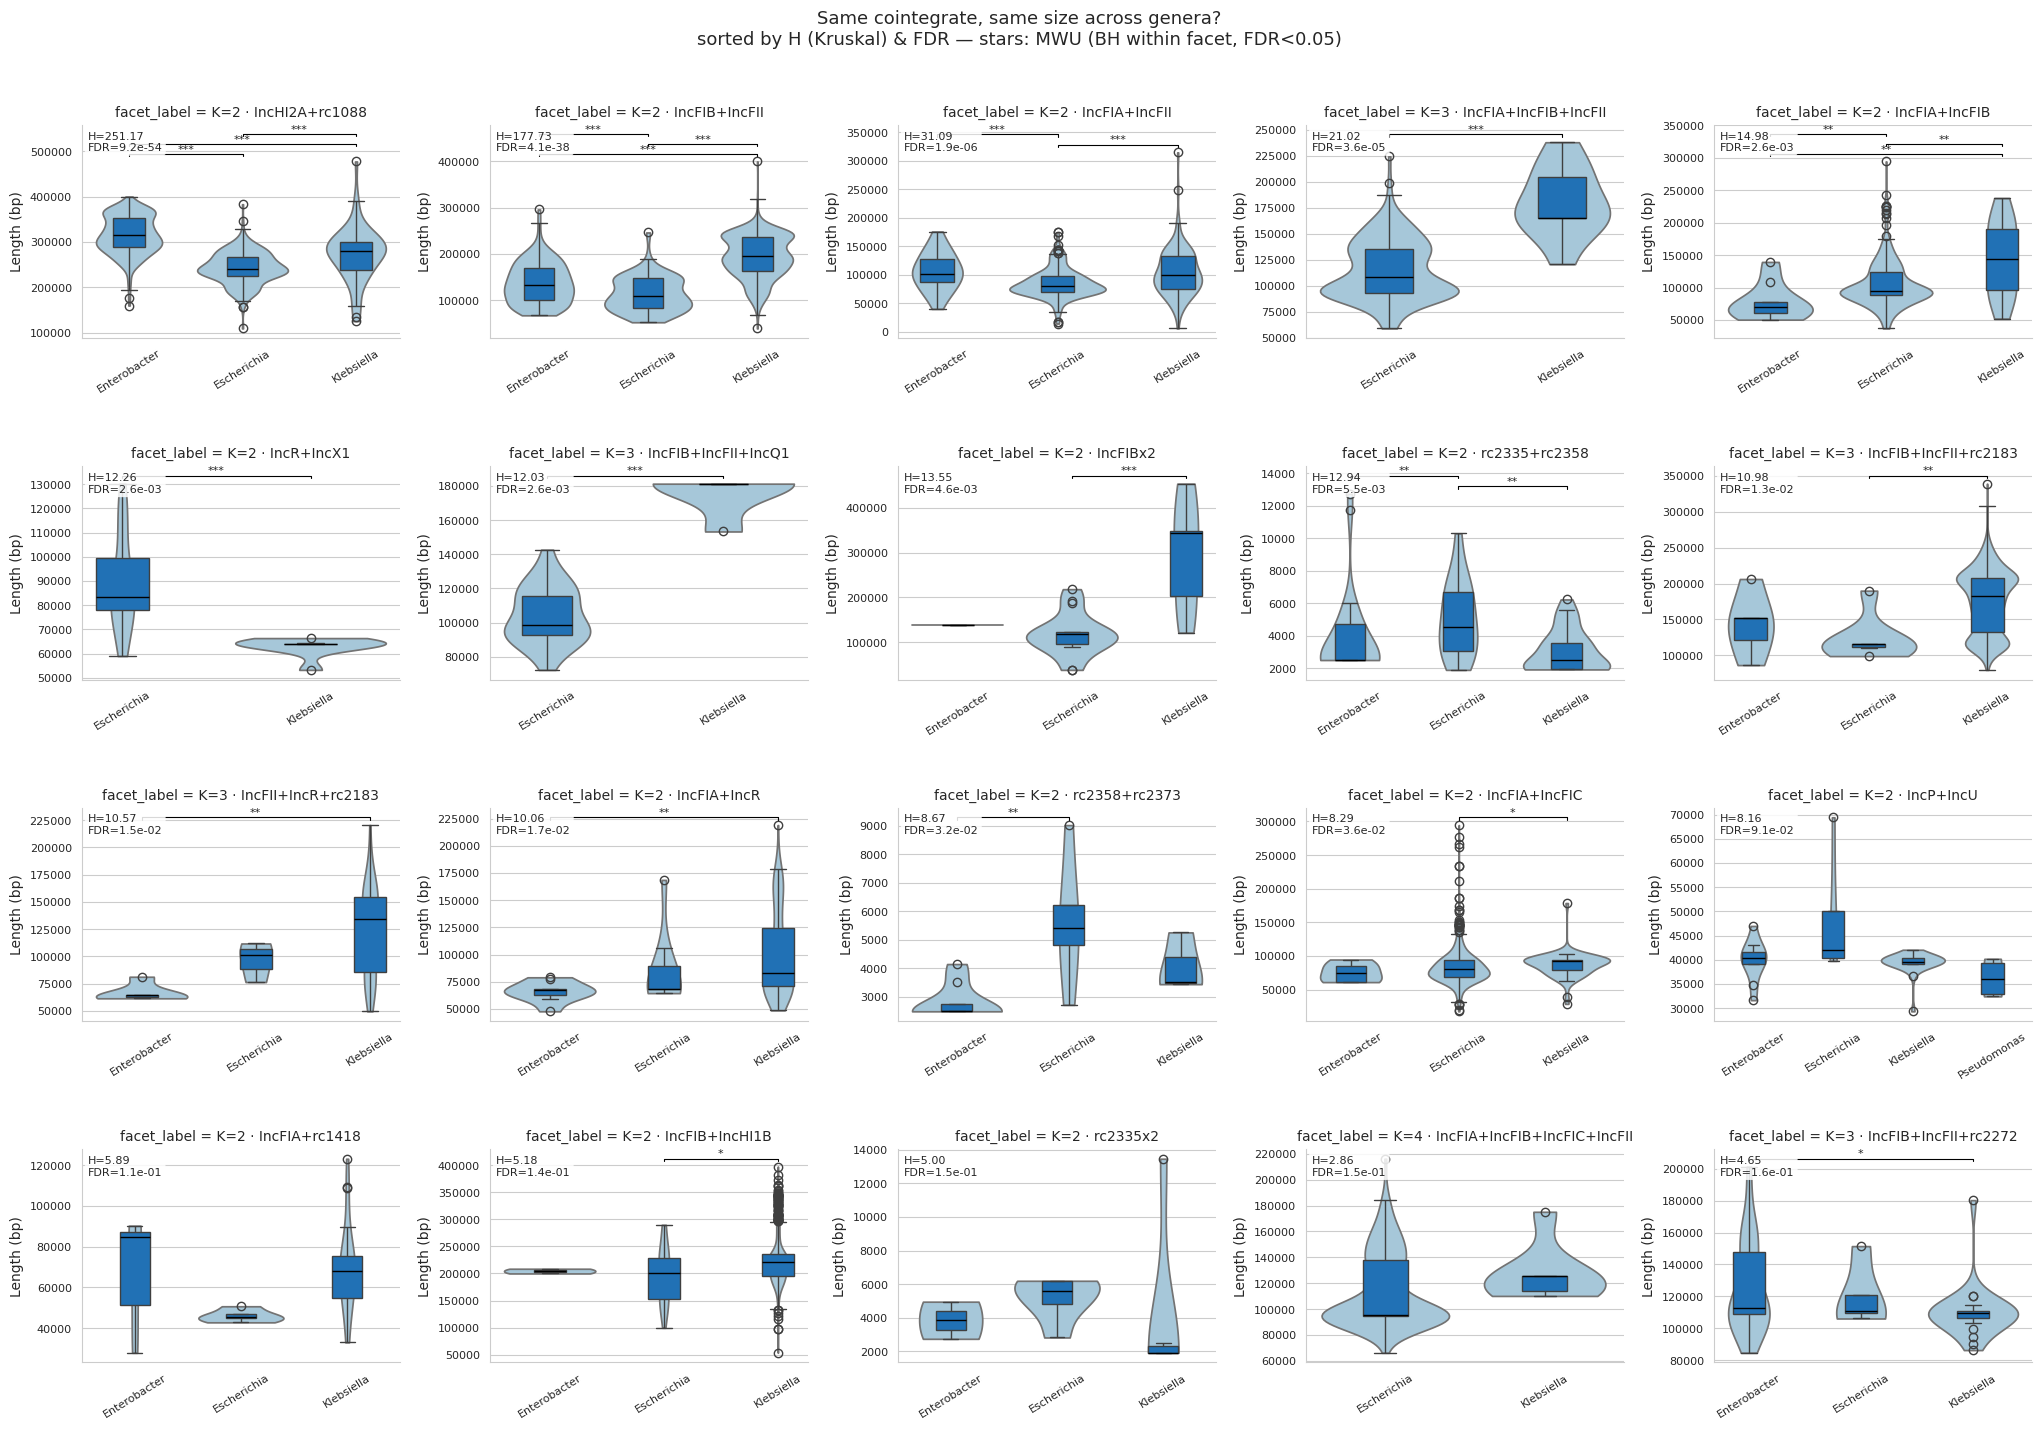

[OK] Updated figure → /home/nacho/HDD16/Nacho/RepliCOOC/results/figures/same_combo_across_genera_facets_with_pairwise_stars_FIXED.png


In [113]:
# ============================================================
# Facets "same cointegrate across genera" with 2×2 MWU+BH stars
# Robust to label/key mismatches: keys are (K, combo) tuples.
# ============================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ---------- params ----------
ORDER_BY   = "H"     # or "range"
TOPN_PLOTS = 20
MIN_N_GRP  = 5
ALPHA_FDR  = 0.05
N_ANNOT    = 10
BR_STEP    = 0.06
TXT_FS     = 8

# ---------- 1) Build a stable key -> stats map ----------
# combestat must have columns: K, combo, H, FDR_kw (as created earlier)
_stats_map = {(int(r.K), tuple(r.combo)): (float(r.H), float(r.FDR_kw))
              for r in combestat.itertuples(index=False)}

def _facet_key(row):
    return (int(row["K"]), tuple(row["combo"]))

def _nice_label_from_key(key):
    K, combo = key
    parts = []
    for rep, m in combo:
        rep2 = str(rep).replace("rep_cluster_", "rc")
        parts.append(f"{rep2}x{m}" if int(m) != 1 else rep2)
    return f"K={K} · {'+'.join(parts)}"

# ---------- 2) Choose top keys deterministically ----------
if ORDER_BY == "H":
    ordered = combestat.sort_values(["FDR_kw", "H"], ascending=[True, False])
    title_extra = "sorted by H (Kruskal) & FDR"
else:
    ordered = combestat.sort_values(["range_median", "H"], ascending=[False, False])
    title_extra = "sorted by median range"

top_keys = [(int(r.K), tuple(r.combo)) for r in ordered.head(TOPN_PLOTS).itertuples(index=False)]

# ---------- 3) Filter lengths table by key (never by string label) ----------
plot_df = lengths_by_combo[lengths_by_combo.apply(lambda r: _facet_key(r) in set(top_keys), axis=1)].copy()
plot_df["facet_key"]   = plot_df.apply(_facet_key, axis=1)
plot_df["facet_label"] = plot_df["facet_key"].map(_nice_label_from_key)
plot_df["genus"]       = plot_df["genus"].astype(str)

# Keep facet ordering as in top_keys:
facet_order = [_nice_label_from_key(k) for k in top_keys]

# ---------- helpers ----------
def _asterisks(p):
    return '***' if p < 1e-3 else ('**' if p < 1e-2 else ('*' if p < 5e-2 else 'ns'))

def draw_bracket(ax, xi, xj, y, h, text):
    ax.plot([xi, xi, xj, xj], [y, y+h, y+h, y], lw=0.8, c='k', clip_on=False)
    ax.text((xi+xj)/2, y+h, text, ha='center', va='bottom', fontsize=TXT_FS)

# ---------- 4) Plot grid ----------
ncols = 5
g = sns.FacetGrid(
    plot_df, col="facet_label", col_wrap=ncols,
    col_order=facet_order, sharex=False, sharey=False,
    height=3.6, aspect=1.15
)
g.map_dataframe(sns.violinplot, x="genus", y="Length", inner=None, cut=0, color="#9ecae1")
g.map_dataframe(
    sns.boxplot, x="genus", y="Length", width=0.28,
    showcaps=True, boxprops={'zorder': 2, 'facecolor': '#2171b5'},
    medianprops={'color': 'black', 'lw': 1}
)

# ---------- 5) Add pairwise tests per facet (robust lookup by key) ----------
for ax, label in zip(g.axes.flat, facet_order):
    if ax is None: 
        continue
    sub = plot_df[plot_df["facet_label"] == label]
    cats = [t.get_text() for t in ax.get_xticklabels()]

    # pairwise MWU within facet
    pairs, pvals, effects = [], [], []
    med_by_genus = sub.groupby("genus")["Length"].median()
    for g1, g2 in combinations(cats, 2):
        x = sub.loc[sub["genus"] == g1, "Length"].dropna()
        y = sub.loc[sub["genus"] == g2, "Length"].dropna()
        if len(x) < MIN_N_GRP or len(y) < MIN_N_GRP:
            continue
        p = mannwhitneyu(x, y, alternative="two-sided").pvalue
        pairs.append((g1, g2)); pvals.append(p)
        effects.append(abs(med_by_genus.get(g1, np.nan) - med_by_genus.get(g2, np.nan)))

    if pvals:
        FDR = multipletests(pvals, method="fdr_bh")[1]
        tbl = (pd.DataFrame({"pair": pairs, "p": pvals, "FDR": FDR, "eff": effects})
                 .sort_values(["FDR", "eff"], ascending=[True, False]))
        sig_tbl = tbl[tbl["FDR"] < ALPHA_FDR].head(N_ANNOT)

        y_max = sub["Length"].max(); y_min = sub["Length"].min()
        yrange = max(1.0, y_max - y_min)
        base = y_max + 0.03 * yrange
        step = BR_STEP * yrange
        for k, row in enumerate(sig_tbl.itertuples(index=False)):
            xi = cats.index(row.pair[0]); xj = cats.index(row.pair[1])
            draw_bracket(ax, xi, xj, base + k * step, h=0.012 * yrange, text=_asterisks(row.FDR))

    # prepend facet-level stats (reliable via key)
    key = sub["facet_key"].iloc[0]
    H, FDR_kw = _stats_map.get(key, (np.nan, np.nan))
    ax.text(0.02, 0.97, f"H={H:.2f}\nFDR={FDR_kw:.1e}",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=8, bbox=dict(boxstyle="round,pad=0.25",
            facecolor="white", alpha=0.85, lw=0.3))

    ax.set_xlabel(""); ax.set_ylabel("Length (bp)")
    ax.tick_params(axis='x', labelrotation=32, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# ---------- layout / save ----------
g.fig.subplots_adjust(top=0.90, hspace=0.60, wspace=0.28)
g.fig.suptitle("Same cointegrate, same size across genera?\n"
               f"{title_extra} — stars: MWU (BH within facet, FDR<0.05)",
               fontsize=13)

out_png = FIGS / "same_combo_across_genera_facets_with_pairwise_stars_FIXED.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print(f"[OK] Updated figure → {out_png}")
